# Task 3 — Gender and Usage Classification

This notebook follows both targets from data checks to final choices: SAM25 for Gender and E1 for Usage. Each step explains the idea, the result, what failed and what we learned.

**How to read it.** The first data checks informed the baseline. E1–E10 tested changes to it. A second data review led to later trials. The last sections freeze the saved models and examine their limits. Usage has a separate path because its labels and data limits differ.

**Execution.** Run All reads saved audits, run records and predictions. It rebuilds the tables and figures without training or running new holdout/test inference. Gender uses its saved holdout report. Usage also includes the already completed official-image test comparison, scored with recovered reference labels. Both final choices were accepted after evaluation.

## 1. Runtime setup

Use the local kernel. Verify the frozen evidence before any analysis.

### 1.1 Find the project and select its environment

In [1]:
import os
import sys
from pathlib import Path

candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
REPO_DIR = next(path for path in candidates if (path/'src/fashion').is_dir())
assert Path(sys.prefix).resolve() == (REPO_DIR/'.venv').resolve(), 'Select the project .venv kernel'
os.chdir(REPO_DIR)
os.environ["FASHION_PROJECT_ROOT"] = str(REPO_DIR)
sys.path.insert(0, str(REPO_DIR / "src"))
TASK3_EVIDENCE_ROOT = REPO_DIR/'results/evidence/task3'
PACK = REPO_DIR/'reports/task3/main_report_20260906'
USAGE_FINAL = REPO_DIR/'reports/task3/usage_final_e1_20260907'
FIGURES = REPO_DIR/'results/figures/task3/main_analysis'
FIGURES.mkdir(parents=True, exist_ok=True)
print('Repository:', REPO_DIR)
print('Python:', sys.executable)

Repository: /home/dinhquan/.codex/worktrees/127f/MLA2-eda
Python: /home/dinhquan/.codex/worktrees/127f/MLA2-eda/.venv/bin/python


### 1.2 Load libraries and verify saved files

In [2]:
import hashlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image, ImageEnhance, ImageOps

pd.set_option('display.max_colwidth', 80)
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
evidence_lock = json.loads((PACK/'evidence_lock.json').read_text())
analysis_assets = json.loads((PACK/'analysis_assets.json').read_text())
for relative, expected in {**evidence_lock['files'], **analysis_assets}.items():
    saved = REPO_DIR / relative.replace('reports/task3_', 'reports/task3/', 1)
    assert hashlib.sha256(saved.read_bytes()).hexdigest() == expected, relative
registry = pd.read_csv(PACK/'results/runs.csv', keep_default_na=False).set_index('run_id',
    drop=False)
classical_registry = pd.read_csv(PACK/'results/classical_runs.csv',
    keep_default_na=False).set_index('run_id', drop=False)
registry = pd.concat([registry, classical_registry.loc[~classical_registry.index.isin(
    registry.index)]])
assert not registry.index.duplicated().any()
print(f'Checked {len(analysis_assets)} analysis sources and {len(registry)} saved run records.')

Checked 136 analysis sources and 156 saved run records.


## 2. Data and comparison rules

Use the one saved split. Never let a later model choose easier folds.

### 2.1 Read the canonical data contract

In [3]:
splits = pd.read_csv(REPO_DIR / 'data/processed/splits.csv', keep_default_na=False)
development = splits.loc[splits.partition.eq('development')].copy()
development['cv_fold'] = development.cv_fold.astype(int)
gender_development = development.loc[development.has_gender_label.eq(True)].copy()
usage_development = development.loc[development.has_usage_label.eq(True)].copy()
label_maps = json.loads((REPO_DIR/'data/processed/label_maps.json').read_text())
assert len(development) == 32773 and development.cv_fold.nunique() == 5
assert development.groupby('product_family_group').cv_fold.nunique().max() == 1
display(splits.groupby('partition').size().rename('Images').to_frame())
print('Valid gender rows:', len(gender_development), '| valid usage rows:', len(usage_development))

,Images
partition,
development,32773
holdout,5778
quarantine,61


Valid gender rows: 32773 | valid usage rows: 32772


### 2.2 Metrics and limits

Primary development metric for `gender`: pooled five-fold OOF macro-F1.
Primary development metric for `usage`: pooled five-fold OOF macro-F1.
OOF means each image is predicted by the model that did not train on its fold.
Macro-F1 gives each class equal weight. Accuracy counts all correct images equally.

Use `data/processed/splits.csv`, keep families together, and apply the target label-mask.
Two-fold screens use folds 0 and 4; they are development evidence, not fresh tests.
Tables pool confusion counts from registered runs; they do not average five F1 values.
The later audited IEEE tables are labelled separately because numeric precision can change a few predictions.
No plot joins scores across different label bases or fold sets.

Macro-F1 guided the development trials. The final Usage decision explicitly gives priority to overall accuracy, with the lost rare-class performance shown beside it. This later choice does not turn earlier failed macro-F1 gates into passes.

The dated `results/runs.csv` copy is the source for candidate comparison tables. Confusion counts are added before macro-F1 is computed; averaging fold scores gives a different number. Folds 0 and 4 are screens, not a full confirmation. Original and name-corrected labels stay visibly separate. Later matched IEEE audits check numeric precision and clean training gaps; they do not silently replace registry scores.

The label-mask excludes the one blank Usage target without dropping it from Gender. Literal `NA` remains a real Usage class. Separate models also avoid assuming that shared training helps both targets; negative transfer means a joint model helps one target while hurting the other. Saved holdout and test results are used only as completed evaluation evidence here. Final acceptance followed their review; it is not a newly blind selection.

## 3. Shared EDA: inventory, decode, missing values and quarantine

First establish what each row and image means. These are the same saved preparation steps used by Notebook 01.

### 3.1 Audit row identity, target masks and image geometry

In [4]:
issues = pd.read_csv(REPO_DIR / 'data/processed/audit/issues.csv', keep_default_na=False)
image_audit = pd.read_csv(REPO_DIR / 'data/processed/audit/image_audit.csv.gz',
    keep_default_na=False)
image_audit = image_audit.loc[image_audit.path.isin(development.path)].copy()
assert development.id.is_unique and development.path.is_unique
assert image_audit.decode_ok.eq(True).all()
display(issues.groupby(['field','issue_code','action']).size().rename('Rows').to_frame())
display(development.groupby(['width','height','mode']).size().rename('Images').to_frame())
print('True blank Usage:', development.usage.eq('').sum())
print('Literal NA Usage:', development.usage.eq('NA').sum())
print('Quarantined rows:', splits.partition.eq('quarantine').sum())

,,,Rows
field,issue_code,action,
file,non_image_file,ignored,1
image,missing_image,excluded_from_manifest,5
season,missing_target_label,masked,20
usage,missing_target_label,masked,1


Images
width height mode        
53.0  80.0   RGB        5
60.0  60.0   RGB        4
      75.0   RGB        1
      77.0   RGB        2
      80.0   L        294
             RGB    32467

True blank Usage: 1
Literal NA Usage: 61
Quarantined rows: 61


**What this check changes.** IDs join labels to files; row order is never used as identity. File hashes catch byte duplicates, and decoding catches unreadable images before a model sees them. The CSV and missing-value audit keep absent targets masked instead of inventing labels. Product-name repair is retained as provenance, not used as an image feature. The 61 quarantined rows stay outside the development and holdout model populations.

The shared preparation sequence was: source inventory → CSV and ID checks → image hashing and decoding → missing-target masks → exact duplicates → reviewed near duplicates → name families and conflicting labels → quarantine → one saved group split → class and fold support → target and acquisition shortcuts → quality checks → contact sheets and error examples → transform review → cache/registry checks. The sections below expose the Task 3 consequences of every step. They reuse the saved data contract rather than build a new split.

### 3.2 Recheck every development image hash and decode in this notebook

In [5]:
decoded_rows=[]
for row in development.itertuples():
    path=REPO_DIR/row.path
    assert hashlib.sha256(path.read_bytes()).hexdigest()==row.sha256, row.id
    with Image.open(path) as image:
        image.load()
        decoded_rows.append([row.id,image.width,image.height,image.mode,image.format])
decoded=pd.DataFrame(decoded_rows,columns=['id','width','height','mode','format'])
assert len(decoded)==len(development)
display(decoded.groupby(['width','height','mode','format']).size().rename(
    'Decoded images').to_frame())
print('All development image hashes and decoded pixels verified.')

Decoded images
width height mode format                
53    80     RGB  JPEG                 5
60    60     RGB  JPEG                 4
      75     RGB  JPEG                 1
      77     RGB  JPEG                 2
      80     L    JPEG               294
             RGB  JPEG             32467

All development image hashes and decoded pixels verified.


## 4. Shared EDA: image quality and what the pixels show

Check size, colour mode, brightness, foreground area and examples before choosing the input recipe.

### 4.1 Plot the development image distributions

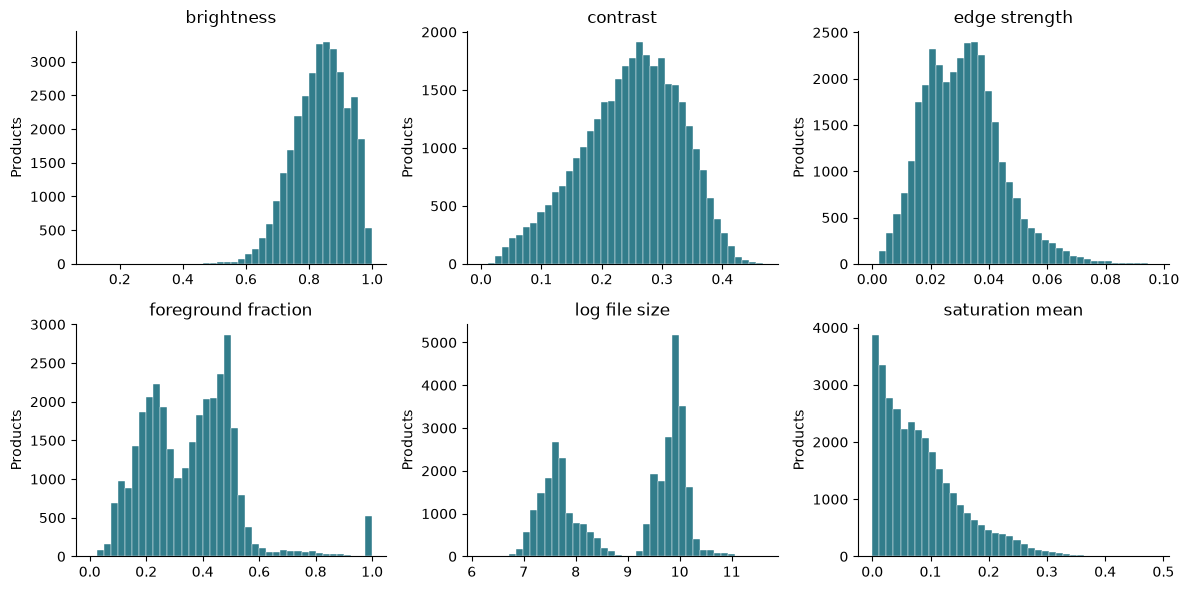

In [6]:
diagnostics = pd.read_csv(
    REPO_DIR / 'results/evidence/task3/clean_slate_eda/teacher_image_diagnostics.csv.gz',
        keep_default_na=False)
assert set(diagnostics.id) == set(development.id)
quality_features = ['brightness','contrast','edge_strength','foreground_fraction',
    'log_file_size','saturation_mean']
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, feature in zip(axes.flat, quality_features):
    ax.hist(diagnostics[feature], bins=40, color='#327d8b', edgecolor='white', linewidth=0.3)
    ax.set(title=feature.replace('_',' '), ylabel='Products')
fig.tight_layout()
fig.savefig(FIGURES / "eda_image_quality.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.2 View a deterministic contact sheet across Gender and Usage

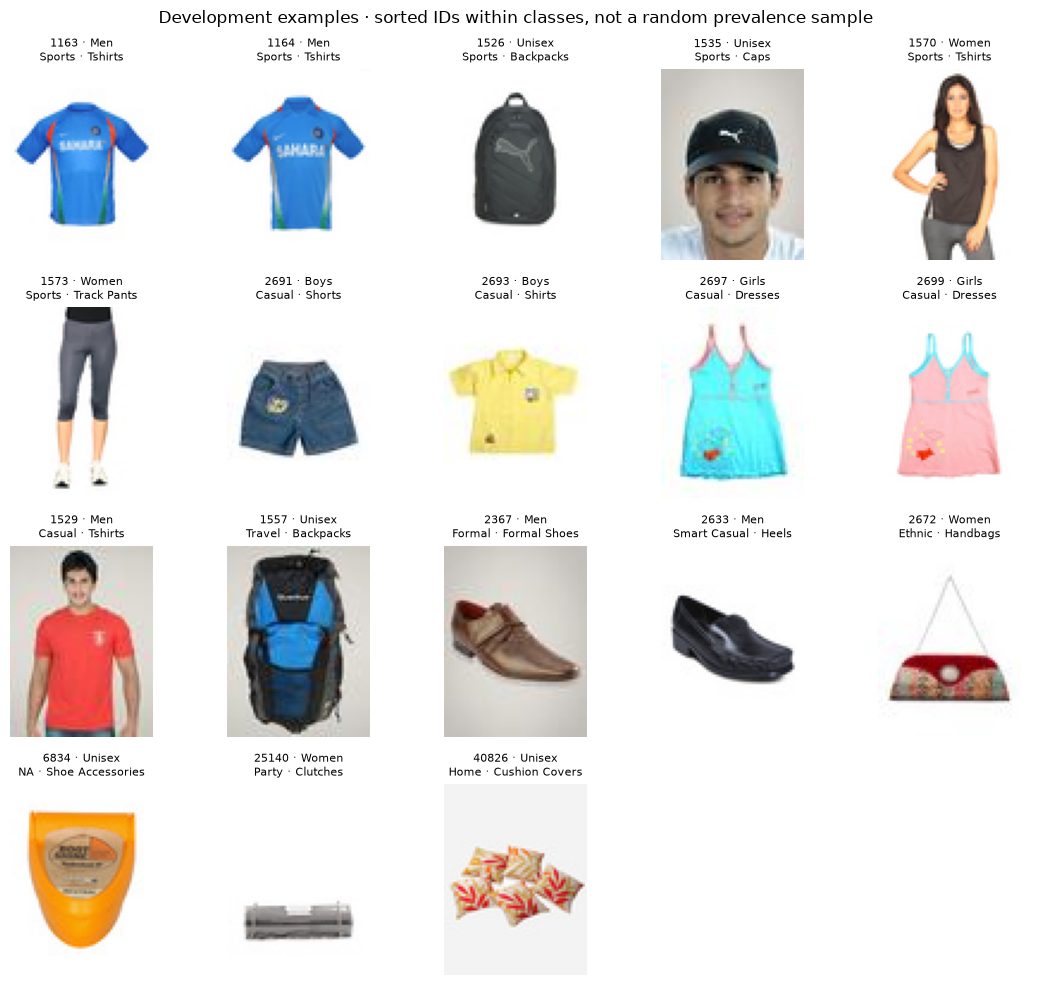

In [7]:
sample_rows = pd.concat([development.sort_values('id').groupby('gender').head(2),
                        usage_development.sort_values('id').groupby('usage').head(1)])
sample_rows = sample_rows.drop_duplicates('id').head(20)
fig, axes = plt.subplots(4, 5, figsize=(11, 10))
for ax in axes.flat:
    ax.axis('off')
for ax, row in zip(axes.flat, sample_rows.itertuples()):
    assert hashlib.sha256((REPO_DIR/row.path).read_bytes()).hexdigest() == row.sha256
    with Image.open(REPO_DIR/row.path) as image:
        ax.imshow(image.convert('RGB'))
    ax.set_title(f'{row.id} · {row.gender}\n{row.usage or "blank"} · {row.articleType}', fontsize=8)
fig.suptitle('Development examples · sorted IDs within classes, not a random prevalence sample')
fig.tight_layout()
fig.savefig(FIGURES/'eda_contact_sheet.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation.** Most images have one centred item on white, but product scale, position, shadows and object type vary. There are 294 valid grayscale images and only 12 unusual geometries. The low native resolution leaves small cues such as straps, collars and shoe outlines fragile.

**Consequence.** Convert all inputs to RGB and keep the native 80×60 information. Fit normalisation only on the current training complement. Brightness and file size describe how images were acquired as well as the item itself; their predictive power would not by itself prove useful fashion understanding. The deterministic contact sheet covers labels, so it must not be read as their frequency in the dataset.

### 4.3 Check whether quality measurements move together

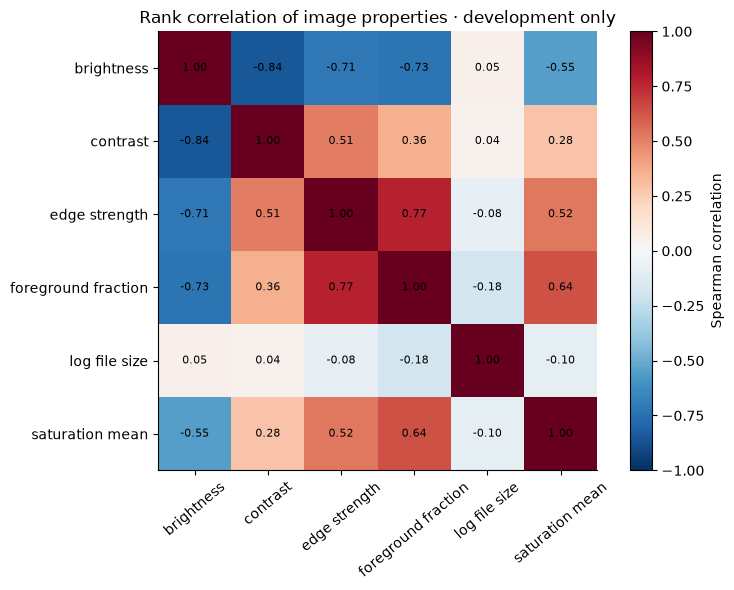

In [8]:
quality_correlation = diagnostics[quality_features].corr(method='spearman')
fig, ax = plt.subplots(figsize=(8, 6))
heat = ax.imshow(quality_correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = [name.replace('_',' ') for name in quality_features]
ax.set(xticks=range(len(labels)), xticklabels=labels, yticks=range(len(labels)), yticklabels=labels,
       title='Rank correlation of image properties · development only')
ax.tick_params(axis='x', rotation=40)
for i, j in np.ndindex(quality_correlation.shape):
    ax.text(j,i,f'{quality_correlation.iloc[i,j]:.2f}',ha='center',va='center',fontsize=8)
fig.colorbar(heat, ax=ax, label='Spearman correlation')
fig.tight_layout()
fig.savefig(FIGURES/'eda_quality_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Shared EDA: transform risks

Check the visible effect of stretching, cropping, padding and light changes.

### 5.1 Compare image transforms on the same products

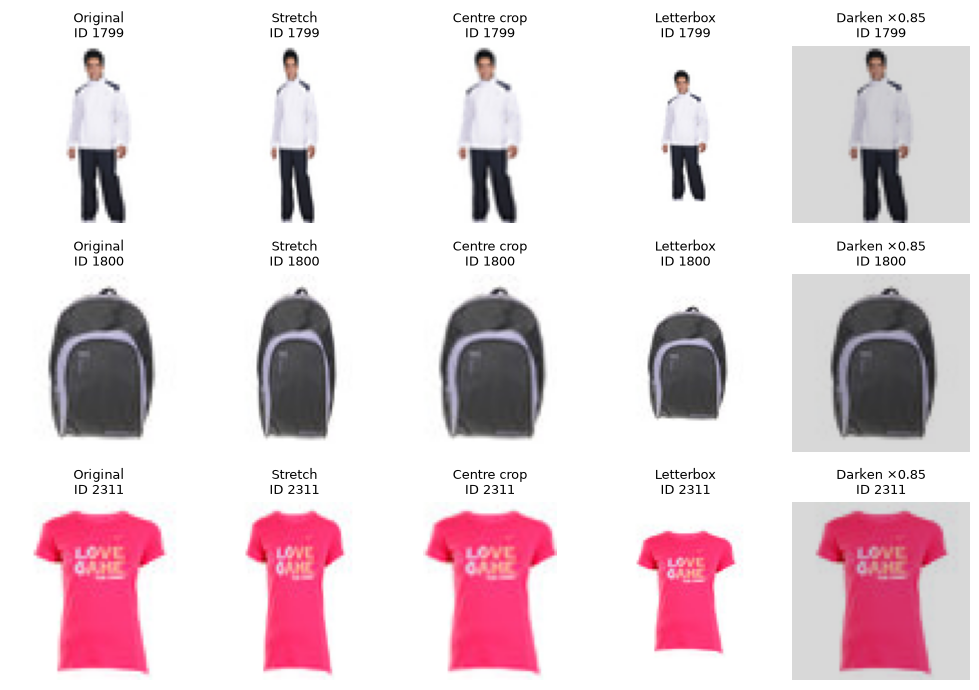

In [9]:
transform_rows = development.loc[development.width.ne(60)|development.height.ne(
    80)].sort_values('id').head(3)
fig, axes = plt.subplots(len(transform_rows), 5, figsize=(10, 7), squeeze=False)
for axes_row, row in zip(axes, transform_rows.itertuples()):
    with Image.open(REPO_DIR/row.path) as image:
        original = ImageOps.exif_transpose(image).convert('RGB')
        views = [original, original.resize((60,80)), ImageOps.fit(original,(60,80)),
                 ImageOps.pad(original,(60,80),color='white'), ImageEnhance.Brightness(
                     original).enhance(.85)]
    for ax, view, name in zip(axes_row, views, ['Original','Stretch','Centre crop',
        'Letterbox','Darken ×0.85']):
        ax.imshow(view)
        ax.set_title(f'{name}\nID {row.id}', fontsize=9)
        ax.axis('off')
fig.tight_layout()
fig.savefig(FIGURES/'eda_transform_risk.png', dpi=150, bbox_inches='tight')
plt.show()

**Baseline preprocessing and rationale**

| Choice | Exact baseline value | Reason |
|---|---|---|
| Input | `3×80×60` | Matches native image information |
| Geometry | EXIF, RGB, aspect preservation, LANCZOS letterbox only for unusual images | Avoid stretch and crop damage |
| Padding | White before scaling; neutral zero after standardisation | Match catalogue boundary without fitting padding |
| Normalisation | RGB mean/std fitted on current fold-training content pixels | Keep learned preprocessing inside the fold |
| Augmentation | None | Expose the raw train–validation and robustness gap |
| Validation | Deterministic transform only | Make candidate comparisons exact |

`(128,96)`, augmentation, another loss, or another transform is not a mandatory menu. It is a
single-factor child only when an accepted parent's evidence triggers it.

Stretching changes proportions; centre cropping can cut off the item. Letterboxing preserves it but moves boundaries and adds padding. These examples explain the baseline geometry rule; they do not establish that larger inputs add information. More pixels made from the same small JPEG cannot recover missing detail.

## 6. Shared EDA: class counts and independent families

A large product count can hide a very small number of independent examples.

### 6.1 Count products and families for both targets

development_product_count  development_family_count  \
target class                                                               
gender Boys                                684                       397   
       Girls                               543                       336   
       Men                               17753                     12345   
       Unisex                             1766                      1428   
       Women                             12027                      8401   
usage  Casual                            25151                     17637   
       Ethnic                             2183                      1351   
       Formal                             1949                      1016   
       Home                                  1                         1   
       NA                                   61                        49   
       Party                                12                        10   
       Smart Casual                         47                        37   
       Sports                             3346                      3020   
       Travel                               22                        22   

                     minimum_fold_training_products  untrainable_fold_count  
target class                                                                 
gender Boys                                     546                       0  
       Girls                                    433                       0  
       Men                                    14201                       0  
       Unisex                                  1411                       0  
       Women                                   9621                       0  
usage  Casual                                 20114                       0  
       Ethnic                                  1745                       0  
       Formal                                  1553                       0  
       Home                                       0                       1  
       NA                                        47                       0  
       Party                                      9                       0  
       Smart Casual                              37                       0  
       Sports                                  2675                       0  
       Travel                                    17                       0

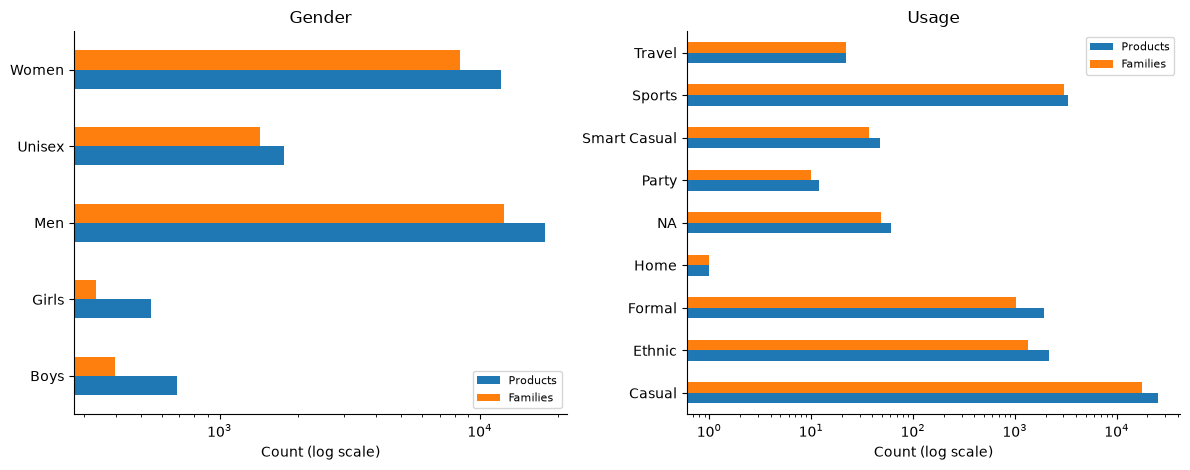

In [10]:
support = pd.read_csv(REPO_DIR / 'data/processed/development_class_summary.csv',
    keep_default_na=False)
support = support.loc[support.target.isin(['gender','usage'])].copy()
display(support[['target','class','development_product_count','development_family_count',
                 'minimum_fold_training_products','untrainable_fold_count']].set_index([
                     'target','class']))
fig, axes = plt.subplots(1,2,figsize=(12,4.8))
for ax, target in zip(axes,['gender','usage']):
    rows = support.loc[support.target.eq(target)].set_index('class')
    rows[['development_product_count','development_family_count']].rename(
        columns={'development_product_count':'Products',
            'development_family_count':'Families'}).plot.barh(ax=ax)
    ax.set(xscale='log', xlabel='Count (log scale)', ylabel='', title=target.title())
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "eda_class_support.png", dpi=150, bbox_inches="tight")
plt.show()

Gender ranges from 17,753 Men products to 543 Girls products. Usage ranges from 25,151 Casual products to one Home product. Macro-F1 gives each label the same weight, so mistakes on small classes matter even when accuracy is high. A family may contain very similar items; its members are not independent draws. Class weighting can change the penalty for an error, but it cannot create a second Home family.

## 7. Shared EDA: duplicate groups and fold support

Keep all family members on one side of each evaluation.

### 7.1 Check group crossings and show family sizes

,Count
Products,32773
Families,22905
Family fold crossings,0
Duplicate fold crossings,0


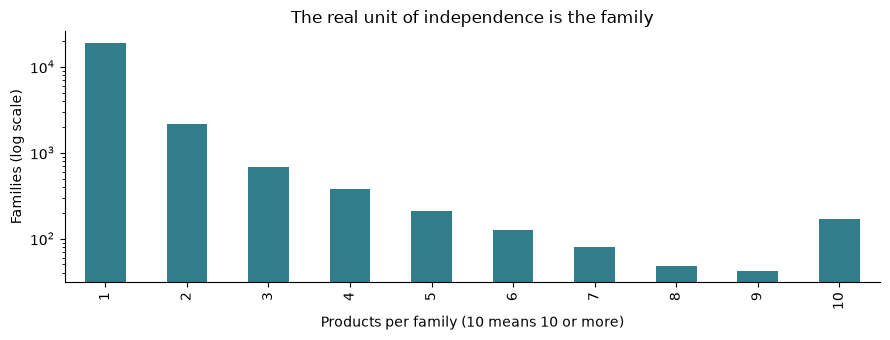

In [11]:
family_crossings = development.groupby('product_family_group').cv_fold.nunique()
duplicate_crossings = development.groupby('duplicate_group').cv_fold.nunique()
assert family_crossings.max() == 1 and duplicate_crossings.max() == 1
family_sizes = development.groupby('product_family_group').size()
display(pd.Series({'Products':len(development),'Families':len(family_sizes),
                   'Family fold crossings':int(family_crossings.gt(1).sum()),
                   'Duplicate fold crossings':int(duplicate_crossings.gt(1).sum())}).to_frame(
                       'Count'))
fig, ax = plt.subplots(figsize=(9,3.5))
family_sizes.clip(upper=10).value_counts().sort_index().plot.bar(ax=ax,color='#327d8b')
ax.set(yscale='log',xlabel='Products per family (10 means 10 or more)',
    ylabel='Families (log scale)',
       title='The real unit of independence is the family')
fig.tight_layout()
fig.savefig(FIGURES/'eda_family_sizes.png',dpi=150,bbox_inches='tight')
plt.show()

### 7.2 Show every Usage class in every validation fold

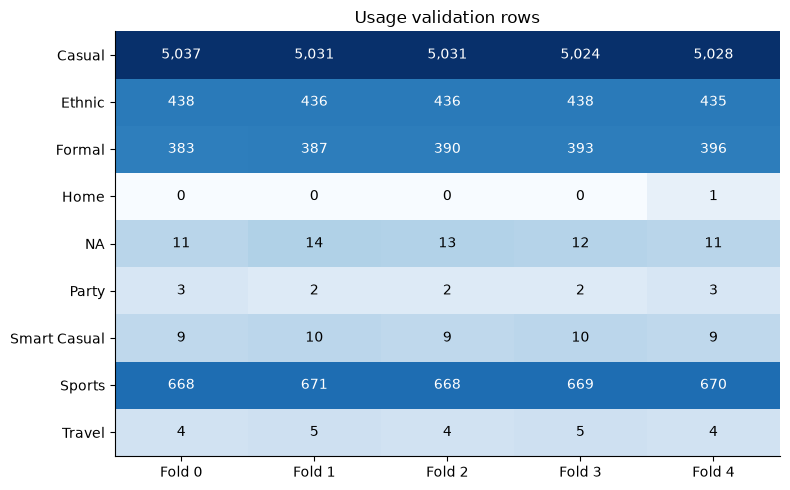

In [12]:
fold_support = support.loc[support.target.eq('usage')].set_index('class')
values = fold_support[[f'fold_{i}_validation_products' for i in range(5)]].to_numpy(int)
fig, ax = plt.subplots(figsize=(8,5))
ax.imshow(np.log1p(values),cmap='Blues',aspect='auto')
ax.set(xticks=range(5),xticklabels=[f'Fold {i}' for i in range(5)],
       yticks=range(len(fold_support)),yticklabels=fold_support.index,title='Usage validation rows')
for i,j in np.ndindex(values.shape):
    ax.text(j,i,f'{values[i,j]:,}',ha='center',va='center',color='white' if values[i,
        j]>300 else 'black')
fig.tight_layout()
fig.savefig(FIGURES/'eda_usage_fold_support.png',dpi=150,bbox_inches='tight')
plt.show()

**Why grouping matters.** Exact bytes detect copied files, while reviewed perceptual matches and normalised product names catch a broader family. Broad name matches were reviewed because a generic shared name can wrongly merge different items. Conflicting labels and cross-role duplicate risks were handled before the split. The saved grouping is deliberately retained; model scores cannot justify regrouping a difficult example.

**Why Home remains a limit.** Its single validation occurrence has no Home example in that fold's training complement. Zero recall there is a structural support failure, not evidence that a larger network would solve it. The official nine-class score still includes Home; the without-Home diagnostic must be named separately. Family bootstrap intervals resample families rather than pretend every near duplicate is independent.

### 7.3 Inspect actual repeated-family examples

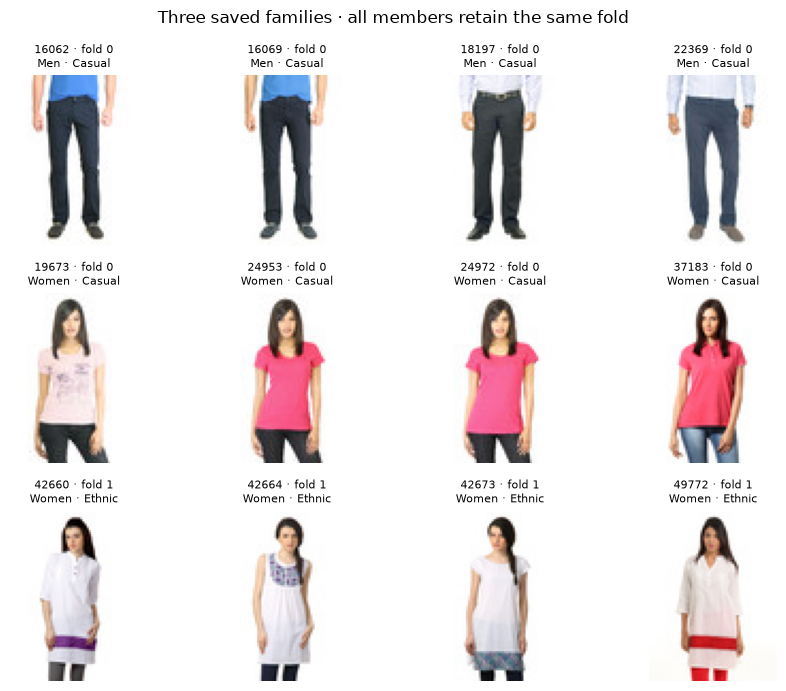

In [13]:
chosen_families = family_sizes.loc[family_sizes.ge(3)].sort_index().head(3).index
fig, axes = plt.subplots(3,4,figsize=(9,7))
for axes_row, family in zip(axes,chosen_families):
    rows = development.loc[development.product_family_group.eq(family)].sort_values('id').head(4)
    for ax in axes_row:
        ax.axis('off')
    for ax,row in zip(axes_row,rows.itertuples()):
        with Image.open(REPO_DIR/row.path) as image:
            ax.imshow(image.convert('RGB'))
        ax.set_title(f'{row.id} · fold {row.cv_fold}\n{row.gender} · {row.usage}',fontsize=8)
fig.suptitle('Three saved families · all members retain the same fold')
fig.tight_layout()
fig.savefig(FIGURES/'eda_family_examples.png',dpi=150,bbox_inches='tight')
plt.show()

## 8. Shared EDA: target relationships and shortcuts

Check what a model could learn from class priors, article type and acquisition cues.

### 8.1 Count the observed Gender–Usage pairs

Observed label pairs: 26 of 45


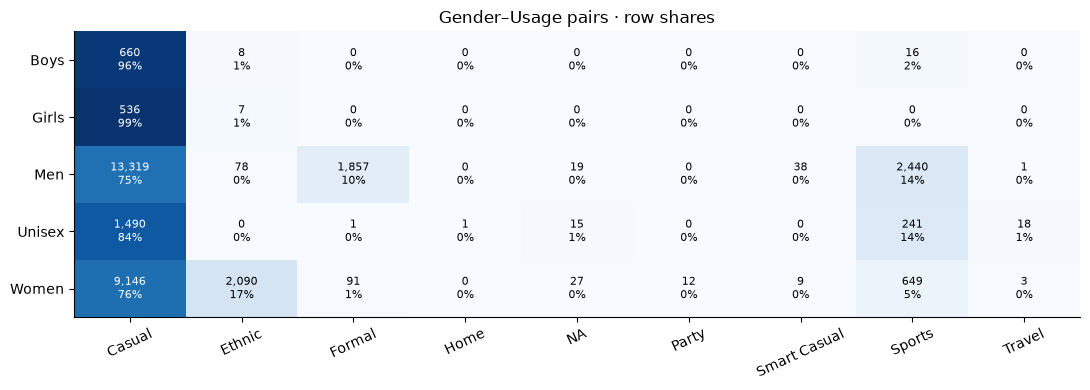

In [14]:
joint = pd.crosstab(usage_development.gender,usage_development.usage)
shares = joint.div(joint.sum(axis=1),axis=0)
fig, ax = plt.subplots(figsize=(11,4))
ax.imshow(shares,cmap='Blues',vmin=0,vmax=1,aspect='auto')
ax.set(xticks=range(len(joint.columns)),xticklabels=joint.columns,
       yticks=range(len(joint)),yticklabels=joint.index,title='Gender–Usage pairs · row shares')
ax.tick_params(axis='x',rotation=25)
for i,j in np.ndindex(joint.shape):
    ax.text(j,i,f'{joint.iloc[i,j]:,}\n{shares.iloc[i,j]:.0%}',ha='center',va='center',fontsize=8,
            color='white' if shares.iloc[i,j]>.55 else 'black')
print('Observed label pairs:',int(joint.gt(0).sum().sum()),'of',joint.size)
fig.tight_layout()
fig.savefig(FIGURES/'eda_target_relationships.png',dpi=150,bbox_inches='tight')
plt.show()

### 8.2 Measure descriptive article-type and acquisition shortcuts

Target,gender,usage
Feature,,
articleType,78.54,90.04
file_size_band,54.17,76.75
mode,54.17,76.75
year,58.50,76.75


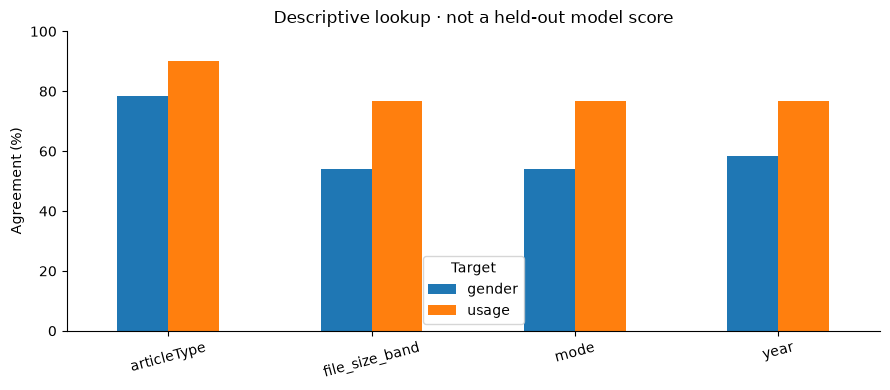

In [15]:
shortcut_rows = []
for target in ['gender','usage']:
    rows = development.loc[development[f'has_{target}_label'].eq(True)].copy()
    rows['file_size_band'] = pd.qcut(rows.file_size_bytes.astype(float),10,
        duplicates='drop').astype(str)
    for feature in ['articleType','year','mode','file_size_band']:
        counts = pd.crosstab(rows[feature],rows[target])
        shortcut_rows.append([target,feature,100*counts.max(axis=1).sum()/counts.to_numpy().sum()])
shortcuts = pd.DataFrame(shortcut_rows,columns=['Target','Feature',
    'Descriptive majority agreement (%)'])
display(shortcuts.pivot(index='Feature',columns='Target',
    values='Descriptive majority agreement (%)').round(2))
fig, ax = plt.subplots(figsize=(9,4))
shortcuts.pivot(index='Feature',columns='Target',
    values='Descriptive majority agreement (%)').plot.bar(ax=ax,rot=15)
ax.set(ylim=(0,100),ylabel='Agreement (%)',xlabel='',
    title='Descriptive lookup · not a held-out model score')
fig.tight_layout()
fig.savefig(FIGURES/'eda_shortcut_agreement.png',dpi=150,bbox_inches='tight')
plt.show()

Only 26 of 45 Gender–Usage pairs occur. This dependence does not license filling missing labels or hard-coding impossible pairs. Article type agrees with roughly 78.5% of Gender and 90.0% of Usage labels through a descriptive majority lookup. That is a shortcut warning, not cross-validated performance: the lookup used these same labels.

Year, mode and file-size bands can reflect catalogue sources or compression. Their high raw agreement can also come from the majority class alone. They are therefore slices for diagnosis, not proof of usable extra information. Article type remains outside the image-only input. A later type-to-Usage cascade must predict type from the image inside each training fold; it cannot read the row's true type at inference.

## 9. Start with the baseline

Use the EDA to justify a bounded scratch model, then let the errors guide the next change.

**Exact primary learnable baseline**

Train one fixed design as two separate scratch models:

```text
Conv3x3 3->32   + BatchNorm + ReLU + MaxPool2
Conv3x3 32->64  + BatchNorm + ReLU + MaxPool2
Conv3x3 64->128 + BatchNorm + ReLU + MaxPool2
Conv3x3 128->256 + BatchNorm + ReLU
Adaptive global average pooling
Linear 256->5 or Linear 256->9
```

**Why this depth and spatial reduction follow from the EDA**

The three pooling steps follow the observed native image size:

```text
80×60 -> 40×30 -> 20×15 -> 10×7
```

A `10×7` final grid still keeps separate evidence for small product regions. A fourth pool would
reduce these tiny inputs to about `5×3`, making it easier to lose straps, sleeves, collars, and
other edge details seen in the contact sheet. The fourth convolution therefore adds feature
capacity without another spatial reduction. With four `3×3` convolutions and three pools, one
final-grid position sees about a `38×38` source region; global average pooling then combines the
whole set of positions without tying a feature to one fixed product location.

**Honest boundary on the channel counts**

The EDA justifies a small native-resolution CNN, three reductions, local-to-global feature
learning, and a bounded scratch capacity. It does **not** prove that `32,64,128,256` is optimal.
Those widths are a predeclared capacity hypothesis. As each pool removes about three quarters
of the spatial positions, the next block gets more feature channels while total activation size
continues to fall. The result is 390,181 trainable parameters for gender and 391,209 for usage.
The first curves decide whether this hypothesis was too small, too large, or trained for too
short a time; the EDA alone does not make that claim.

Batch normalization and ReLU are optimisation controls, not EDA discoveries. No dropout, class
weighting, augmentation, or pretrained weights are added because there is no parent-model
evidence for those changes yet.

Fixed recipe: Kaiming random initialisation, unweighted cross-entropy, AdamW, learning rate
`0.001`, weight decay `0.0001`, batch 128, 30 epochs, cosine decay to `0.00001`, no mixed
precision, no early stopping, final-epoch OOF checkpoint, seed 2753.

This is the architecture used by the saved baseline runs.
The trained model is the `final_epoch.pt` checkpoint inside each registered fold folder. The historical run audit checked each bundle. This notebook verifies the pinned registry and analysis sources before recomputing the displayed results.

If curves have not settled at epoch 30, the first child changes only the budget. The original rule kept the architecture fixed at this step.

**Lower bounds and integrity checks.** A fold-training majority predictor measures the class prior; a stratified predictor checks label order and the random seed. Bias-only and shuffled-label fits test for accidental label access. A tiny-batch overfit check asks whether optimisation can fit a small known batch at all. These are code checks, not candidates for the final model. HOG + HSV logistic regression is the classical shape-and-colour reference. Scratch model weights are required; a pretrained comparison could only be an explicitly separate benchmark.

### 9.1 Recompute the comparison from registered confusion counts

In [16]:
selected_stages = ['baseline', 'usage1']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
E1 · SmallCNN,gender,"[0, 1, 2, 3, 4]",Original,32773,71.18,87.68
Usage E1 · Baseline,usage,"[0, 1, 2, 3, 4]",Original,32772,37.38,89.30


### 9.2 Plot class gains and losses on the same folds

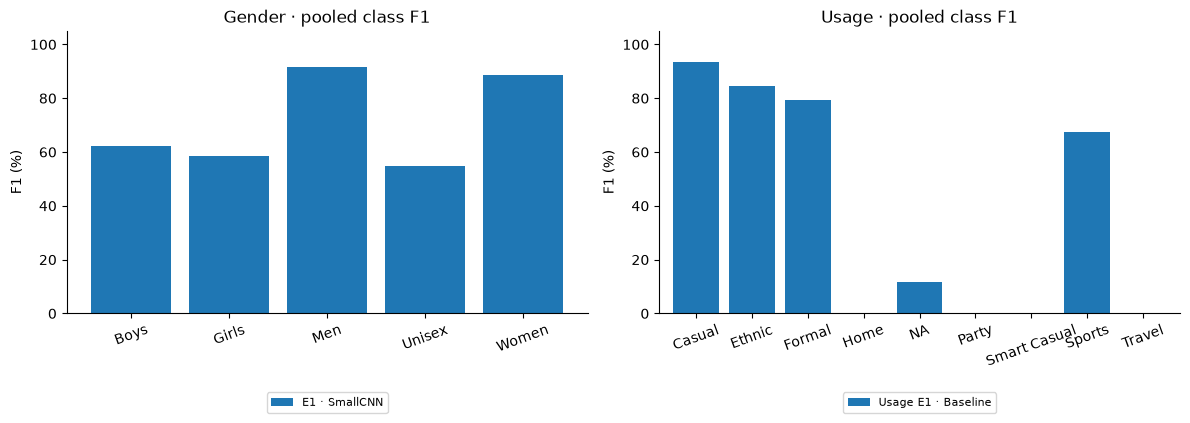

In [17]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "baseline_classes.png", dpi=150, bbox_inches="tight")
plt.show()

### 9.3 Read matched corruption results for every saved fold

In [18]:
robustness_keys=['baseline']
robustness_sources={key:evidence_lock['stages'][key]['robustness_paths'] for key in robustness_keys}
robustness_frames=[]
for key, paths in robustness_sources.items():
    stage=evidence_lock['stages'][key]
    paths = [str(p).replace('reports/task3_', 'reports/task3/', 1) for p in paths]
    rows=pd.concat([pd.read_csv(REPO_DIR/path) for path in paths],ignore_index=True)
    assert set(rows.run_id)==set(stage['run_ids'])
    rows['Stage'],rows['Target']=stage['label'],stage['target']
    robustness_frames.append(rows)
robustness_rows=pd.concat(robustness_frames,ignore_index=True)
induced=robustness_rows.groupby(['Target','Stage','corruption']).macro_f1_change.mean().mul(100)
display(induced.unstack('corruption').round(2))

,corruption,brightness_085,brightness_115,grayscale,jpeg_75,translation_003
Target,Stage,,,,,
gender,E1 · SmallCNN,-25.62,-3.86,-4.14,-4.16,-15.51


### 9.4 Plot the change caused by each corruption

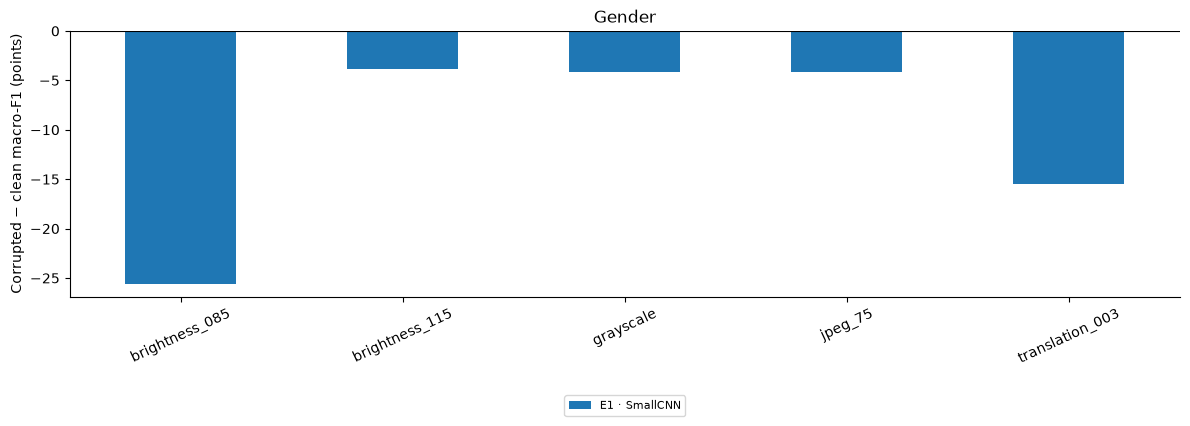

In [19]:
targets=robustness_rows.Target.unique()
fig,axes=plt.subplots(1,len(targets),figsize=(12,4.7),squeeze=False)
for ax,target in zip(axes[0],targets):
    values=induced.loc[target].unstack('Stage')
    values.plot.bar(ax=ax,rot=25)
    ax.axhline(0,color='black',linewidth=.8)
    ax.set(title=target.title(),ylabel='Corrupted − clean macro-F1 (points)',xlabel='')
    ax.legend(fontsize=8,loc='upper center',bbox_to_anchor=(.5,-.35))
fig.tight_layout()
fig.savefig(FIGURES / "baseline_robustness.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Baseline diagnosis: curves, class collapse and confident errors

Separate memorisation, weak labels and unsupported classes before proposing fixes.

### 10.1 Read the baseline learning records

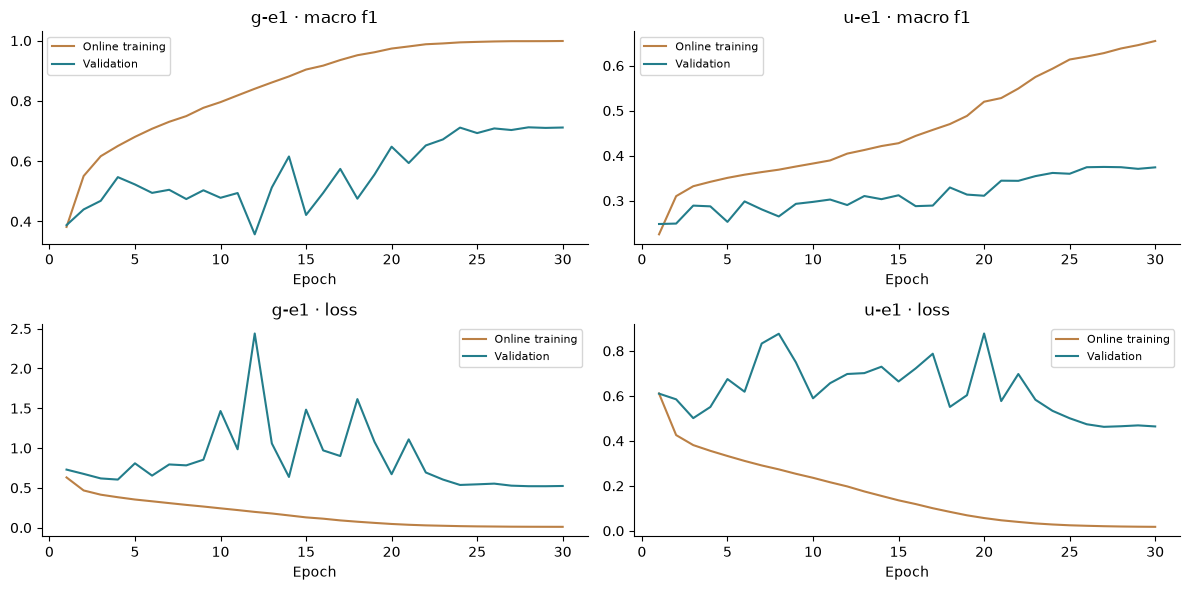

In [20]:
historical_curves = pd.read_csv(
    REPO_DIR / 'reports/task3/failure_review/evidence/all_model_curve_means.csv',
        keep_default_na=False)
fig, axes = plt.subplots(2,2,figsize=(12,6))
for column,model_id in enumerate(['g-e1','u-e1']):
    rows = historical_curves.loc[historical_curves.model_id.eq(model_id)]
    for row,metric in enumerate(['macro_f1','loss']):
        ax = axes[row,column]
        ax.plot(rows.epoch,rows['train_'+metric],label='Online training',color='#bb8045')
        ax.plot(rows.epoch,rows['validation_'+metric],label='Validation',color='#237d8b')
        ax.set(title=model_id+' · '+metric.replace('_',' '),xlabel='Epoch')
        ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "baseline_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

**Gender baseline diagnosis and next gate**

**Decision: accept E1 as the reference parent, not as the final model.**

- Pooled OOF macro-F1 is **0.7118**. Fold scores are 0.6982, 0.7068, 0.7048,
  0.7207, and 0.7279: mean 0.7117, standard deviation 0.0109. The result is stable across
  the five family-safe folds.
- The final online training macro-F1 is about 0.999 in every fold while OOF stays near 0.71.
  Final training loss averages about 0.0107. This is strong memorisation evidence.
- Validation loss reaches its minimum at epochs 3–6, then rises, while the best validation
  macro-F1 arrives at epochs 24–30. Early stopping on loss would therefore hurt the frozen
  primary metric. The model becomes more certain before its minority decisions finish improving.
- Men F1 is 0.9167 and Women F1 is 0.8878. Boys, Girls, and Unisex are much weaker at
  0.6222, 0.5851, and 0.5470. Class support explains part, but not all, of this gap.
- The largest error routes are Women→Men (1,026), Men→Women (854), and Unisex→Men
  (516). Gender presentation is often weak or absent in product-only images.
- Mean macro-F1 change is −0.2562 under brightness ×0.85 and −0.1551 under a 3%
  translation. JPEG 75, grayscale, and brightness ×1.15 each cost about 0.04 or less.
- The selected 40 highest-confidence errors all have confidence at least 0.99. The gallery
  contains fragrances, watches, shoes, and other products with weak audience cues. Average
  ECE is only 0.0756, so the mean calibration score hides these extreme local mistakes.

The first eligible child changes only one factor: add mild random brightness during training.
Architecture, input size, loss, optimiser, schedule, seed, folds, and final-epoch rule stay fixed.
Class weighting, translation, more pixels, and a new architecture are not added to this child.

**Usage baseline diagnosis and next gate**

**Decision at this stage: keep E1 as the reference parent.** Its later acceptance for accuracy is recorded in Section 43; the weaknesses below still apply.

- Pooled OOF macro-F1 is **0.3738**, or **0.4205** without the one-example Home class.
  Fold macro-F1 ranges from 0.3609 to 0.3960, with standard deviation 0.0121.
- Accuracy is 0.8930, but 25,151 of 32,772 valid rows (76.7%) are Casual. Accuracy and
  weighted-F1 mainly describe the large classes and hide rare-class failure.
- Casual, Ethnic, Formal, and Sports reach F1 values of 0.9329, 0.8463, 0.7939, and
  0.6731. NA reaches only 0.1176. Home, Party, Smart Casual, and Travel all score zero.
- The model predicts no Home, Party, or Smart Casual examples. It predicts Travel once,
  incorrectly. It sends 1,255 Sports, 450 Formal, 391 Ethnic, 55 NA, 36 Smart Casual,
  17 Travel, 9 Party, and the one Home row to Casual.
- Final training loss averages about 0.0177, but pooled OOF NLL is 0.4641. Validation loss
  bottoms at epochs 6–13 while the best macro-F1 appears at epochs 26–30. As with gender,
  loss-based early stopping would select the wrong model for the primary metric.
- Mean robustness drops are smaller than gender: −0.0668 for darkening and −0.0642 for
  translation. This does not make Usage strong; its clean macro-F1 is already low.
- The error gallery shows real visual overlap. Sports and Casual shirts or shoes can look
  alike, and business labels such as Formal, Party, and Travel are not always visible from
  one product image. Weighting cannot create missing visual information.

The first eligible child changes only the loss to capped class-balanced cross-entropy. It uses
effective-number weights with `beta=0.999`, mean-one nonzero normalisation, cap 5, and only
the current fold's training counts. `Home` does not select or judge the child. Architecture,
input, augmentation, optimiser, schedule, seed, folds, and checkpoint rule stay fixed.

### 10.2 Read confident Gender mistakes on development images

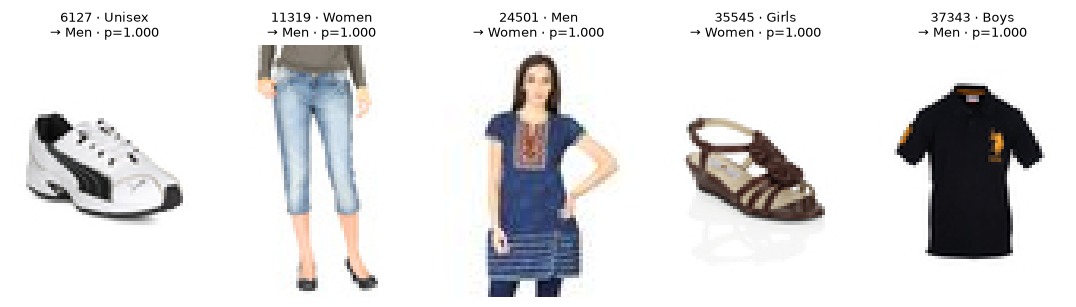

In [21]:
errors = pd.read_csv(
    REPO_DIR / 'results/evidence/task3/baseline/gender/aggregate/failure_index.csv',
        keep_default_na=False)
errors = errors.loc[errors.true_label.ne(errors.predicted_label)]
errors = errors.sort_values(['confidence','id'],ascending=[False,True]).drop_duplicates(
    'true_label')
fig, axes = plt.subplots(1,5,figsize=(11,3))
for ax,row in zip(axes,errors.itertuples()):
    assert row.id in set(development.id)
    with Image.open(REPO_DIR/row.path) as image:
        ax.imshow(image.convert('RGB'))
    ax.set_title(f'{row.id} · {row.true_label}\n→ {row.predicted_label} · p={
        row.confidence:.3f}',fontsize=9)
    ax.axis('off')
fig.tight_layout()
fig.savefig(FIGURES / "baseline_confident_errors.png", dpi=150, bbox_inches="tight")
plt.show()

The gallery selects the highest-confidence saved mistake per true Gender class, breaking ties by ID. It is an error audit, not an estimate of the error rate. A confident wrong watch or shoe supports the concern that the model uses catalogue associations. It does not prove which internal feature caused that one prediction.

## 11. E2: light augmentation and class weighting

Historical hypothesis → matched result → decision. The original gates remain unchanged after seeing the outcome.

**Hypotheses.** Gender E2 tests whether the measured dark-image weakness comes from a lack of brightness variation during training. Usage E2 tests whether capped class weights can recover supported rare classes without sacrificing Casual and Sports. Each target changes one factor and keeps the E1 architecture, folds, seed and schedule.

### 11.1 Recompute the comparison from registered confusion counts

In [22]:
selected_stages = ['baseline', 'brightness', 'usage1', 'usage2']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
E1 · SmallCNN,gender,"[0, 1, 2, 3, 4]",Original,32773,71.18,87.68
E2 · Brightness,gender,"[0, 1, 2, 3, 4]",Original,32773,69.89,87.30
Usage E1 · Baseline,usage,"[0, 1, 2, 3, 4]",Original,32772,37.38,89.30
Usage E2 · Class weights,usage,"[0, 1, 2, 3, 4]",Original,32772,40.82,89.15


### 11.2 Plot class gains and losses on the same folds

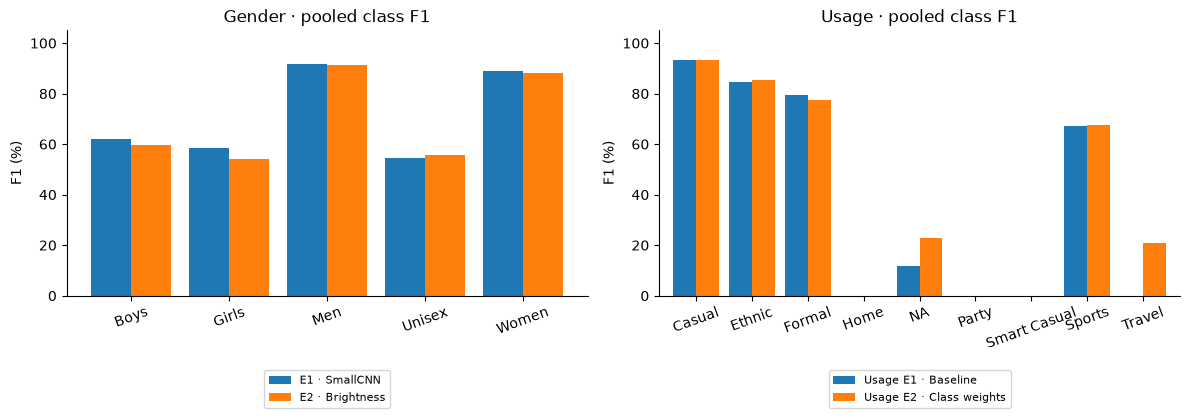

In [23]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "e28_classes.png", dpi=150, bbox_inches="tight")
plt.show()

### 11.3 Inspect learning curves from the saved epoch records

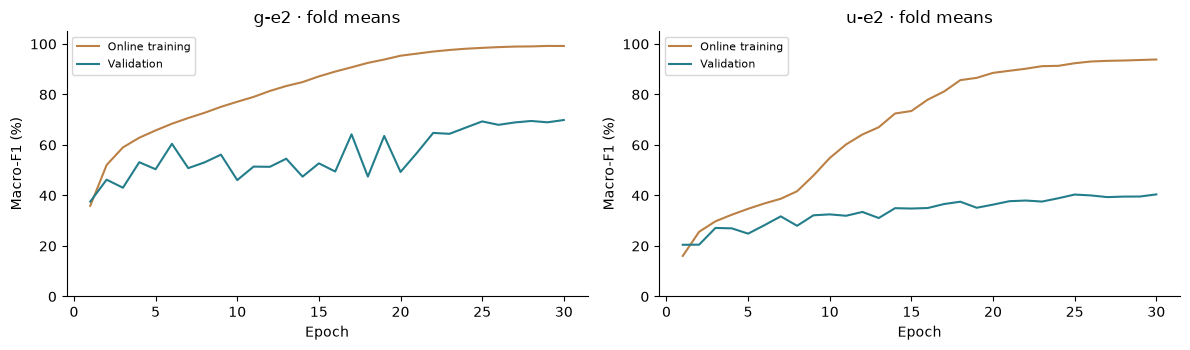

In [24]:
curve_ids = ['g-e2', 'u-e2']
fig, axes = plt.subplots(1, len(curve_ids), figsize=(12, 3.6), squeeze=False)
for ax, model_id in zip(axes[0], curve_ids):
    rows = historical_curves.loc[historical_curves.model_id.eq(model_id)]
    assert len(rows), model_id
    ax.plot(rows.epoch, rows.train_macro_f1*100, label='Online training', color='#bb8045')
    ax.plot(rows.epoch, rows.validation_macro_f1*100, label='Validation', color='#237d8b')
    ax.set(title=model_id+' · fold means', xlabel='Epoch', ylabel='Macro-F1 (%)', ylim=(0,105))
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "e28_classes_curves.png", dpi=150, bbox_inches="tight")
plt.show()

**Gender E2 — reject brightness augmentation**

Gender E2 reached **0.6989 pooled macro-F1**, down **0.0129** from 0.7118. It missed
the frozen 0.7218 gate by 0.0229. Accuracy fell from 0.8768 to 0.8730 and balanced
accuracy fell from 0.6933 to 0.6767. Final fold macro-F1 values were 0.7279, 0.6774,
0.6740, 0.7260, and 0.6889. Their standard deviation was 0.0263, compared with 0.0109
for E1, so the child was also less stable across folds.
The fold scores makes the instability visible: E2 improves folds 0 and 3, but loses on folds 1,
2, and 4. Its learning curves still drive training macro-F1 close to 1.0 while validation stays
near 0.70 and moves sharply between epochs. Brightness did not reduce memorisation.


The common-class guard passed, but the primary gate did not. Boys and Girls lost more than
Unisex gained. Even if the robustness table shows better dark-image behaviour, the rule required
both robustness and clean macro-F1. Random brightness therefore changes the input without fixing
the main generalisation error. **E2 is rejected and E1 remains the Gender parent.**

**Usage E2 — accept class-balanced cross-entropy**

Usage E2 reached **0.4082 pooled macro-F1**, up **0.0344** from 0.3738, and reached
**0.4592 without Home**, up **0.0387** from 0.4205. Both frozen gates passed. Balanced
accuracy improved from 0.3571 to 0.3826 while ordinary accuracy moved only from 0.8930
to 0.8915. This is the intended trade: better treatment of supported minority classes with
almost no loss on the majority-dominated accuracy.

Calibration also improved: NLL fell from 0.4641 to 0.3428 and ECE fell from 0.0672 to
0.0331. Final fold macro-F1 values were 0.4086, 0.3818, 0.4362, 0.3999, and 0.3950.
Their standard deviation was 0.0203, higher than E1's 0.0121, so the gain is useful but
not equally strong in every fold.
The fold scores shows improvement in four of five folds; only fold 4 is effectively flat. The
learning curves still show a large train-validation gap, but validation macro-F1 rises more
consistently than Gender. This supports keeping the new loss while testing one small
regularisation change next.


Casual stayed flat and Sports improved, so the no-harm guard passed. The largest gains came
from NA and Travel, but Party, Smart Casual, and the one-row Home class remain unlearned.
Formal also fell by 0.0180. Weighting helped the classes that had some learnable evidence; it
could not invent evidence for tiny classes or remove semantic overlap. **E2 is accepted as the
new Usage parent, but not yet declared final.** The saved confusion counts confirm the remaining
failure: Home, Party, and Smart Casual still collapse mostly into Casual; Travel is detected only
three times and NA only ten times.

**Scope.** The proposal and decision wording above describe this historical stage. Later named candidates test new hypotheses; they do not rewrite this stage's acceptance rule.

## 12. E3: rebalance Gender and regularise Usage

Historical hypothesis → matched result → decision. The original gates remain unchanged after seeing the outcome.

**Next hypotheses**

These proposals and gates are frozen before another run. `E1`, `E2`, and `E3` below are
sequential experiment labels, not the research document's evidence-level names. A rejected
change is not stacked: Gender E3 starts from E1. Usage E3 starts from accepted E2.

**Gender E3 hypothesis: mildly weight the supported minority classes**

Brightness augmentation did not close the generalisation gap and hurt Boys and Girls. E1 still
has strong support imbalance: Men and Women dominate, while Boys, Girls, and Unisex have mean
F1 0.5848. Usage E2 shows that this loss can help another target, but it does not prove that it
will help Gender. The cap is a safety bound; the largest expected fold weight is only about 1.66.

| Pre-training decision | Frozen value |
|---|---|
| Parent | Gender E1 baseline; do not inherit brightness augmentation |
| One change | Effective-number class-balanced cross-entropy only: `beta=0.999`, mean-one present-class weights, cap `5.0` |
| Everything kept fixed | SmallCNN, `80×60` input, no augmentation, optimiser, schedule, 30 epochs, seed, folds, final checkpoint |
| Primary success gates | Pooled OOF macro-F1 ≥ 0.7218; mean Boys/Girls/Unisex F1 ≥ 0.6048 |
| Paired uncertainty gate | In a fixed 10,000-sample product-family bootstrap, the 95% interval for macro-F1 change is entirely above zero |
| Class no-harm gates | Men F1 ≥ 0.8967; Women F1 ≥ 0.8678; no class has zero recall; each minority predicted count ≤ 1.5× its support |
| Stability and calibration gates | Fold macro-F1 SD ≤ 0.0209; NLL ≤ 0.5437; ECE-15 ≤ 0.0856 |
| Robustness gate | For every tested corruption, mean macro-F1 change is no more than 0.02 worse than E1 |
| Written before training | Yes |
| Current state | Completed; evaluated in the corresponding historical trial |

**Usage E3 hypothesis: test mild classifier regularisation**

E2 is the accepted parent. Its online training score is much higher than validation, which
suggests overfitting but does not prove the final model memorised the fold. E3 therefore adds
dropout only after global pooling and before the final linear classifier. Finished-model training
metrics will be measured in evaluation mode before making a memorisation claim.

| Pre-training decision | Frozen value |
|---|---|
| Parent | Accepted Usage E2 class-balanced SmallCNN |
| One change | Dropout `p=0.20` after global pooling and before the final linear classifier |
| Everything kept fixed | SmallCNN channels, `80×60` input, E2 loss and weights, no augmentation, optimiser, schedule, 30 epochs, seed, folds, final checkpoint |
| Primary success gates | Pooled OOF macro-F1 ≥ 0.4182; macro-F1 without Home ≥ 0.4692 |
| Paired uncertainty gate | In a fixed 10,000-sample product-family bootstrap, the 95% interval for macro-F1 change is entirely above zero |
| Overall no-harm gate | Accuracy ≥ 0.8815 |
| Class no-harm gates | Casual F1 ≥ 0.9018; Ethnic ≥ 0.8240; Formal ≥ 0.7459; Sports ≥ 0.6451 |
| Minority gates | Mean NA/Travel F1 ≥ 0.1984 and both classes retain non-zero recall |
| Stability and calibration gates | Fold macro-F1 SD ≤ 0.0303; NLL ≤ 0.3628; ECE-15 ≤ 0.0431 |
| Robustness gate | For every tested corruption, mean macro-F1 change is no more than 0.02 worse than E2 |
| Written before training | Yes |
| Current state | Completed; evaluated in the corresponding historical trial |

Both next runs keep SmallCNN. A quality-driven architecture test opens only after three seeds
show real underfitting: finished-model train/validation macro-F1 gap ≤ 0.05 in at least four
folds, absolute last-five validation slope < 0.002 per epoch, low training performance, and
errors with learnable image structure rather than tiny support or label ambiguity. The first
architecture candidate would be a scratch low-resolution ResNet-18 with a `3×3` stride-one stem
and no early max-pool. One failed E3 run is not enough to open that test.

### 12.1 Recompute the comparison from registered confusion counts

In [25]:
selected_stages = ['baseline', 'balance', 'usage2', 'usage3']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
E1 · SmallCNN,gender,"[0, 1, 2, 3, 4]",Original,32773,71.18,87.68
E3 · Class weights,gender,"[0, 1, 2, 3, 4]",Original,32773,70.81,87.32
Usage E2 · Class weights,usage,"[0, 1, 2, 3, 4]",Original,32772,40.82,89.15
Usage E3 · Dropout 0.20,usage,"[0, 1, 2, 3, 4]",Original,32772,41.61,89.17


### 12.2 Plot class gains and losses on the same folds

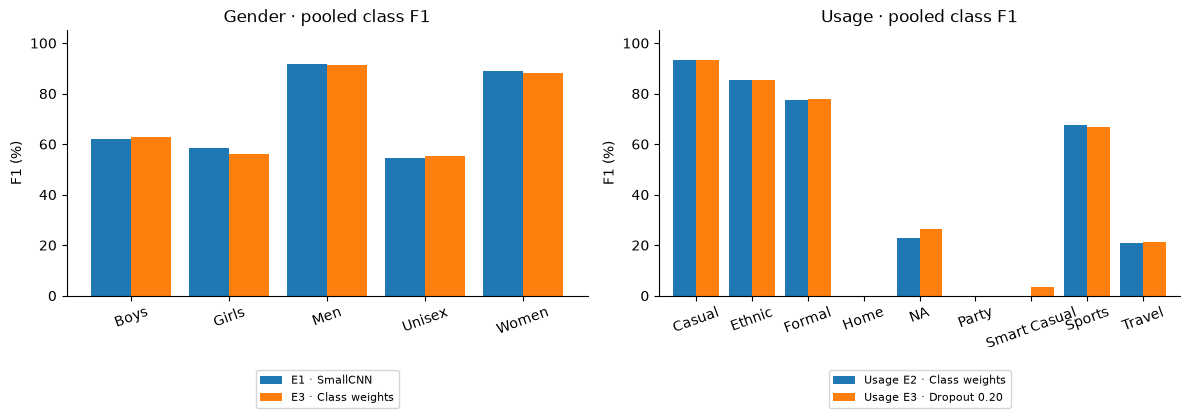

In [26]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "e38_classes.png", dpi=150, bbox_inches="tight")
plt.show()

### 12.3 Inspect learning curves from the saved epoch records

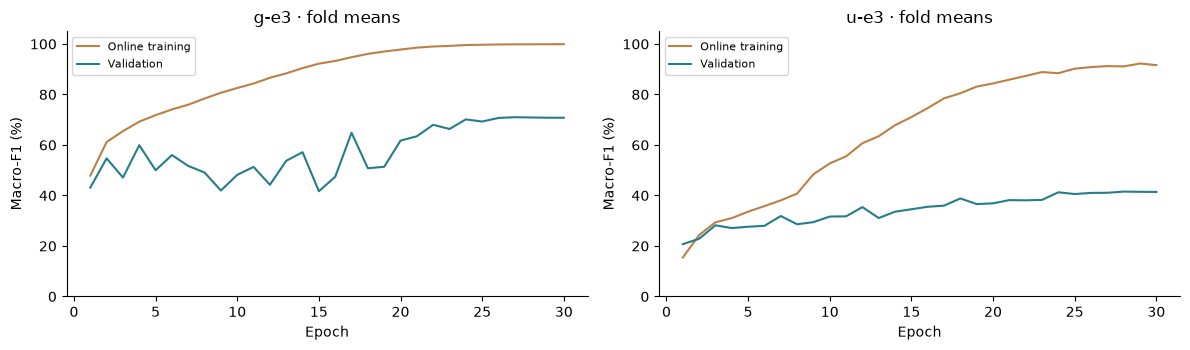

In [27]:
curve_ids = ['g-e3', 'u-e3']
fig, axes = plt.subplots(1, len(curve_ids), figsize=(12, 3.6), squeeze=False)
for ax, model_id in zip(axes[0], curve_ids):
    rows = historical_curves.loc[historical_curves.model_id.eq(model_id)]
    assert len(rows), model_id
    ax.plot(rows.epoch, rows.train_macro_f1*100, label='Online training', color='#bb8045')
    ax.plot(rows.epoch, rows.validation_macro_f1*100, label='Validation', color='#237d8b')
    ax.set(title=model_id+' · fold means', xlabel='Epoch', ylabel='Macro-F1 (%)', ylim=(0,105))
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "e38_classes_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### 12.4 Read matched corruption results for every saved fold

In [28]:
robustness_keys=['baseline', 'balance', 'usage2', 'usage3']
robustness_sources={key:evidence_lock['stages'][key]['robustness_paths'] for key in robustness_keys}
robustness_frames=[]
for key, paths in robustness_sources.items():
    stage=evidence_lock['stages'][key]
    paths = [str(p).replace('reports/task3_', 'reports/task3/', 1) for p in paths]
    rows=pd.concat([pd.read_csv(REPO_DIR/path) for path in paths],ignore_index=True)
    assert set(rows.run_id)==set(stage['run_ids'])
    rows['Stage'],rows['Target']=stage['label'],stage['target']
    robustness_frames.append(rows)
robustness_rows=pd.concat(robustness_frames,ignore_index=True)
induced=robustness_rows.groupby(['Target','Stage','corruption']).macro_f1_change.mean().mul(100)
display(induced.unstack('corruption').round(2))

corruption                       brightness_085  brightness_115  grayscale  \
Target Stage                                                                 
gender E1 · SmallCNN                     -25.62           -3.86      -4.14   
       E3 · Class weights                -23.68           -3.89      -3.87   
usage  Usage E2 · Class weights          -12.89           -3.16      -1.45   
       Usage E3 · Dropout 0.20           -12.52           -3.55      -2.13   

corruption                       jpeg_75  translation_003  
Target Stage                                               
gender E1 · SmallCNN               -4.16           -15.51  
       E3 · Class weights          -3.31           -16.47  
usage  Usage E2 · Class weights    -0.07            -8.69  
       Usage E3 · Dropout 0.20      0.20            -8.58

### 12.5 Plot the change caused by each corruption

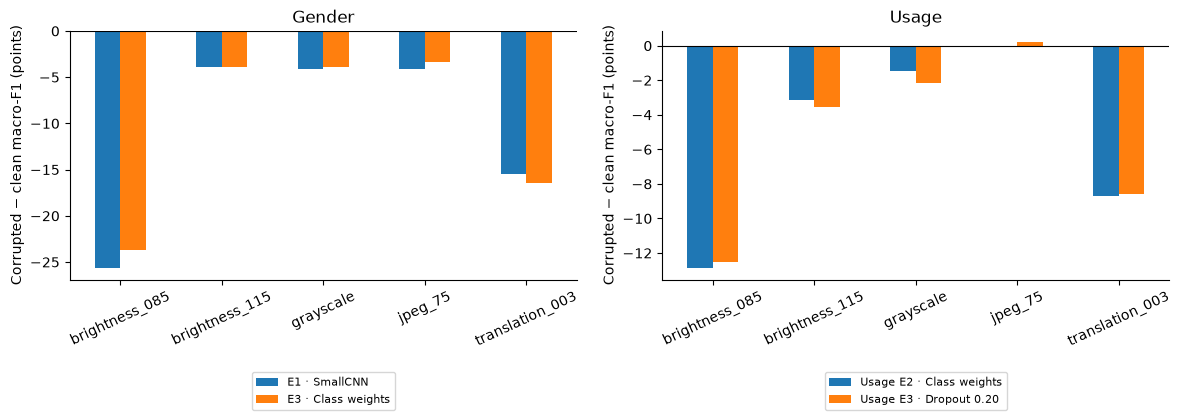

In [29]:
targets=robustness_rows.Target.unique()
fig,axes=plt.subplots(1,len(targets),figsize=(12,4.7),squeeze=False)
for ax,target in zip(axes[0],targets):
    values=induced.loc[target].unstack('Stage')
    values.plot.bar(ax=ax,rot=25)
    ax.axhline(0,color='black',linewidth=.8)
    ax.set(title=target.title(),ylabel='Corrupted − clean macro-F1 (points)',xlabel='')
    ax.legend(fontsize=8,loc='upper center',bbox_to_anchor=(.5,-.35))
fig.tight_layout()
fig.savefig(FIGURES / "e38_robustness.png", dpi=150, bbox_inches="tight")
plt.show()

**E3 result: reject both children under the frozen rules**


**Gender E3 — reject class-balanced loss**

Gender E3 fell about 0.0037 below E1 instead of gaining the required 0.0100. The paired
10,000-sample product-family bootstrap estimated a macro-F1 change of −0.0036 with a 95%
interval from −0.0157 to 0.0085, so the change is not reliably positive. Mean Boys, Girls,
and Unisex F1 was 0.5814, below both the 0.6048 gate and the parent's 0.5848. Boys improved
from 0.6222 to 0.6291 and Unisex from 0.5470 to 0.5532, but Girls fell from 0.5851 to
0.5620. Weighting moved errors among minority classes instead of improving the group.

Men and Women no-harm gates passed, every class retained non-zero recall, fold SD was
0.0149, calibration gates passed, and every corruption stayed within the allowed 0.02
margin. These secondary passes cannot rescue failed primary and paired gates. E1 remains
the accepted Gender parent.

**Usage E3 — reject dropout, while recording a useful near miss**

Usage E3 improved pooled macro-F1 by about 0.0079 to 0.4161, but the frozen gate required
0.4182. Macro-F1 without Home reached 0.4681, just below 0.4692. The family-bootstrap
interval for the change was −0.0069 to 0.0238, so it still includes no improvement.
Accuracy stayed at 0.8917. Casual, Ethnic, Formal, and Sports passed their floors; mean
NA/Travel F1 reached 0.2397 and both retained non-zero recall. Smart Casual moved from zero
to 0.0357, but Home and Party remained at zero. Fold SD was 0.0298, only 0.0005 inside its
limit. NLL, ECE, and robustness all passed. The direction is promising, but the prewritten
rule rejects a small uncertain gain. E2 remains the accepted Usage parent.

**Capacity decision**

The finished Gender models score about 0.999 macro-F1 on their training folds while their
validation folds score 0.6833–0.7238. Finished Usage training scores range from 0.8427 to
0.9584 while validation scores range from 0.3867 to 0.4608. These large gaps show
overfitting, not a model that is too small. They close only the **larger-capacity** gate.
They do not prove that a similarly sized architecture with a better structural bias cannot
generalise better. One parameter-matched residual architecture is therefore allowed; a large
ResNet or architecture sweep remains unjustified.

The E3 loss curves use the corrected sample-weight denominator. They are valid
class-weighted cross-entropy diagnostics, but they are not directly comparable with ordinary
unweighted NLL. Selection still uses pooled OOF macro-F1 and the frozen gates.

**Scope.** The proposal and decision wording above describe this historical stage. Later named candidates test new hypotheses; they do not rewrite this stage's acceptance rule.

## 13. E4: test residual architecture

Historical hypothesis → matched result → decision. The original gates remain unchanged after seeing the outcome.

**E4 hypotheses — parameter-matched TinyResNet-18-PM**

All executed E1–E3 models use the same SmallCNN. That is enough to compare augmentation,
loss weighting, and dropout, but it is not a real architecture comparison. The next child is
therefore one narrow residual network with almost the same parameter count. This tests a
different structural bias, not more capacity.

**Locked architecture**

- 3×3 stem, stride 1, with no early max-pool;
- stages of 12, 24, 48, and 96 channels, with two basic residual blocks per stage;
- downsample only at the first blocks of stages 2–4;
- global average pooling and one target-specific classifier;
- random initialisation only; no pretrained weights.

| Target | Role | Accepted parent | Parent loss kept | TinyResNet parameters | MACs |
|---|---|---|---|---:|---:|
| Gender | controlled architecture benchmark | E1 | ordinary cross-entropy | 394,865 | 94,268,640 |
| Usage | real replacement hypothesis | E2 | effective-number CE, β=0.999, cap=5.0 | 395,253 | 94,269,024 |

**Gender E4 hypothesis.** Delaying spatial reduction and retaining residual paths may preserve
small straps, collars, watch faces, footwear outlines, and other weak target-audience cues better
than SmallCNN's early pooling. Only the model architecture changes from Gender E1.

**Usage E4 hypothesis.** The same residual bias may improve unstable minority usage classes while
retaining the accepted E2 weighting. Only the model architecture changes from Usage E2. Rejected
brightness and dropout changes are not stacked.

Every other control stays fixed: `data/processed/splits.csv`, five folds in order, 80×60 RGB,
fold-only normalisation, seed 2753, batch size 128, AdamW, learning rate 0.001, weight decay
0.0001, cosine schedule, 30 epochs, no augmentation, and the final-epoch checkpoint.

**Frozen E4 acceptance gates**

Every applicable gate must pass.

| Gate | Gender E4 | Usage E4 |
|---|---:|---:|
| pooled OOF macro-F1 | ≥ 0.7218 | ≥ 0.4182 |
| macro-F1 without Home | — | ≥ 0.4692 |
| paired product-family bootstrap lower 95% bound | > 0 | > 0 |
| accuracy | ≥ 0.8668 | ≥ 0.8815 |
| fold macro-F1 SD | ≤ 0.0209 | ≤ 0.0303 |
| folds improved over their matching parent | ≥ 4 of 5 | ≥ 4 of 5 |
| NLL | ≤ 0.5437 | ≤ 0.3628 |
| ECE-15 | ≤ 0.0856 | ≤ 0.0431 |

No-harm guards are also frozen. Gender F1 must be at least Boys 0.6022, Girls 0.5651,
Men 0.8967, Unisex 0.5270, and Women 0.8678; mean Boys/Girls/Unisex F1 must reach 0.6048.
Usage F1 must be at least Casual 0.9118, Ethnic 0.8340, Formal 0.7559, NA 0.2099,
Sports 0.6551, and Travel 0.1869; mean NA/Smart Casual/Travel F1 must reach 0.1556.
Home and Party remain report-only because their supports are 1 and 12. No fold may lose more
than 0.02 macro-F1, and no corruption may be more than 0.02 worse than the exact parent.

Cost gates are ≤ 410,000 parameters, ≤ 105 million MACs, median L4 fold time ≤ 714 seconds
for Gender and ≤ 703 seconds for Usage, batch-one latency ≤ 1.00 ms and ≤ 1.02 ms respectively,
and peak memory ≤ 1.25× the matching parent.

Run seed 2753 first. If any gate fails, stop and retain Gender E1 or Usage E2. If all gates pass,
confirm with matched parent–child runs at seeds 2754 and 2755. A finalist must improve at all
three seeds with mean macro-F1 gain ≥ 0.010.

### 13.1 Recompute the comparison from registered confusion counts

In [30]:
selected_stages = ['baseline', 'resnet', 'usage2', 'usage4']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
E1 · SmallCNN,gender,"[0, 1, 2, 3, 4]",Original,32773,71.18,87.68
E4 · TinyResNet,gender,"[0, 1, 2, 3, 4]",Original,32773,71.21,87.71
Usage E2 · Class weights,usage,"[0, 1, 2, 3, 4]",Original,32772,40.82,89.15
Usage E4 · TinyResNet,usage,"[0, 1, 2, 3, 4]",Original,32772,38.78,87.99


### 13.2 Plot class gains and losses on the same folds

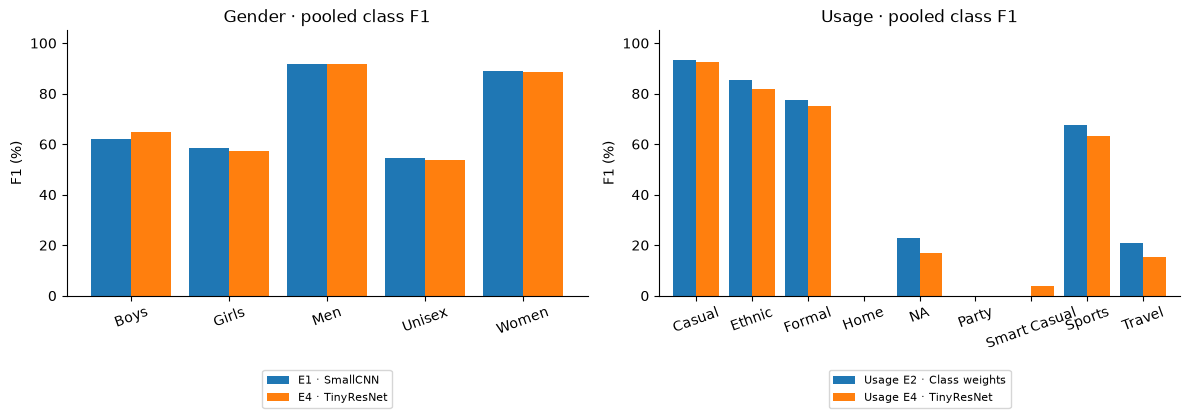

In [31]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "e48_classes.png", dpi=150, bbox_inches="tight")
plt.show()

### 13.3 Inspect learning curves from the saved epoch records

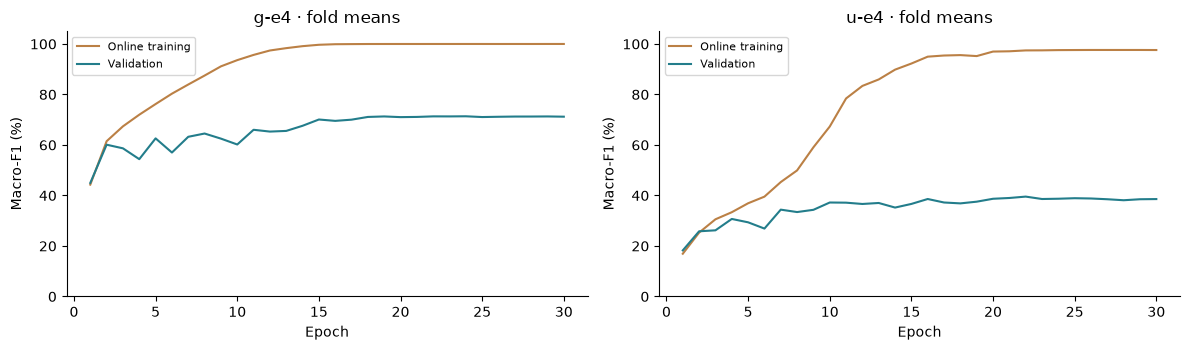

In [32]:
curve_ids = ['g-e4', 'u-e4']
fig, axes = plt.subplots(1, len(curve_ids), figsize=(12, 3.6), squeeze=False)
for ax, model_id in zip(axes[0], curve_ids):
    rows = historical_curves.loc[historical_curves.model_id.eq(model_id)]
    assert len(rows), model_id
    ax.plot(rows.epoch, rows.train_macro_f1*100, label='Online training', color='#bb8045')
    ax.plot(rows.epoch, rows.validation_macro_f1*100, label='Validation', color='#237d8b')
    ax.set(title=model_id+' · fold means', xlabel='Epoch', ylabel='Macro-F1 (%)', ylim=(0,105))
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "e48_classes_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### 13.4 Read matched corruption results for every saved fold

In [33]:
robustness_keys=['baseline', 'resnet', 'usage2', 'usage4']
robustness_sources={key:evidence_lock['stages'][key]['robustness_paths'] for key in robustness_keys}
robustness_frames=[]
for key, paths in robustness_sources.items():
    stage=evidence_lock['stages'][key]
    paths = [str(p).replace('reports/task3_', 'reports/task3/', 1) for p in paths]
    rows=pd.concat([pd.read_csv(REPO_DIR/path) for path in paths],ignore_index=True)
    assert set(rows.run_id)==set(stage['run_ids'])
    rows['Stage'],rows['Target']=stage['label'],stage['target']
    robustness_frames.append(rows)
robustness_rows=pd.concat(robustness_frames,ignore_index=True)
induced=robustness_rows.groupby(['Target','Stage','corruption']).macro_f1_change.mean().mul(100)
display(induced.unstack('corruption').round(2))

corruption                       brightness_085  brightness_115  grayscale  \
Target Stage                                                                 
gender E1 · SmallCNN                     -25.62           -3.86      -4.14   
       E4 · TinyResNet                   -24.18           -5.25      -2.10   
usage  Usage E2 · Class weights          -12.89           -3.16      -1.45   
       Usage E4 · TinyResNet             -10.64           -2.19       0.77   

corruption                       jpeg_75  translation_003  
Target Stage                                               
gender E1 · SmallCNN               -4.16           -15.51  
       E4 · TinyResNet             -1.61           -20.12  
usage  Usage E2 · Class weights    -0.07            -8.69  
       Usage E4 · TinyResNet       -0.10           -13.57

### 13.5 Plot the change caused by each corruption

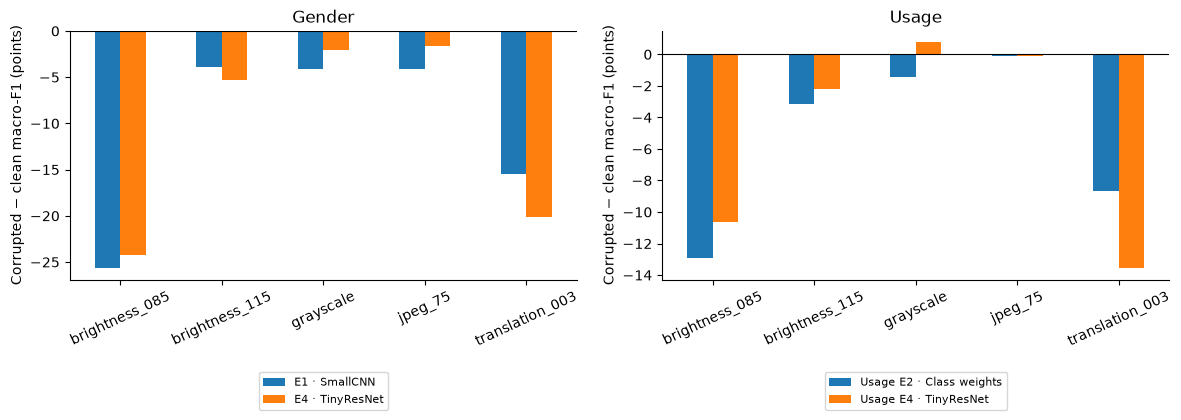

In [34]:
targets=robustness_rows.Target.unique()
fig,axes=plt.subplots(1,len(targets),figsize=(12,4.7),squeeze=False)
for ax,target in zip(axes[0],targets):
    values=induced.loc[target].unstack('Stage')
    values.plot.bar(ax=ax,rot=25)
    ax.axhline(0,color='black',linewidth=.8)
    ax.set(title=target.title(),ylabel='Corrupted − clean macro-F1 (points)',xlabel='')
    ax.legend(fontsize=8,loc='upper center',bbox_to_anchor=(.5,-.35))
fig.tight_layout()
fig.savefig(FIGURES / "e48_robustness.png", dpi=150, bbox_inches="tight")
plt.show()

**E4 result: reject TinyResNet for both targets**


**Gender E4 — a stable but negligible architecture change**

TinyResNet improved four of five folds, but only by 0.0014–0.0049. Fold 4 fell by 0.0097,
leaving pooled macro-F1 almost unchanged at 0.7121. The paired 10,000-sample
product-family bootstrap estimated a change of +0.0002 with a 95% interval from −0.0144
to +0.0154. This is not reliable evidence of improvement and misses the required 0.7218.

All five individual class floors passed. Boys improved by 0.0245, but Girls and Unisex fell,
so mean Boys/Girls/Unisex F1 was only 0.5857 instead of the required 0.6048. Accuracy and
fold stability passed. Calibration did not: NLL rose from 0.5237 to 0.6803 and ECE-15 rose
from 0.0756 to 0.0906. Translation robustness was 0.0460 worse than E1, beyond the 0.02
guard. The model met its parameter, MAC, and training-time budgets, but median latency was
2.5688 ms against 1.00 ms and peak memory reached 1.2759× E1 against 1.25×.

**Usage E4 — clear regression from the accepted E2 parent**

Usage macro-F1 fell from 0.4082 to 0.3878, and macro-F1 without Home fell from 0.4592 to
0.4363. Only fold 2 improved. The other four fell, with fold 3 losing 0.0525. Fold SD rose
to 0.0373. The paired bootstrap interval was entirely negative, from −0.0400 to −0.0034,
so this is evidence that E4 is worse, not just an uncertain result.

Casual passed its floor and Smart Casual moved from 0 to 0.0385 F1. Those gains did not
offset lower Ethnic, Formal, NA, Sports, and Travel F1. Mean NA/Smart Casual/Travel F1 was
0.1203 against the 0.1556 gate. Accuracy, NLL, ECE-15, translation robustness, latency, and
memory also failed their frozen guards. Parameters, MACs, and training time passed.

**Architecture judgement**

The parameter match did its job: this was a fair architecture test, not a hidden capacity
increase. Its result is still negative. Gender training macro-F1 was essentially 1.0 while
validation stayed near 0.70–0.72. Usage showed even larger finished-model gaps on four folds.
Residual connections and later spatial reduction therefore did not solve the generalisation
problem. Extra seeds are not allowed because seed 2753 failed several frozen gates.

Gender E1 and Usage E2 remain the accepted parents. E4 is useful as the required real
architecture comparison, but it is not eligible for final selection.

**Scope.** The proposal and decision wording above describe this historical stage. Later named candidates test new hypotheses; they do not rewrite this stage's acceptance rule.

## 14. E5: blur pooling and label smoothing

Historical hypothesis → matched result → decision. The original gates remain unchanged after seeing the outcome.

**E5 hypotheses — test the remaining causes directly**

E4 rejected one parameter-matched residual network. It did **not** show that architecture no
longer matters. Gender E1 and E4 both have about 390,000 parameters, and both finish near perfect
training macro-F1. The next Gender test must therefore change capacity and downsampling rather
than rearrange roughly the same capacity. Usage has a different diagnosis: its accepted E2 model
is strongly overconfident around ambiguous and conflicting hard labels, so its next test changes
the target distribution rather than the network. The two hypotheses remain separate.

**Gender E5 hypothesis — CompactBlurCNN**

**Reasoning from the observed evidence**

Gender E1 finishes with mean training macro-F1 0.9988 and mean validation macro-F1 0.7117, a
0.2871 gap. That is direct evidence of memorisation. The classifier head is not a large dense
head: global average pooling is followed by only a `256→5` linear layer with 1,285 parameters.
The capacity is concentrated earlier. The final `128→256` convolution has 294,912 parameters,
about 76% of E1. E4 retained 394,865 parameters, so its failure rules out that residual layout,
not a lower-capacity architecture. E1 also loses 0.1551 macro-F1 under a small translation. Its
max-pooling may discard or alias the small image regions identified in the EDA.

**Hypothesis.** A much smaller CNN with fixed anti-aliased downsampling will have less capacity to
memorise product-family details and will be less sensitive to small shifts. It should reduce the
train–validation gap while improving clean macro-F1 and translation robustness.

**Exact one-factor test**

The accepted parent is Gender E1 SmallCNN with ordinary cross-entropy. Replace only the model
architecture with `CompactBlurCNN`:

1. `Conv3×3 3→24`, BatchNorm, ReLU, then fixed `3×3` BlurPool with stride 2;
2. `Conv3×3 24→48`, BatchNorm, ReLU, then the same BlurPool;
3. `Conv3×3 48→96`, BatchNorm, ReLU, then the same BlurPool;
4. depthwise `Conv3×3 96→96`, BatchNorm, ReLU;
5. pointwise `Conv1×1 96→128`, BatchNorm, ReLU;
6. adaptive global average pooling and `Linear 128→5`.

BlurPool uses the fixed binomial kernel `[[1,2,1],[2,4,2],[1,2,1]] / 16`. The target design has
67,069 trainable parameters and about 29.5 million MACs. This is about 17.2% of E1's parameters,
while retaining a final spatial grid near `10×8`. It is meaningfully different from E1's large
standard convolutions and max-pooling and from E4's parameter-matched residual blocks.

Hold ordinary cross-entropy, no class weights, no augmentation, no dropout, no label smoothing,
80×60 RGB, fold-only normalisation, batch size 128, AdamW, learning rate 0.001, weight decay
0.0001, cosine decay, 30 final-checkpoint epochs, seed 2753, and the five canonical folds fixed.
Train from scratch and parent every fold directly from Gender E1.

**Frozen Gender E5 gates**

All gates must pass: pooled macro-F1 ≥ 0.7218; paired product-family bootstrap lower 95% bound
> 0; at least four folds improve; worst fold change ≥ −0.02; accuracy ≥ 0.8668; fold macro-F1
SD ≤ 0.0209; mean finished-model train–validation gap ≤ 0.2371; Boys/Girls/Unisex mean F1
≥ 0.6048; class floors Boys 0.6022, Girls 0.5651, Men 0.8967, Unisex 0.5270, and Women
0.8678; NLL ≤ 0.5437; ECE-15 ≤ 0.0856; translation change ≥ −0.1051; and no other corruption
more than 0.02 worse than E1. The architecture must also remain at most 100,000 parameters and
35 million MACs, with batch-one latency ≤ 1.00 ms and peak memory no greater than E1.

Run seed 2753 first. A failed gate rejects only this CompactBlurCNN hypothesis and retains E1; it
does **not** prove that every architecture change is exhausted. The learning curves decide the
next incremental architecture hypothesis: underfitting would support a controlled width increase,
while a smaller gap without a validation gain would point away from capacity and toward missing
visual signal or a different invariance. Only a full pass permits confirmation seeds 2754–2755.

**Usage E5 hypothesis — class-balanced label smoothing**

**Reasoning from the observed evidence**

Usage E2 is the accepted parent, but pooled macro-F1 is only 0.4082. Home, Party, and Smart
Casual have zero F1; NA is 0.2299 and Travel is 0.2069. The rare tail creates a real ceiling, yet
it does not explain every error. There are 3,556 E2 OOF errors, including 1,249 Sports→Casual and
479 Formal→Casual errors. E2 also makes 278 wrong predictions with confidence at least 0.99.
The 1,232 rows from 238 product families with conflicting Usage labels are much harder than
consistent families: E2 accuracy is 0.6843 versus 0.8996. E3 dropout improved macro-F1 by 0.0079
and improved NLL and ECE even though it missed the frozen acceptance gates. Together, these
observations support hard-label memorisation as a remaining, testable cause.

**Hypothesis.** Mild label smoothing will reduce unjustified confidence and the train–validation
gap without removing E2's useful rare-class weighting. This should improve mixed-family NLL and
supported minority recall. It cannot solve classes with almost no examples, so Home and Party
remain report-only.

**Exact one-factor test**

The accepted parent is Usage E2 SmallCNN with fold-only effective-number weights (`beta=0.999`,
cap 5.0`). Add only label smoothing with `epsilon=0.05`. For nine classes, the true-class target
is 0.95 and every other target is 0.00625. Preserve the E2 example weight `w_y` and compute
`sum(w_y * soft_target_CE) / sum(w_y)`; do not separately weight each non-target term.

Hold SmallCNN, the fold-only E2 weights, 80×60 RGB, no augmentation, no dropout, AdamW, learning
rate 0.001, weight decay 0.0001, cosine decay, 30 final-checkpoint epochs, seed 2753, and the five
canonical folds fixed. Train from scratch and parent every fold directly from Usage E2.

**Frozen Usage E5 gates**

All gates must pass: macro-F1 ≥ 0.4182; macro-F1 without Home ≥ 0.4692; paired product-family
bootstrap lower 95% bound > 0; at least four folds improve; worst fold change ≥ −0.02; fold SD
≤ 0.0303; accuracy ≥ 0.8815; class floors Casual 0.9118, Ethnic 0.8340, Formal 0.7559, NA
0.2099, Sports 0.6551, and Travel 0.1869; mean NA/Smart Casual/Travel F1 ≥ 0.1556; NLL ≤ 0.3628;
ECE-15 ≤ 0.0431; and no corruption more than 0.02 worse than E2. Home and Party remain
report-only. The diagnostics must also report wrong predictions at confidence ≥ 0.99 and NLL
separately for mixed-label and label-consistent product families.

Run seed 2753 first. A failed gate rejects label smoothing and retains Usage E2. It does not
authorise an unrelated model automatically: the failure pattern must first identify the next
single-factor hypothesis. Only a full pass permits matched confirmation seeds 2754–2755.

### 14.1 Recompute the comparison from registered confusion counts

In [35]:
selected_stages = ['baseline', 'blur', 'usage2', 'usage5']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
E1 · SmallCNN,gender,"[0, 1, 2, 3, 4]",Original,32773,71.18,87.68
E5 · CompactBlurCNN,gender,"[0, 1, 2, 3, 4]",Original,32773,70.69,88.72
Usage E2 · Class weights,usage,"[0, 1, 2, 3, 4]",Original,32772,40.82,89.15
Usage E5 · Label smoothing,usage,"[0, 1, 2, 3, 4]",Original,32772,40.49,89.27


### 14.2 Plot class gains and losses on the same folds

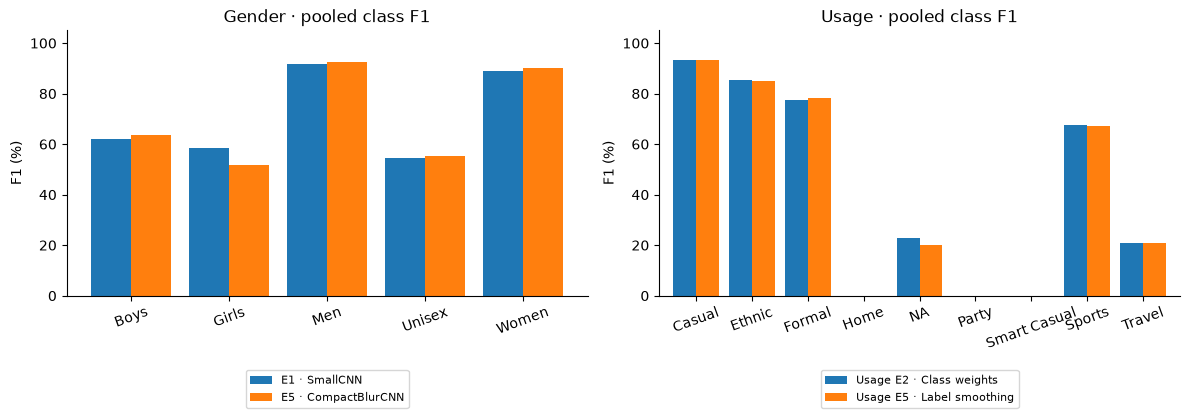

In [36]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "e58_classes.png", dpi=150, bbox_inches="tight")
plt.show()

### 14.3 Inspect learning curves from the saved epoch records

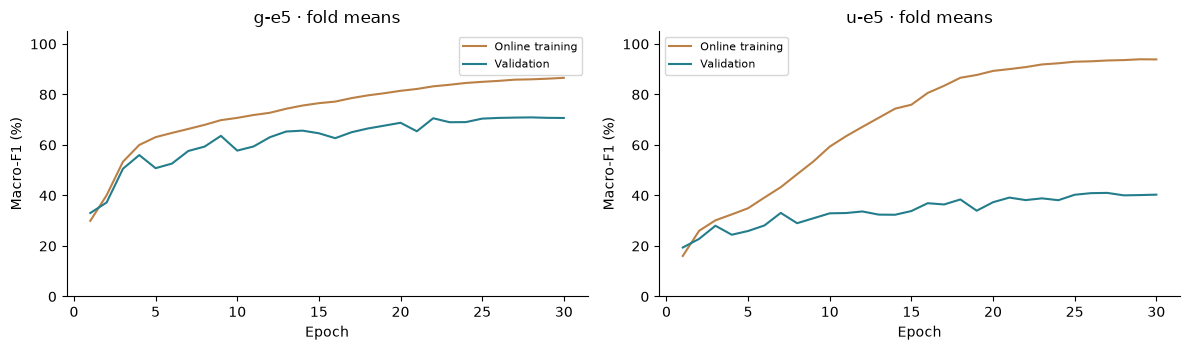

In [37]:
curve_ids = ['g-e5', 'u-e5']
fig, axes = plt.subplots(1, len(curve_ids), figsize=(12, 3.6), squeeze=False)
for ax, model_id in zip(axes[0], curve_ids):
    rows = historical_curves.loc[historical_curves.model_id.eq(model_id)]
    assert len(rows), model_id
    ax.plot(rows.epoch, rows.train_macro_f1*100, label='Online training', color='#bb8045')
    ax.plot(rows.epoch, rows.validation_macro_f1*100, label='Validation', color='#237d8b')
    ax.set(title=model_id+' · fold means', xlabel='Epoch', ylabel='Macro-F1 (%)', ylim=(0,105))
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "e58_classes_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### 14.4 Read matched corruption results for every saved fold

In [38]:
robustness_keys=['baseline', 'blur', 'usage2', 'usage5']
robustness_sources={key:evidence_lock['stages'][key]['robustness_paths'] for key in robustness_keys}
robustness_frames=[]
for key, paths in robustness_sources.items():
    stage=evidence_lock['stages'][key]
    paths = [str(p).replace('reports/task3_', 'reports/task3/', 1) for p in paths]
    rows=pd.concat([pd.read_csv(REPO_DIR/path) for path in paths],ignore_index=True)
    assert set(rows.run_id)==set(stage['run_ids'])
    rows['Stage'],rows['Target']=stage['label'],stage['target']
    robustness_frames.append(rows)
robustness_rows=pd.concat(robustness_frames,ignore_index=True)
induced=robustness_rows.groupby(['Target','Stage','corruption']).macro_f1_change.mean().mul(100)
display(induced.unstack('corruption').round(2))

corruption                         brightness_085  brightness_115  grayscale  \
Target Stage                                                                   
gender E1 · SmallCNN                       -25.62           -3.86      -4.14   
       E5 · CompactBlurCNN                 -33.45           -6.10      -7.64   
usage  Usage E2 · Class weights            -12.89           -3.16      -1.45   
       Usage E5 · Label smoothing           -9.51           -3.11      -1.01   

corruption                         jpeg_75  translation_003  
Target Stage                                                 
gender E1 · SmallCNN                 -4.16           -15.51  
       E5 · CompactBlurCNN           -1.29            -8.61  
usage  Usage E2 · Class weights      -0.07            -8.69  
       Usage E5 · Label smoothing     0.05            -7.81

### 14.5 Plot the change caused by each corruption

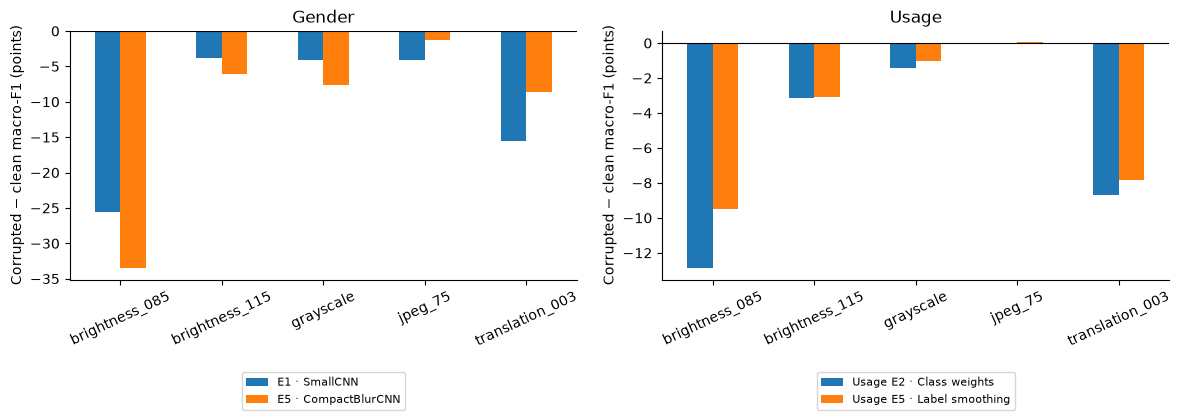

In [39]:
targets=robustness_rows.Target.unique()
fig,axes=plt.subplots(1,len(targets),figsize=(12,4.7),squeeze=False)
for ax,target in zip(axes[0],targets):
    values=induced.loc[target].unstack('Stage')
    values.plot.bar(ax=ax,rot=25)
    ax.axhline(0,color='black',linewidth=.8)
    ax.set(title=target.title(),ylabel='Corrupted − clean macro-F1 (points)',xlabel='')
    ax.legend(fontsize=8,loc='upper center',bbox_to_anchor=(.5,-.35))
fig.tight_layout()
fig.savefig(FIGURES / "e58_robustness.png", dpi=150, bbox_inches="tight")
plt.show()

**E5 result: reject both children, but keep the causal findings**


**Gender E5 — less memorisation, but no validation gain**

CompactBlurCNN did what its capacity hypothesis predicted on training behaviour. Its mean
finished-model train-validation gap was 0.1654, below the frozen 0.2371 gate and the E1 reference
of 0.2871. It used 67,069 parameters, 29.5 million MACs, 0.827 ms median batch-one latency, and
at most 0.639× E1 peak memory. NLL improved from 0.5237 to 0.3323, ECE-15 improved from 0.0756
to 0.0257, and translation loss improved from -0.1551 to -0.0861.

Those benefits did not transfer to macro-F1. It fell from 0.7118 to 0.7069. Only folds 0 and 3
improved; fold 2 fell by 0.0239. The paired 10,000-sample family bootstrap estimated -0.0049
with a 95% interval from -0.0191 to +0.0095. Girls F1 fell by 0.0667 to 0.5184, which failed its
floor and the minority-mean gate. Dark-image robustness was 0.0783 worse than E1; grayscale and
bright-image robustness also missed the 0.02 guard. The smaller model is calmer, but it did not
learn better minority-class boundaries. Gender E1 remains accepted.

**Usage E5 — confidence improved, prediction quality did not**

Label smoothing cut wrong predictions at confidence at least 0.99 from 278 to 17. On the 238
mixed-label product families, NLL improved from 1.0540 to 0.9173. The mixed-versus-consistent
NLL gap narrowed from 0.7390 to 0.5870. Hard-label overconfidence was therefore real.

The main hypothesis still failed. Macro-F1 fell from 0.4082 to 0.4049 and macro-F1 without Home
fell from 0.4592 to 0.4555. Only folds 3 and 4 improved; fold 2 fell by 0.0294. The bootstrap
interval was -0.0146 to +0.0082. Accuracy rose slightly to 0.8927 and ECE-15 improved to 0.0305,
but NLL worsened to 0.3523 because consistent-family NLL rose from 0.3151 to 0.3303. NA F1 fell
to 0.2000, Smart Casual stayed at zero, and the NA/Smart Casual/Travel mean was only 0.1356.
The mean finished-model gap was still 0.5387. Confidence was treated; class separation was not.
Usage E2 remains accepted.

**Decision**

Do not run confirmation seeds. Both children failed their primary, paired, fold, and minority
gates at seed 2753. Reject only CompactBlurCNN for Gender and epsilon-0.05 label smoothing for
Usage. Keep the findings: Gender benefits from lower capacity and anti-aliased shifts but needs
better minority separation; Usage benefits from softer confidence but needs a change that
improves rare and overlapping class boundaries.

**Scope.** The proposal and decision wording above describe this historical stage. Later named candidates test new hypotheses; they do not rewrite this stage's acceptance rule.

## 15. Keep the pooling lesson: E6 GeM and focal loss

Historical hypothesis → matched result → decision. The original gates remain unchanged after seeing the outcome.

**E6 hypotheses — isolate pooling and hard-example focus**

E5 does not justify stopping. It rules out one compact Gender architecture and one Usage
confidence treatment. The next runs return to the last accepted parent for each target and
change one smaller mechanism. No rejected E5 setting is carried forward.

**Gender E6 — fixed GeM pooling with `p=3`**

**Parent:** Gender E1 SmallCNN. **Only changed factor:** replace global average pooling with
fixed generalized-mean pooling, `GeM(x) = mean(max(x, 1e-6)^3)^(1/3)`. The power is fixed, so
the model still has 390,181 trainable parameters. Channels, convolutions, max-pooling blocks,
classifier, cross-entropy, optimiser, schedule, seed, folds, and preprocessing stay unchanged.

The evidence points to this narrow architecture test. E1 reaches strong Men and Women F1 but
misses small minority cues, while E5's much smaller network reduced memorisation and improved
calibration without improving Girls or Unisex. Global average pooling gives every final-grid
location equal weight. Fixed GeM gives stronger activated regions more weight without adding
capacity. If small discriminative regions are being washed out, minority F1 should improve.

Accept only if pooled macro-F1 is at least 0.7218, the paired family bootstrap lower bound is
above zero, at least four folds improve, the worst fold change is no worse than -0.02, and fold
SD is at most 0.0209. Also require minority mean F1 at least 0.6048, Girls at least 0.5851, and
floors Boys 0.6022, Men 0.8967, Unisex 0.5270, Women 0.8678. Keep accuracy at least 0.8668,
NLL at most 0.5437, ECE-15 at most 0.0856, final train-validation gap at most 0.2871, no
corruption more than 0.02 worse than E1, latency at most 1 ms, and memory no higher than E1.

**Usage E6 — class-balanced focal loss with `gamma=1`**

**Parent:** accepted Usage E2 SmallCNN. **Only changed factor:** replace weighted cross-entropy
with `sum(w_y * (1-p_y) * -log(p_y)) / sum(w_y)`. Keep E2's fold-only effective-number
weights (`beta=0.999`, cap 5), architecture, preprocessing, no augmentation, no smoothing, no
dropout, optimiser, schedule, seed, and folds.

E2 improved minority weighting, while E5 showed that softening every target mainly fixed
confidence and did not separate rare or overlapping classes. Focal `gamma=1` instead reduces
the contribution of already-easy examples and keeps attention on hard examples. This tests the
remaining loss hypothesis without repeating the failed E4 architecture change.

Accept only if pooled macro-F1 is at least 0.4182, macro-F1 without Home is at least 0.4692,
the paired family bootstrap lower bound is above zero, at least four folds improve, the worst
fold change is no worse than -0.02, and fold SD is at most 0.0303. Require accuracy at least
0.8815; class floors Casual 0.9118, Ethnic 0.8340, Formal 0.7559, NA 0.2099, Sports 0.6551,
Travel 0.1869; minority mean at least 0.1556; and non-zero Smart Casual recall. Keep NLL at
most 0.3628, ECE-15 at most 0.0431, final train-validation gap at most 0.5387, wrong predictions
at confidence at least 0.99 no more than 278, mixed-family NLL at most 1.0740, consistent-family
NLL at most 0.3351, and no corruption more than 0.02 worse than E2. Home and Party remain
report-only because their support is too small for a stable acceptance gate.

### 15.1 Recompute the comparison from registered confusion counts

In [40]:
selected_stages = ['baseline', 'gem', 'usage2', 'usage6']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
E1 · SmallCNN,gender,"[0, 1, 2, 3, 4]",Original,32773,71.18,87.68
E6 · GeM pooling,gender,"[0, 1, 2, 3, 4]",Original,32773,73.35,89.32
Usage E2 · Class weights,usage,"[0, 1, 2, 3, 4]",Original,32772,40.82,89.15
Usage E6 · Focal loss,usage,"[0, 1, 2, 3, 4]",Original,32772,40.94,88.82


### 15.2 Plot class gains and losses on the same folds

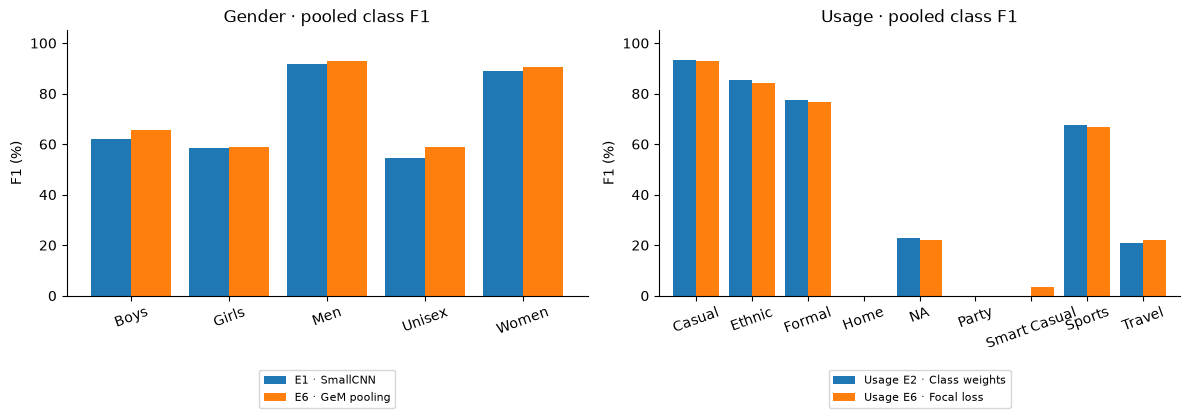

In [41]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "e64_classes.png", dpi=150, bbox_inches="tight")
plt.show()

### 15.3 Inspect learning curves from the saved epoch records

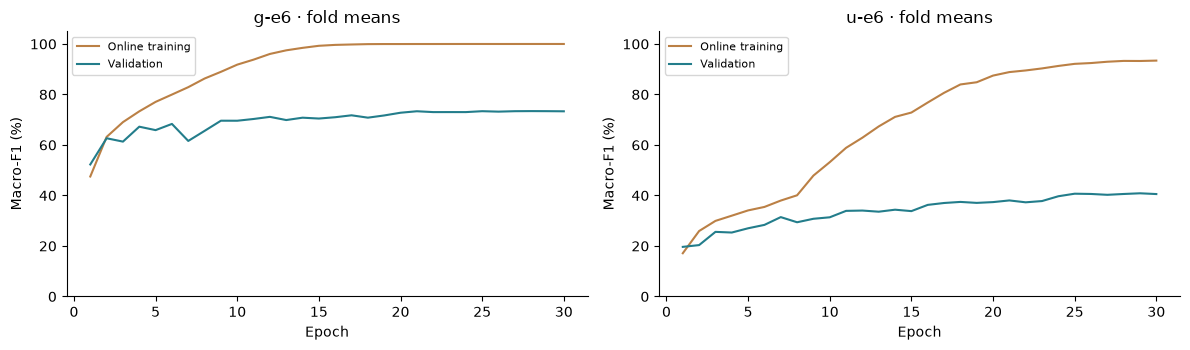

In [42]:
curve_ids = ['g-e6', 'u-e6']
fig, axes = plt.subplots(1, len(curve_ids), figsize=(12, 3.6), squeeze=False)
for ax, model_id in zip(axes[0], curve_ids):
    rows = historical_curves.loc[historical_curves.model_id.eq(model_id)]
    assert len(rows), model_id
    ax.plot(rows.epoch, rows.train_macro_f1*100, label='Online training', color='#bb8045')
    ax.plot(rows.epoch, rows.validation_macro_f1*100, label='Validation', color='#237d8b')
    ax.set(title=model_id+' · fold means', xlabel='Epoch', ylabel='Macro-F1 (%)', ylim=(0,105))
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "e64_classes_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### 15.4 Read matched corruption results for every saved fold

In [43]:
robustness_keys=['baseline', 'gem', 'usage2', 'usage6']
robustness_sources={key:evidence_lock['stages'][key]['robustness_paths'] for key in robustness_keys}
robustness_frames=[]
for key, paths in robustness_sources.items():
    stage=evidence_lock['stages'][key]
    paths = [str(p).replace('reports/task3_', 'reports/task3/', 1) for p in paths]
    rows=pd.concat([pd.read_csv(REPO_DIR/path) for path in paths],ignore_index=True)
    assert set(rows.run_id)==set(stage['run_ids'])
    rows['Stage'],rows['Target']=stage['label'],stage['target']
    robustness_frames.append(rows)
robustness_rows=pd.concat(robustness_frames,ignore_index=True)
induced=robustness_rows.groupby(['Target','Stage','corruption']).macro_f1_change.mean().mul(100)
display(induced.unstack('corruption').round(2))

corruption                       brightness_085  brightness_115  grayscale  \
Target Stage                                                                 
gender E1 · SmallCNN                     -25.62           -3.86      -4.14   
       E6 · GeM pooling                  -20.42           -3.69      -3.66   
usage  Usage E2 · Class weights          -12.89           -3.16      -1.45   
       Usage E6 · Focal loss             -16.09           -3.64      -0.83   

corruption                       jpeg_75  translation_003  
Target Stage                                               
gender E1 · SmallCNN               -4.16           -15.51  
       E6 · GeM pooling            -2.95           -14.65  
usage  Usage E2 · Class weights    -0.07            -8.69  
       Usage E6 · Focal loss       -1.17            -8.09

### 15.5 Plot the change caused by each corruption

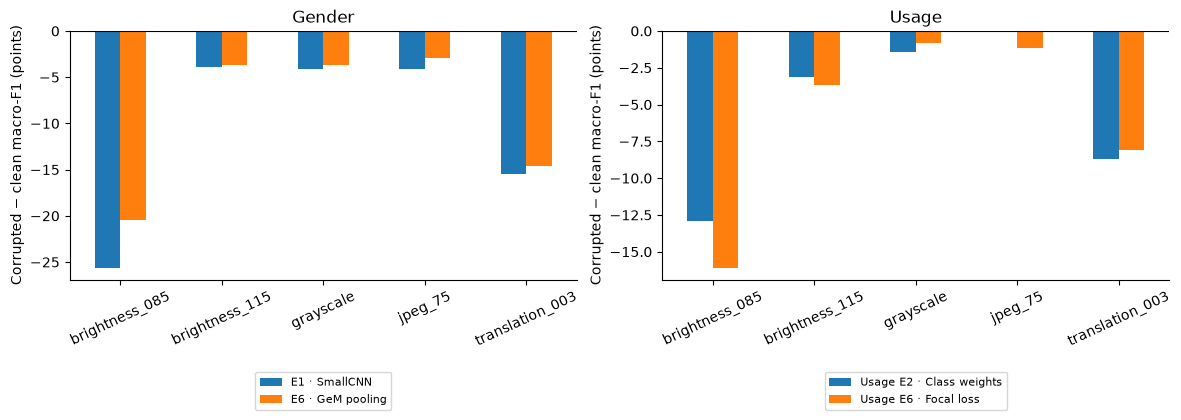

In [44]:
targets=robustness_rows.Target.unique()
fig,axes=plt.subplots(1,len(targets),figsize=(12,4.7),squeeze=False)
for ax,target in zip(axes[0],targets):
    values=induced.loc[target].unstack('Stage')
    values.plot.bar(ax=ax,rot=25)
    ax.axhline(0,color='black',linewidth=.8)
    ax.set(title=target.title(),ylabel='Corrupted − clean macro-F1 (points)',xlabel='')
    ax.legend(fontsize=8,loc='upper center',bbox_to_anchor=(.5,-.35))
fig.tight_layout()
fig.savefig(FIGURES / "e64_robustness.png", dpi=150, bbox_inches="tight")
plt.show()

**E6 result: Gender improves; Usage focal loss is rejected**


**Gender E6 — a real gain, but memorisation remains**

GeM improved four of five folds and every class. The largest F1 gains over E1 were Unisex
(+0.0424) and Boys (+0.0338). Accuracy rose from 0.8768 to 0.8932, NLL fell from 0.5237 to
0.4325, and all five corruption scores improved. The product-family bootstrap lower bound is
above zero, so the gain is not explained by treating related images as independent rows.

This does not fix overfitting. Finished training macro-F1 is still 0.99995 and the mean
train-validation gap is 0.2666. Unisex recall is only 0.5181; 514 Unisex rows become Men and
288 become Women. Mixed-label-family NLL worsened from 1.5753 to 1.6275 even while
consistent-family NLL improved. GeM helps visual summarisation, but it cannot resolve conflicting
or visually unclear labels.

One frozen resource gate failed: peak memory was 476.0 MB versus at most 450.5 MB for E1, about
5.7% higher. We do not rewrite that gate after seeing the result. Therefore E6 is recorded as
the strongest completed Gender performance benchmark, not a fully accepted parent. E1 remains
the clean architecture parent for the next one-factor test, while E7 must beat E6 to become a
finalist.

**Usage E6 — confidence improved, class separation did not**

Focal loss reduced wrong predictions at confidence at least 0.99 from 278 to 21. Mixed-label
family NLL improved from 1.0540 to 0.8800. It also made Smart Casual recall non-zero and raised
Travel F1 from 0.2069 to 0.2222.

Those changes did not produce a reliable prediction gain. Pooled macro-F1 rose only 0.0012,
macro-F1 without Home rose only 0.0014, and the paired interval crosses zero. Only three folds
improved over E2. E6 is also below the best completed Usage score, E3 at 0.4161. Casual, Ethnic,
Formal, NA, and Sports F1 all fell relative to E2. Dark-image robustness was 0.0320 worse than
E2, breaking the frozen robustness guard. Home and Party remain at zero F1. Focal loss is
rejected and Usage E2 remains the accepted parent.

**Scope.** The proposal and decision wording above describe this historical stage. Later named candidates test new hypotheses; they do not rewrite this stage's acceptance rule.

## 16. E7: high-resolution features and ConvNeXt blocks

Historical hypothesis → matched result → decision. The original gates remain unchanged after seeing the outcome.

**E7 hypotheses — change the feature representation**

E6 closes the remaining small-mechanism tests. Gender GeM supports the view that how spatial evidence is
summarised matters, but the same SmallCNN still memorises the training folds. Usage focal loss
supports the view that confidence can improve without better class boundaries. The next tests therefore
change the backbone itself. No E6 loss or pooling setting is stacked into E7.
Run Usage TinyConvNeXt-18 first because Usage is still the weaker target. Run Gender
TinyHRNet-20 second if time allows.

**Gender E7 — TinyHRNet-20**

**Hypothesis.** Gender cues need fine local detail and whole-item context at the same time.
A small high-resolution network should improve minority boundaries because it keeps a detailed
branch alive while repeatedly exchanging features with lower-resolution context branches. This
tests a different representation, not another width, dropout, pooling, or loss adjustment.

The scratch model is fixed as:

1. stem: `3x3, 3->20, stride 1`, then `3x3, 20->20, stride 2`;
2. two residual blocks at `20x40x30`;
3. parallel `20x40x30` and `40x20x15` branches with two exchange units;
4. add an `80x10x8` branch, then one block per branch and one three-way exchange;
5. global-average-pool all three branches, concatenate 140 values, and use `Linear 140->5`.

Use BatchNorm and ReLU, 374,445 parameters, about 104.1 million MACs, ordinary Gender E1
cross-entropy, and no GeM, dropout, extra augmentation, attention, or pretrained weights. This
is derived from the multi-resolution idea in the
[HRNet paper](https://openaccess.thecvf.com/content_CVPR_2019/html/Sun_Deep_High-Resolution_Representation_Learning_for_Human_Pose_Estimation_CVPR_2019_paper.html)
and the lightweight design evidence in
[Lite-HRNet](https://openaccess.thecvf.com/content/CVPR2021/html/Yu_Lite-HRNet_A_Lightweight_High-Resolution_Network_CVPR_2021_paper.html).

Freeze two decisions before training:

- The architecture hypothesis must beat E1 with a paired family lower bound above zero, improve
  at least four E1 folds, and lose no E1 fold by more than 0.02.
- A finalist must also reach pooled macro-F1 at least 0.7435, which is E6 plus 0.0100; beat E6
  with a paired lower bound above zero; keep mean Boys/Girls/Unisex F1 at least 0.6013, Men
  F1 at least 0.9188, Women F1 at least 0.8950, and fold SD at most 0.0209; keep the mean
  train-validation gap at most 0.2666, NLL at most 0.4525, ECE-15 at most 0.0842, and
  mixed-family NLL at most 1.6475; lose no corruption by more than 0.02; and stay within
  410,000 parameters, 110 million MACs, 720 seconds per fold, and 1.25 GiB peak memory.
  The 1.25 GiB limit is E7's new architecture budget; it does not erase E6's failed frozen
  memory gate.

**Usage E7 — TinyConvNeXt-18**

**Hypothesis.** Usage errors are dominated by broad garment shape, texture, and context that the
old three-block SmallCNN does not separate. A size-matched ConvNeXt-style model should improve
supported boundaries using large depthwise kernels and hierarchical features. This tests
representation while keeping E2's successful class weighting unchanged.

The scratch model is fixed as:

1. widths `[18, 36, 72, 144]` and depths `[1, 1, 3, 1]`;
2. `3x3` stride-1 stem and learned `2x2` stride-2 transitions;
3. each block uses a `7x7` depthwise convolution, channels-last LayerNorm, `4x` pointwise
   expansion, GELU, pointwise contraction, layer scale `1e-6`, and a residual connection;
4. global average pooling, LayerNorm, and `Linear 144->9`.

Use 384,345 parameters, about 95.3 million MACs, Usage E2 effective-number weights, and no focal
loss, smoothing, dropout, attention, extra augmentation, or pretrained weights. This follows the
large-kernel modern ConvNet design in the
[ConvNeXt paper](https://openaccess.thecvf.com/content/CVPR2022/html/Liu_A_ConvNet_for_the_2020s_CVPR_2022_paper).

Freeze two decisions before training:

- The architecture hypothesis must beat E2 with a paired family lower bound above zero, improve
  at least four E2 folds, and lose no E2 fold by more than 0.02.
- A finalist must reach pooled macro-F1 at least 0.4262, macro-F1 without Home at least 0.4782,
  and paired lower bounds above zero against both E2 and the best completed Usage model E3.
  Keep fold SD at most 0.0303 and E2-minus-0.01 class floors: Casual 0.9218, Ethnic 0.8440,
  Formal 0.7659, NA 0.2199, Sports 0.6651, and Travel 0.1969. Also require non-zero Smart
  Casual recall, no corruption more than 0.02 worse than E2, at most 410,000 parameters,
  105 million MACs, 720 seconds per fold, and 1.25 GiB peak memory. Home and Party remain
  report-only because one and twelve rows cannot support stable gates.

A plain Vision Transformer is not opened: training from scratch on this dataset is a poor match
for its data needs. An ArticleType-assisted multi-task head is reserved as a later single-factor
hypothesis only if TinyConvNeXt clearly beats E2 but misses the finalist gate mainly on minority
classes. Do not automatically combine TinyHRNet with GeM: test that single factor later only if
plain TinyHRNet beats E1 and approaches E6. E7 trains each target separately and still uses
only the canonical five folds.

### 16.1 Recompute the comparison from registered confusion counts

In [45]:
selected_stages = ['baseline', 'hrnet', 'usage2', 'usage7']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
E1 · SmallCNN,gender,"[0, 1, 2, 3, 4]",Original,32773,71.18,87.68
E7 · TinyHRNet,gender,"[0, 1, 2, 3, 4]",Original,32773,70.25,87.35
Usage E2 · Class weights,usage,"[0, 1, 2, 3, 4]",Original,32772,40.82,89.15
Usage E7 · TinyConvNeXt,usage,"[0, 1, 2, 3, 4]",Original,32772,34.51,85.22


### 16.2 Plot class gains and losses on the same folds

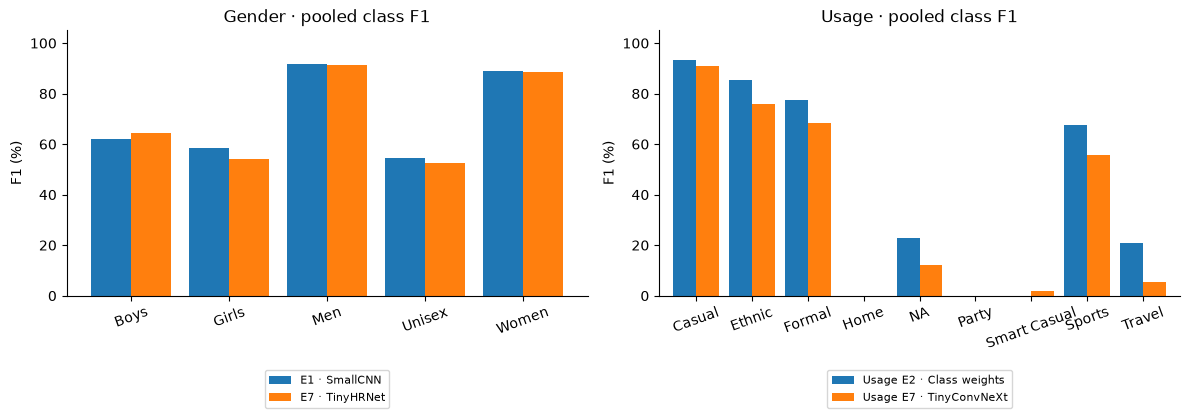

In [46]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "e72_classes.png", dpi=150, bbox_inches="tight")
plt.show()

### 16.3 Inspect learning curves from the saved epoch records

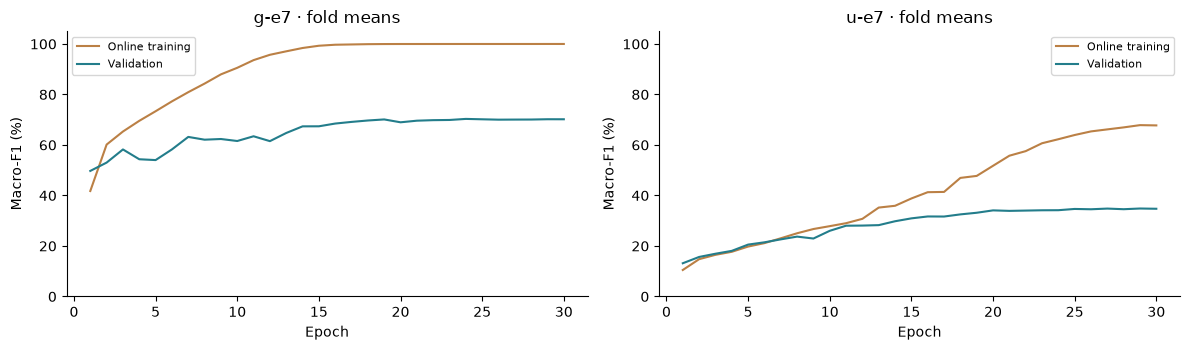

In [47]:
curve_ids = ['g-e7', 'u-e7']
fig, axes = plt.subplots(1, len(curve_ids), figsize=(12, 3.6), squeeze=False)
for ax, model_id in zip(axes[0], curve_ids):
    rows = historical_curves.loc[historical_curves.model_id.eq(model_id)]
    assert len(rows), model_id
    ax.plot(rows.epoch, rows.train_macro_f1*100, label='Online training', color='#bb8045')
    ax.plot(rows.epoch, rows.validation_macro_f1*100, label='Validation', color='#237d8b')
    ax.set(title=model_id+' · fold means', xlabel='Epoch', ylabel='Macro-F1 (%)', ylim=(0,105))
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "e72_classes_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### 16.4 Read matched corruption results for every saved fold

In [48]:
robustness_keys=['baseline', 'hrnet', 'usage2', 'usage7']
robustness_sources={key:evidence_lock['stages'][key]['robustness_paths'] for key in robustness_keys}
robustness_frames=[]
for key, paths in robustness_sources.items():
    stage=evidence_lock['stages'][key]
    paths = [str(p).replace('reports/task3_', 'reports/task3/', 1) for p in paths]
    rows=pd.concat([pd.read_csv(REPO_DIR/path) for path in paths],ignore_index=True)
    assert set(rows.run_id)==set(stage['run_ids'])
    rows['Stage'],rows['Target']=stage['label'],stage['target']
    robustness_frames.append(rows)
robustness_rows=pd.concat(robustness_frames,ignore_index=True)
induced=robustness_rows.groupby(['Target','Stage','corruption']).macro_f1_change.mean().mul(100)
display(induced.unstack('corruption').round(2))

corruption                       brightness_085  brightness_115  grayscale  \
Target Stage                                                                 
gender E1 · SmallCNN                     -25.62           -3.86      -4.14   
       E7 · TinyHRNet                    -27.64           -5.01      -3.06   
usage  Usage E2 · Class weights          -12.89           -3.16      -1.45   
       Usage E7 · TinyConvNeXt           -28.58           -1.81      -3.99   

corruption                       jpeg_75  translation_003  
Target Stage                                               
gender E1 · SmallCNN               -4.16           -15.51  
       E7 · TinyHRNet              -0.87           -19.17  
usage  Usage E2 · Class weights    -0.07            -8.69  
       Usage E7 · TinyConvNeXt     -0.11           -11.96

### 16.5 Plot the change caused by each corruption

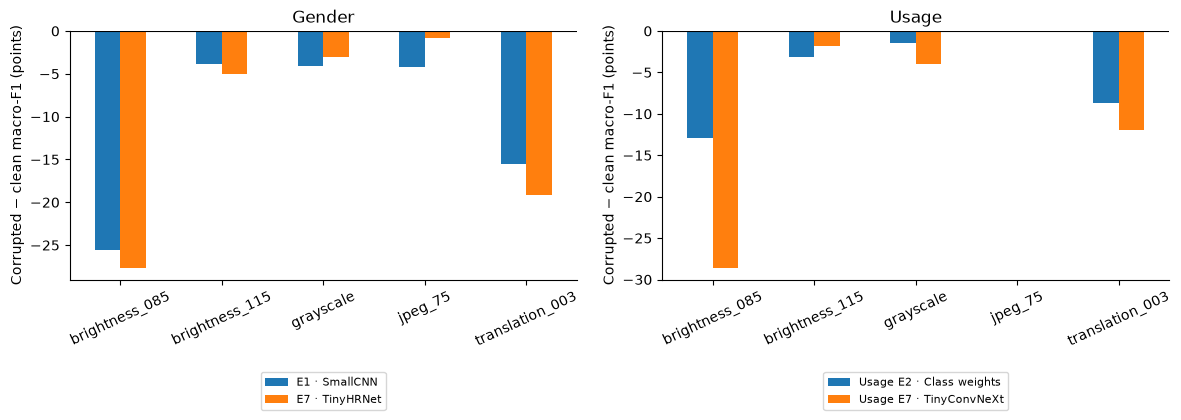

In [49]:
targets=robustness_rows.Target.unique()
fig,axes=plt.subplots(1,len(targets),figsize=(12,4.7),squeeze=False)
for ax,target in zip(axes[0],targets):
    values=induced.loc[target].unstack('Stage')
    values.plot.bar(ax=ax,rot=25)
    ax.axhline(0,color='black',linewidth=.8)
    ax.set(title=target.title(),ylabel='Corrupted − clean macro-F1 (points)',xlabel='')
    ax.legend(fontsize=8,loc='upper center',bbox_to_anchor=(.5,-.35))
fig.tight_layout()
fig.savefig(FIGURES / "e72_robustness.png", dpi=150, bbox_inches="tight")
plt.show()

**E7 result: reject both scratch architectures**


**Gender E7 — high-resolution features do not stop memorisation**

TinyHRNet-20 improved Boys F1 by 0.0233 over E1, but every other class fell. Girls fell by
0.0423 and Unisex by 0.0214. The Boys/Girls/Unisex mean was 0.5713, below the frozen 0.6013
gate. The taxonomy check also remains difficult: 118 Boys rows became Men, 76 Men rows became
Boys, 155 Girls rows became Women, and 83 Women rows became Girls.

The model reached a finished training macro-F1 of 1.0000 in every fold. Its mean finished-model
gap was 0.2982, worse than both E1 and E6. Only two of five folds improved over E1, the worst
fold lost 0.0409, and fold SD was 0.0223. NLL worsened to 0.7026, ECE-15 to 0.0940, and
high-confidence errors to 1,451. Its paired interval against E6 was fully negative:
-0.0449 to -0.0168. Translation robustness was 0.0366 worse than E1. The model fits inside its
new cost budget, but the representation and generalisation gates fail. Reject TinyHRNet-20.

**Usage E7 — the architecture underfits and costs more**

TinyConvNeXt-18 scored 0.3451 pooled macro-F1 and 0.3882 without Home. It lost on all five folds
against E2. The paired intervals against both E2 and E3 are fully negative. Every supported
class floor failed: Casual fell to 0.9094, Ethnic to 0.7599, Formal to 0.6828, NA to 0.1222,
Sports to 0.5578, and Travel to 0.0561. Smart Casual recall is non-zero, but only one of 47
rows is correct.

Unlike the earlier SmallCNNs, its finished train macro-F1 stayed between 0.5813 and 0.7387.
The 0.3364 mean train-validation gap is smaller because the model did not fit the training folds
well, not because it generalised better. ECE-15 improved to 0.0122 because predictions became
less confident, while NLL worsened to 0.4473 and errors rose to 4,845. Dark-image robustness
was 0.1570 worse than E2. Each fold took about 879 seconds and used 1.441 GiB, breaking the
720-second and 1.25-GiB gates. Reject TinyConvNeXt-18.

**Decision**

E7 is useful negative evidence: changing the backbone alone is not enough. Keep Gender E6 as the
strongest completed performance benchmark, while E1 remains the clean parent because E6 missed
its frozen memory guard. Keep Usage E2 as the accepted parent; E3 remains the best completed
Usage score but did not pass its paired acceptance gate. Do not combine either rejected E7
architecture with earlier tweaks.

**Scope.** The proposal and decision wording above describe this historical stage. Later named candidates test new hypotheses; they do not rewrite this stage's acceptance rule.

## 17. E8: early stopping and translation

Historical hypothesis → matched result → decision. The original gates remain unchanged after seeing the outcome.

**E8 hypotheses — checkpoint selection and small translation**

E7 closes the backbone-replacement lanes, but it does not make the two remaining problems identical. Gender still fits its training folds almost perfectly and then loses validation quality. Usage TinyConvNeXt did not fit its training folds well enough, while the accepted E2 SmallCNN still shows a large train-validation gap. The next tests therefore return to the strongest relevant SmallCNN parent and change one training control for each target.

**Evidence that fixes the direction**

For Gender, 1,426 images were wrong in all six locally available OOF model sets, and 949 received the same wrong label every time. Persistent errors concentrate in Unisex and Girls and in rows whose Gender disagrees with the fold-safe ArticleType majority. Some catalogue images therefore contain weak or conflicting audience evidence that preprocessing cannot create. However, E6 also shows an avoidable training effect: every fold reached its best validation macro-F1 before epoch 30. The five best epochs were 24, 21, 25, 27, and 17; keeping epoch 30 lost 0.0048 to 0.0137 macro-F1 per fold. This opens one direct checkpoint-selection test without changing the architecture or image content.

For Usage, E2 is wrong on 47.8% of rows whose label disagrees with the normal Usage for that ArticleType, compared with 6.6% elsewhere. In 96.8% of those wrong disagreement cases, E2 predicts the ArticleType's usual Usage. The previously proposed ArticleType auxiliary head is therefore withdrawn: it risks strengthening the exact shortcut already causing many errors. Across E2-E7, 1,534 Usage rows remain wrong in every model, which also supports a later manual label audit rather than automatic relabelling.

Keep native `80x60` RGB, the full frame, and aspect ratio. Do not add background removal, grayscale, random crops, strong brightness changes, blur, MixUp, CutMix, or Random Erasing. These operations can remove the small product, colour, person, pose, or scene clues needed by these targets. Only a tiny translation is opened because translation is already a measured weakness and it preserves the label and almost all image content.

**Prospective memory-budget correction**

The historical gates remain recorded exactly as written before those runs; E6 is not retroactively relabelled. Future E8 runs use an absolute **2.0 GiB PyTorch peak-allocation ceiling per fold** instead of a parent-relative limit or the former 0.55 GiB limit. `torch.cuda.max_memory_allocated()` is still recorded and parent-child memory changes remain part of the cost report, but memory alone fails a future run only above 2.0 GiB. This is a feasibility guard, not a model-quality score. It sits above the largest observed Task 3 run, Usage E7 at 1.441 GiB, and avoids rejecting a useful model because allocator or runtime overhead moved a few percent. Gender E6 used only 0.443 GiB and the accepted SmallCNN parents use about 0.419 GiB.

**Gender E8G — E6 GeM with best-checkpoint early stopping**

**Hypothesis.** E6 learns useful Gender features, but the final-epoch rule keeps training after validation quality peaks. Selecting the best validation checkpoint should retain E6's representation gain while reducing avoidable late-epoch overfitting. It cannot solve images with missing or ambiguous audience evidence, so persistent-error analysis remains a required limitation.

**Parent:** the five Gender E6 GeM `p=3` folds. The only changed factor is the checkpoint policy. Train for at most 30 epochs. Do not stop before epoch 15. Save a checkpoint whenever validation macro-F1 improves by at least 0.001; stop after 10 consecutive epochs without such an improvement; restore the best saved checkpoint for clean training evaluation, OOF prediction, robustness evaluation, and registration. Keep the E6 architecture, ordinary cross-entropy, input, normalisation, optimiser, schedule, batch size, seed, and folds unchanged. No new augmentation is added.

Frozen Gender gates at seed 2753:

- pooled OOF macro-F1 at least 0.7435 and paired family-bootstrap lower 95% bound above zero versus E6 final-epoch OOF;
- at least four of five folds improve over their E6 final checkpoints, and no fold loses more than 0.005;
- mean clean train-validation macro-F1 gap at most 0.2466, which is at least 0.020 below E6;
- mean Boys/Girls/Unisex F1 at least 0.6013, Men F1 at least 0.9188, and Women F1 at least 0.8950;
- NLL at most 0.4525, ECE-15 at most 0.0842, and no corruption more than 0.02 worse than E6;
- the same 390,181 parameters and architecture MACs as E6, median fold time at most 720 seconds, and peak allocation at most 2.0 GiB.

**Usage E8U — E2 plus two-pixel random translation**

**Hypothesis.** E2 may memorise exact catalogue alignment. A very small translation should teach position tolerance without deleting product or context clues. If alignment sensitivity is a real cause, translation robustness and clean OOF macro-F1 should improve together. A smaller train-validation gap by itself is not success.

**Parent:** the five accepted Usage E2 folds. The only changed factor is training augmentation. After EXIF correction and RGB conversion, apply translation with probability 0.5. Sample integer `dx` and `dy` independently and uniformly from `[-2, -1, 0, 1, 2]`; keep the image at `80x60`, use bilinear interpolation, and fill exposed pixels with white. Validation, robustness inputs, and inference remain unchanged. Keep E2 SmallCNN, effective-number weights (`beta=0.999`, cap 5), normalisation, optimiser, schedule, 30 epochs, final checkpoint, seed, and folds unchanged. Add a clean training-set evaluation pass because online training scores now see shifted images. Do not add the ArticleType head.

Frozen Usage gates at seed 2753:

- pooled macro-F1 at least 0.4262 and macro-F1 without Home at least 0.4782;
- paired product-family bootstrap lower 95% bound above zero against both E2 and E3;
- at least four of five folds improve over E2, no fold loses more than 0.02, and fold SD is at most 0.0303;
- mean clean train-validation gap at most 0.4842, at least 0.05 below E2;
- translation corruption change at least -0.0569, recovering at least 0.03 from E2, and no other corruption more than 0.02 worse;
- accuracy at least 0.8815, NLL at most 0.3628, and ECE-15 at most 0.0431;
- class floors Casual 0.9218, Ethnic 0.8440, Formal 0.7659, NA 0.2199, Sports 0.6651, and Travel 0.1969, plus non-zero Smart Casual recall;
- median fold time at most 600 seconds and peak allocation at most 2.0 GiB.

`task3_training/early_stopping_translation_e8_experiments.ipynb` resolves the completed E6/E2 parent folds from Drive, verifies both one-factor contracts without an optimiser step, trains Gender E8G and Usage E8U, and persists every fold plus both pooled aggregates.

**Stop rule**

Run each target once at seed 2753 and judge it only against its own parent and frozen gates. Do not stack early stopping into Usage or translation into Gender. A failed target stops its own experiment lane and moves to error and label-quality analysis. Only a complete gate pass opens confirmation seeds 2754 and 2755; a finalist must improve at all three seeds with mean macro-F1 gain at least 0.010.

### 17.1 Recompute the comparison from registered confusion counts

In [50]:
selected_stages = ['gem', 'early', 'usage2', 'usage8']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
E6 · GeM pooling,gender,"[0, 1, 2, 3, 4]",Original,32773,73.35,89.32
E8 · Early stopping,gender,"[0, 1, 2, 3, 4]",Original,32773,74.12,89.12
Usage E2 · Class weights,usage,"[0, 1, 2, 3, 4]",Original,32772,40.82,89.15
Usage E8 · Translation,usage,"[0, 1, 2, 3, 4]",Original,32772,41.94,88.85


### 17.2 Plot class gains and losses on the same folds

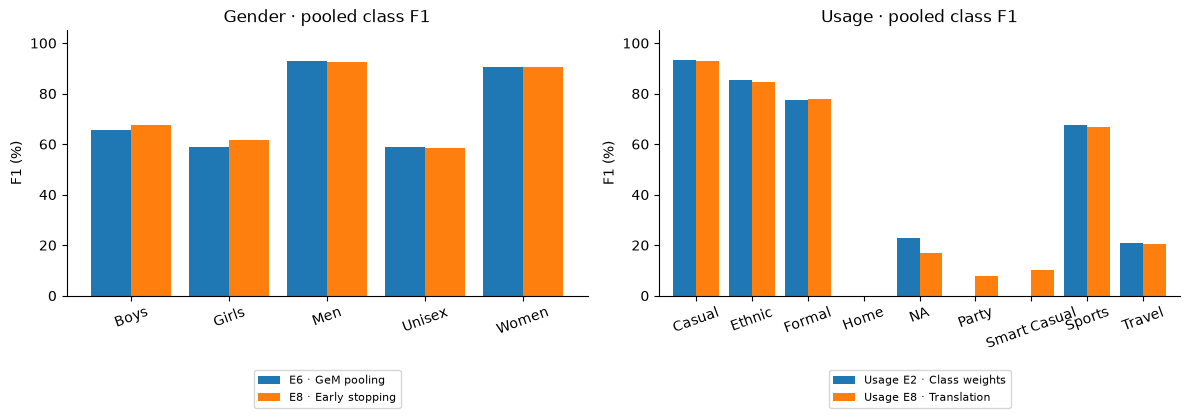

In [51]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "e77_classes.png", dpi=150, bbox_inches="tight")
plt.show()

### 17.3 Inspect learning curves from the saved epoch records

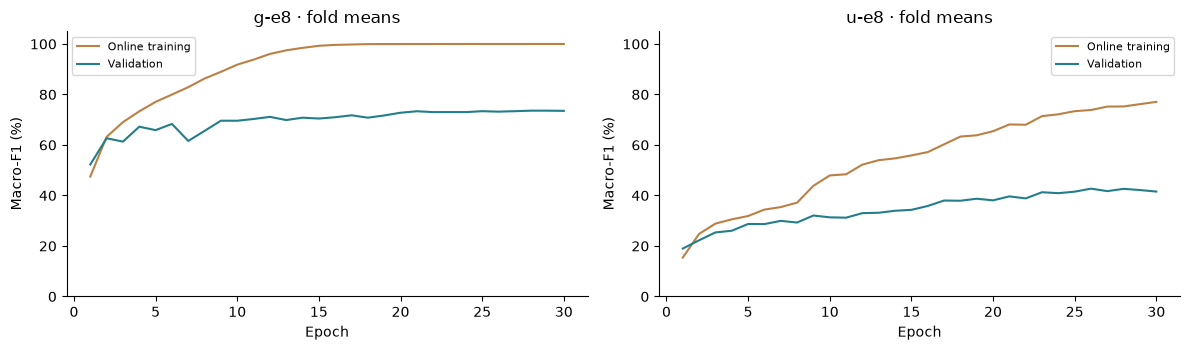

In [52]:
curve_ids = ['g-e8', 'u-e8']
fig, axes = plt.subplots(1, len(curve_ids), figsize=(12, 3.6), squeeze=False)
for ax, model_id in zip(axes[0], curve_ids):
    rows = historical_curves.loc[historical_curves.model_id.eq(model_id)]
    assert len(rows), model_id
    ax.plot(rows.epoch, rows.train_macro_f1*100, label='Online training', color='#bb8045')
    ax.plot(rows.epoch, rows.validation_macro_f1*100, label='Validation', color='#237d8b')
    ax.set(title=model_id+' · fold means', xlabel='Epoch', ylabel='Macro-F1 (%)', ylim=(0,105))
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "e77_classes_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### 17.4 Read matched corruption results for every saved fold

In [53]:
robustness_keys=['gem', 'early', 'usage2', 'usage8']
robustness_sources={key:evidence_lock['stages'][key]['robustness_paths'] for key in robustness_keys}
robustness_frames=[]
for key, paths in robustness_sources.items():
    stage=evidence_lock['stages'][key]
    paths = [str(p).replace('reports/task3_', 'reports/task3/', 1) for p in paths]
    rows=pd.concat([pd.read_csv(REPO_DIR/path) for path in paths],ignore_index=True)
    assert set(rows.run_id)==set(stage['run_ids'])
    rows['Stage'],rows['Target']=stage['label'],stage['target']
    robustness_frames.append(rows)
robustness_rows=pd.concat(robustness_frames,ignore_index=True)
induced=robustness_rows.groupby(['Target','Stage','corruption']).macro_f1_change.mean().mul(100)
display(induced.unstack('corruption').round(2))

corruption                       brightness_085  brightness_115  grayscale  \
Target Stage                                                                 
gender E6 · GeM pooling                  -20.42           -3.69      -3.66   
       E8 · Early stopping               -21.13           -4.44      -3.66   
usage  Usage E2 · Class weights          -12.89           -3.16      -1.45   
       Usage E8 · Translation            -16.19           -4.22      -2.08   

corruption                       jpeg_75  translation_003  
Target Stage                                               
gender E6 · GeM pooling            -2.95           -14.65  
       E8 · Early stopping         -2.50           -14.90  
usage  Usage E2 · Class weights    -0.07            -8.69  
       Usage E8 · Translation      -0.19            -2.69

### 17.5 Plot the change caused by each corruption

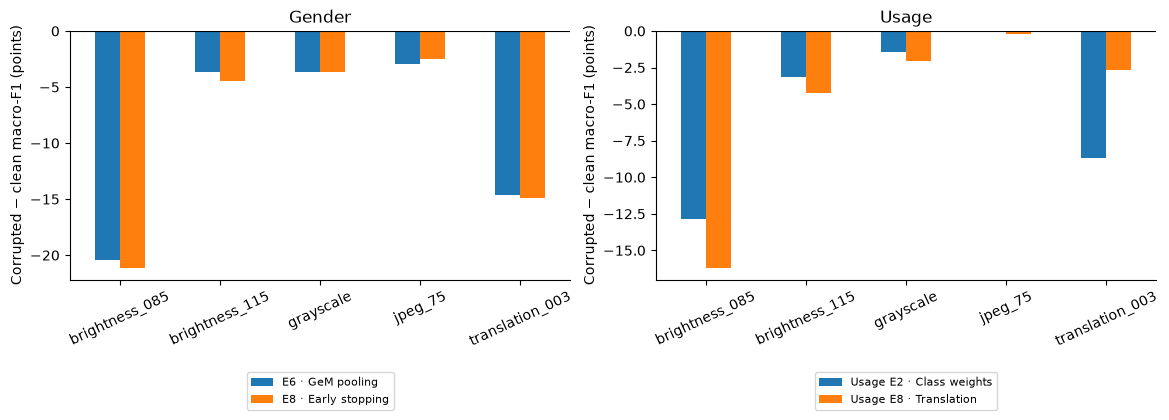

In [54]:
targets=robustness_rows.Target.unique()
fig,axes=plt.subplots(1,len(targets),figsize=(12,4.7),squeeze=False)
for ax,target in zip(axes[0],targets):
    values=induced.loc[target].unstack('Stage')
    values.plot.bar(ax=ax,rot=25)
    ax.axhline(0,color='black',linewidth=.8)
    ax.set(title=target.title(),ylabel='Corrupted − clean macro-F1 (points)',xlabel='')
    ax.legend(fontsize=8,loc='upper center',bbox_to_anchor=(.5,-.35))
fig.tight_layout()
fig.savefig(FIGURES / "e77_robustness.png", dpi=150, bbox_inches="tight")
plt.show()

**E8 result: useful improvements, but neither child clears every frozen gate**


**Gender E8 — checkpoint choice helps, but does not cure overfitting**

Restoring the best checkpoint improved all five folds over E6. The family bootstrap is fully positive, so the +0.0077 gain is reliable for this seed. Boys F1 rose by 0.0182 and Girls by 0.0279. NLL improved from 0.4325 to 0.4145, ECE-15 from 0.0642 to 0.0591, and high-confidence errors fell from 726 to 595. All robustness and cost guards passed.

The frozen finalist score was 0.7435, so 0.7412 misses it by 0.0023. More importantly, clean training macro-F1 is still about 0.998-1.000 in every fold. The mean train-validation gap only fell from 0.2666 to 0.2582, not to 0.2466. Four folds trained through epoch 30 and restored epochs 20-27; only fold 4 stopped early and restored epoch 17. Checkpoint choice removes a small avoidable loss, but the model still memorises training families. Unisex F1 also fell by 0.0046. E8 is the strongest Gender benchmark, but it is not eligible for confirmation seeds under the frozen all-gates rule.

**Usage E8 — translation fixes alignment sensitivity, not the class problem**

Translation improved four of five folds, pooled macro-F1 by 0.0112, macro-F1 without Home by 0.0126, NLL from 0.3428 to 0.3292, and ECE-15 from 0.0331 to 0.0079. The clean train-validation gap fell to 0.3750. Translation corruption improved by 0.0600 to only -0.0269, and wrong predictions at confidence at least 0.99 fell from 278 to 64. Exact catalogue alignment and overconfident memorisation were real problems.

The clean gain is not reliable across product families: the paired interval against E2 crosses zero, and the interval against E3 is -0.0239 to +0.0318. The main score misses 0.4262, and the no-Home score misses 0.4782. NA F1 fell from 0.2299 to 0.1690. The apparent rare-tail gain includes only one correct Party row and six correct Smart Casual rows. Fold 0 supplies most of the gain, fold 4 regresses, and dark-image robustness is 0.0330 worse than E2. Translation taught position tolerance, but it did not create stable rare-class boundaries or resolve conflicting labels.

**Decision and remaining problem**

Do not run confirmation seeds and do not stack E8 automatically. Keep E8 Gender as the strongest observed score but retain the frozen rejection. Keep E2 as the accepted Usage parent and E3 as the strongest earlier Usage score. The next hypotheses must target the measured causes: family-level memorisation and weak or ambiguous audience evidence for Gender; extreme support imbalance, conflicting labels, and ArticleType shortcut errors for Usage. A new architecture is justified only if it directly attacks one of those causes and is trained from scratch on the fixed folds.

**Scope.** The proposal and decision wording above describe this historical stage. Later named candidates test new hypotheses; they do not rewrite this stage's acceptance rule.

## 18. E9: remove semantic conflicts and balance exceptions

Historical hypothesis → matched result → decision. The original gates remain unchanged after seeing the outcome.

**E9 pre-run audits and conditional hypotheses**

E8 is still the strongest observed Gender score at 0.7412. E9 starts by reproducing the real saved evidence before defining two one-factor children. This section creates deterministic evidence and does **not** start training.

**Gender label audit before any Gender E9 run**

The conservative semantic rule flags an official `Men` row only when its product name has a strong boy cue, and an official `Women` row only when it has a strong girl cue. Plural or possessive cues (`boys`, `boy's`, `girls`, `girl's`) are direct. Singular `boy` or `girl` needs a second age term such as `kids`, `child`, `baby`, `toddler`, `teen`, or `junior`. An opposite-child cue or explicit adult cue vetoes the rule. `Little` alone is not enough. The rule finds **305** development rows: 168 labelled Men and 137 labelled Women. Fold-training removals are 242, 224, 259, 263, and 232. Validation rows never change.

The automated contract stores the exact 305 IDs and hashes the rule, selected IDs, source-class distribution, validation-fold distribution, 200-family distribution, and 13-ArticleType distribution. It also checks the five training-removal counts against frozen expected values before any E9G call. No human-rating gate is used.

**Gender E9G — E6 GeM with fold-training semantic filtering**

**Parent:** the exact five Gender E6 GeM `p=3` folds. The only changed factor is fold-training row selection. Remove the locked semantic-conflict rows from each training complement, fit RGB statistics on the remaining rows, and keep validation untouched. Keep the E6 architecture, ordinary cross-entropy, no augmentation, final-epoch checkpoint, 30 epochs, optimiser, schedule, seed, and folds. Product names and ArticleType never enter the model or inference path.

Prospective gates at seed 2753: pooled macro-F1 at least 0.7462; family-bootstrap lower 95% bound above zero versus E6; at least four of five folds improve and the worst fold change is at least -0.005; mean Boys/Girls F1 at least 0.6503; fewer than 179 clean child-to-adult errors versus E6's verified 229; accuracy at least 0.8862; mean finished-model gap below 0.2532; no meaningful class, corruption, or calibration regression; and peak allocation below 2 GiB. Failure to reduce the 229 clean child-to-adult errors falsifies the filter even if macro-F1 rises.

**Usage E9U — E2 with fold-training usual/exception balance**

For each training complement, map every ArticleType to its usual Usage by the fixed label-map order. Ties use that same order and are reported. A training row is `usual` when its label matches the mapping and `exception` otherwise. Give the two groups mean-one factors `N/(2*n_group)`, multiply those factors by E2's effective-number class weight, and divide the summed cross-entropy by the sum of the combined weights. Keep every row. Validation and inference use images only and are unchanged.

The corrected index-safe E2 audit verifies 6.59% error on 29,394 usual rows, 48.05% on 3,359 exception rows, and the ArticleType-usual shortcut in 97.21% of 1,614 wrong exception rows. Nineteen validation rows have zero fold-training ArticleType support and remain an explicit `unsupported` diagnostic. E2 accuracy on 1,232 mixed-label-family rows is 0.6843.

Prospective gates: pooled macro-F1 at least 0.4262; macro-F1 without Home at least 0.4782; positive family-bootstrap lower 95% bounds versus both E2 and E8; at least four of five folds improve; exception error below 45.05%; usual error below 7.59%; wrong-exception shortcut below 92.21%; mixed-label-family accuracy above 0.6743; no meaningful supported-class, robustness, or calibration regression; and peak allocation below 2 GiB. `Home` remains in the official nine-class head, but its single development row can never establish success.

**Lower-priority alternative, not another run**

A descriptive fold-prior logit adjustment with `tau=0.065` moves the saved E2 OOF macro-F1 only from about 0.4082 to 0.4095. It uses fold-training priors, but the strength was inspected after E2 and it changes saved probabilities rather than retraining the loss. It is therefore not equivalent to logit-adjusted cross-entropy training, is not eligible model evidence, and stays below the exception-balance run in priority.

### 18.1 Recompute the comparison from registered confusion counts

In [55]:
selected_stages = ['gem', 'filter', 'usage2', 'usage9']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
E6 · GeM pooling,gender,"[0, 1, 2, 3, 4]",Original,32773,73.35,89.32
E9 · Semantic filter,gender,"[0, 1, 2, 3, 4]",Original,32773,74.51,89.30
Usage E2 · Class weights,usage,"[0, 1, 2, 3, 4]",Original,32772,40.82,89.15
Usage E9 · Exception balance,usage,"[0, 1, 2, 3, 4]",Original,32772,39.55,83.70


### 18.2 Plot class gains and losses on the same folds

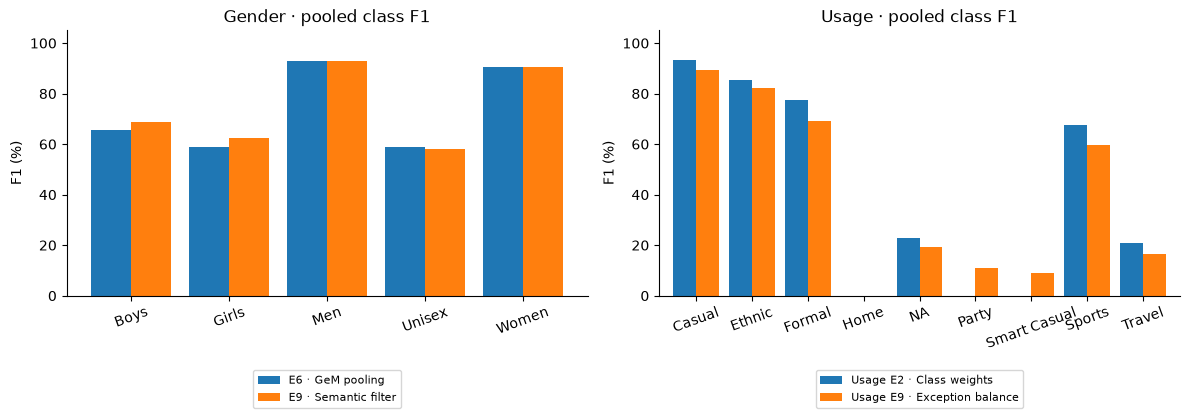

In [56]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "e87_classes.png", dpi=150, bbox_inches="tight")
plt.show()

### 18.3 Inspect learning curves from the saved epoch records

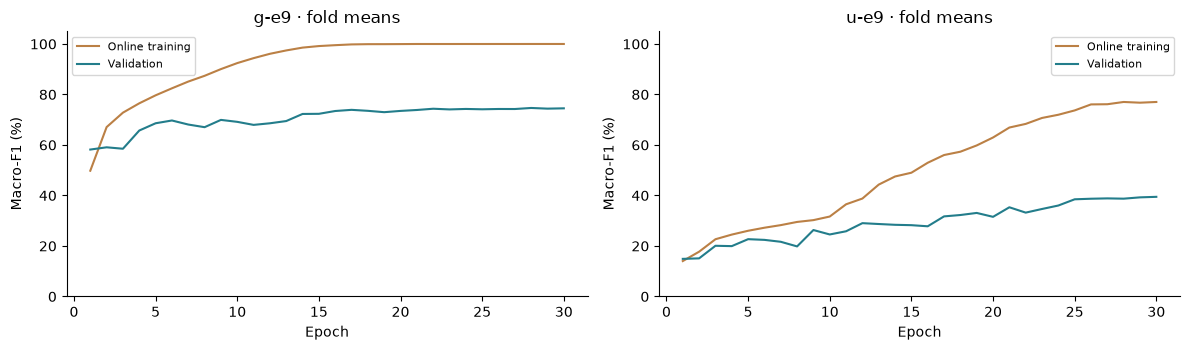

In [57]:
curve_ids = ['g-e9', 'u-e9']
fig, axes = plt.subplots(1, len(curve_ids), figsize=(12, 3.6), squeeze=False)
for ax, model_id in zip(axes[0], curve_ids):
    rows = historical_curves.loc[historical_curves.model_id.eq(model_id)]
    assert len(rows), model_id
    ax.plot(rows.epoch, rows.train_macro_f1*100, label='Online training', color='#bb8045')
    ax.plot(rows.epoch, rows.validation_macro_f1*100, label='Validation', color='#237d8b')
    ax.set(title=model_id+' · fold means', xlabel='Epoch', ylabel='Macro-F1 (%)', ylim=(0,105))
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "e87_classes_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### 18.4 Read matched corruption results for every saved fold

In [58]:
robustness_keys=['gem', 'filter', 'usage2', 'usage9']
robustness_sources={key:evidence_lock['stages'][key]['robustness_paths'] for key in robustness_keys}
robustness_frames=[]
for key, paths in robustness_sources.items():
    stage=evidence_lock['stages'][key]
    paths = [str(p).replace('reports/task3_', 'reports/task3/', 1) for p in paths]
    rows=pd.concat([pd.read_csv(REPO_DIR/path) for path in paths],ignore_index=True)
    assert set(rows.run_id)==set(stage['run_ids'])
    rows['Stage'],rows['Target']=stage['label'],stage['target']
    robustness_frames.append(rows)
robustness_rows=pd.concat(robustness_frames,ignore_index=True)
induced=robustness_rows.groupby(['Target','Stage','corruption']).macro_f1_change.mean().mul(100)
display(induced.unstack('corruption').round(2))

corruption                           brightness_085  brightness_115  \
Target Stage                                                          
gender E6 · GeM pooling                      -20.42           -3.69   
       E9 · Semantic filter                  -18.54           -4.36   
usage  Usage E2 · Class weights              -12.89           -3.16   
       Usage E9 · Exception balance          -21.43           -3.54   

corruption                           grayscale  jpeg_75  translation_003  
Target Stage                                                              
gender E6 · GeM pooling                  -3.66    -2.95           -14.65  
       E9 · Semantic filter              -3.66    -2.18           -14.55  
usage  Usage E2 · Class weights          -1.45    -0.07            -8.69  
       Usage E9 · Exception balance      -4.16    -2.07            -8.19

### 18.5 Plot the change caused by each corruption

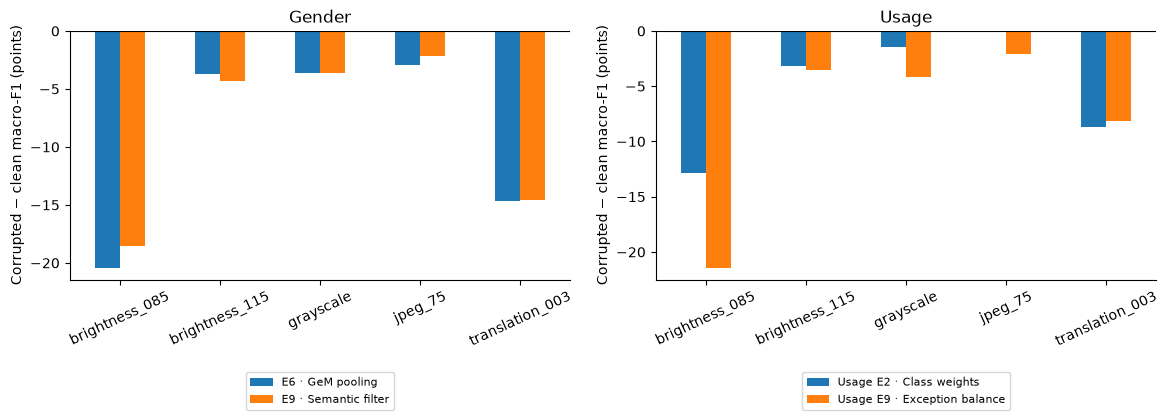

In [59]:
targets=robustness_rows.Target.unique()
fig,axes=plt.subplots(1,len(targets),figsize=(12,4.7),squeeze=False)
for ax,target in zip(axes[0],targets):
    values=induced.loc[target].unstack('Stage')
    values.plot.bar(ax=ax,rot=25)
    ax.axhline(0,color='black',linewidth=.8)
    ax.set(title=target.title(),ylabel='Corrupted − clean macro-F1 (points)',xlabel='')
    ax.legend(fontsize=8,loc='upper center',bbox_to_anchor=(.5,-.35))
fig.tight_layout()
fig.savefig(FIGURES / "e87_robustness.png", dpi=150, bbox_inches="tight")
plt.show()

**E9 result: the Gender mechanism works, but both children fail the full frozen rule**


**Gender E9 — useful label filtering, but overfitting remains**

The semantic filter did what it was meant to do. Clean child-to-adult errors fell from 229 to 133, a reduction of 41.9%. Boys F1 rose from 0.6560 to 0.6868 and Girls from 0.5885 to 0.6254, so their mean reached 0.6561 and passed its gate. Balanced accuracy rose by 0.0338. Four folds improved, pooled macro-F1 rose reliably over E6, and E9 also beats the previous best E8 score of 0.7412 by 0.0039. This supports the hypothesis that a small set of contradictory adult labels was teaching the model the wrong child/adult boundary.

A secondary clean-slice diagnostic removes the 305 rule-flagged semantic conflicts from both E6 and E9 evaluation after training. On the remaining 32,468 rows, macro-F1 rises from 0.7498 to 0.7733, a direct gain of 0.0235. The paired family bootstrap mean gain is 0.0236 with a 95% interval from 0.0125 to 0.0347, and all five fold changes are positive: +0.0354, +0.0012, +0.0124, +0.0397, and +0.0289. This diagnostic strengthens the evidence that the filter improved the learnable label boundary. It does **not** replace the official full-validation result because the 305 rows were flagged by a deterministic name rule rather than confirmed by human review. The official result therefore remains four improved folds out of five.

The child still fails the prewritten all-gates rule. Its 0.7451 macro-F1 misses 0.7462 by 0.0011. Fold 1 falls by 0.0089, worse than the allowed 0.005 loss. The mean finished-model train-validation gap is 0.2548, just above the 0.2532 limit. Every finished fold still scores about 1.0 on clean training data, so filtering 305 rows did not solve memorisation. Unisex F1 falls by 0.0103, while Men and Women stay essentially flat. NLL rises by only 0.0071 and ECE by 0.0004; all corruption and 2 GiB memory guards pass. **Keep E9 as the strongest observed Gender benchmark, but do not promote it to confirmation seeds under the frozen rule.**

**Usage E9 — reject exception balancing**

The exception error rate fell sharply from 48.05% to 28.88%, so the loss did force attention onto unusual ArticleType/Usage pairs. Party and Smart Casual moved from zero F1 to 0.1111 and 0.0909. That local success came at a much larger cost: the usual-row error rate more than doubled from 6.59% to 14.85%, ordinary accuracy fell by 0.0545, NLL rose by 0.0987, and only two folds improved. The wrong-exception shortcut rate reached 92.47%, narrowly missing its 92.21% gate, while mixed-label-family accuracy fell from 0.6843 to 0.6396.

Pooled macro-F1 falls by 0.0126 from E2 and by 0.0239 from E8. The paired interval against E2 crosses zero, and the interval against E8 is -0.0560 to +0.0061. Formal F1 falls by 0.0863, Sports by 0.0794, Casual by 0.0380, and Ethnic by 0.0314. Dark-image robustness also regresses by 0.0855 relative to E2. The roughly five-times exception group factor moved the boundary too far instead of separating ambiguous rows. **Reject E9 Usage and retain E2 as the accepted Usage parent.**

**Decision**

Do not run confirmation seeds for either E9 child and do not stack exception balancing into another Usage model. The Gender result is scientifically useful: it identifies label conflict as one real cause, while its unchanged train-validation gap supports the view that label filtering alone is not the cure for overfitting. The Usage result is also useful because it separates two goals: reducing exception errors is possible, but equal group mass is too strong and harms the supported classes that dominate real performance.

**Scope.** The proposal and decision wording above describe this historical stage. Later named candidates test new hypotheses; they do not rewrite this stage's acceptance rule.

## 19. E10: add an audience-learning head

Historical hypothesis → matched result → decision. The original gates remain unchanged after seeing the outcome.

**Gender E10 hypothesis — auxiliary audience supervision**

E9 showed that contradictory adult/child labels are one real source of error, but filtering
305 rule-flagged rows did not solve memorisation and E9 failed its frozen finalist gates. The
next child therefore returns to the exact accepted E6 GeM parent. It does **not** stack E9
filtering, E8 checkpoint selection, augmentation, class weighting, or another architecture.

**Evidence and mechanism**

After removing the 305 rule-flagged rows only for diagnosis, E6 makes 3,338 clean errors.
Of these, 1,691 swap male- and female-audience labels at the same age level and 1,268 involve
Unisex. Together they are 2,959 errors, or about **88.65%** of the clean E6 failures. The
remaining problem is therefore mainly the broad audience boundary rather than only the
Boys-versus-Men or Girls-versus-Women age boundary.

E10 adds a three-way helper target derived from the existing catalogue labels:

- male audience: `Boys` and `Men`;
- female audience: `Girls` and `Women`;
- unisex audience: `Unisex`.

These are catalogue audience groups, not an inference about a person's real-world gender. All
305 rule-flagged adult/child conflicts remain consistent under this mapping: `Boys` and `Men`
share the same helper label, as do `Girls` and `Women`. The helper can therefore teach the
shared features a broad audience boundary without depending on the disputed age split.

**One changed factor**

Use the exact E6 SmallCNN with fixed GeM `p=3`, native `80x60` RGB input, ordinary five-way
cross-entropy, AdamW recipe, 30 epochs, final-epoch selection, seed 2753, and the same five
family-safe folds. Add one `Linear(256, 3)` auxiliary head beside the existing `Linear(256, 5)`
head. This adds 771 parameters, giving **390,952** trainable parameters. Only the five-way head
produces the submitted prediction; the helper head is training-only.

The fixed training loss is `0.5 * CE5 + 0.7325 * CE3`. This is not a searched coefficient. At
random initialisation, `CE5` is about `ln(5)` and `CE3` about `ln(3)`. These coefficients make
both initial contributions about 0.805 and keep their sum close to E6's original `ln(5)` loss
scale. The test therefore adds balanced helper supervision without opening a weight sweep.

**Required checks before training**

- Reproduce the 3,338 clean E6 errors and confirm at least 85% concern audience or Unisex.
- Confirm every one of the 305 rule-flagged rows maps consistently to its helper label.
- Confirm all three helper labels appear in every fold-training complement and validation fold.
- Verify the five-way output remains unchanged in shape and class order.
- Run a zero-step shape and memory check; estimated peak allocation must remain below 2 GiB.
- Do not take an optimiser step if any check fails.

**Frozen acceptance gates**

E10 passes only if every gate below passes at seed 2753:

- pooled five-way OOF macro-F1 at least **0.7462**;
- paired 10,000-family bootstrap lower 95% bound above zero versus E6;
- at least four of five folds improve, worst fold change at least -0.005, and fold SD at most 0.0209;
- derived three-way audience macro-F1 at least **0.8196**;
- Unisex F1 at least 0.6100 and Unisex recall at least 0.5370;
- mean Boys/Girls F1 at least 0.6122;
- the 2,959 clean audience-or-Unisex errors fall by at least 10%, to at most 2,663;
- NLL at most 0.4525, ECE-15 at most 0.0842, and mean finished-model train-validation gap at most 0.2466;
- no corruption macro-F1 change falls more than 0.02 below E6;
- peak allocation below 2 GiB, median fold time at most 720 seconds, and prediction time at most 1.10 times E6.

Reject E10 after this one seed if the paired interval crosses zero, fewer than four folds
improve, Unisex does not improve, or the overfit-gap gate fails. Run confirmation seeds only if
every gate passes. The Usage label audit is deliberately deferred; this section opens no Usage
E10 model and starts no training. `task3_training/audience_aux_e10_experiment.ipynb` contains the
zero-step audit and the only five-fold E10 training call.

### 19.1 Recompute the comparison from registered confusion counts

In [60]:
selected_stages = ['gem', 'aux']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
E6 · GeM pooling,gender,"[0, 1, 2, 3, 4]",Original,32773,73.35,89.32
E10 · Audience head,gender,"[0, 1, 2, 3, 4]",Original,32773,72.69,89.30


### 19.2 Plot class gains and losses on the same folds

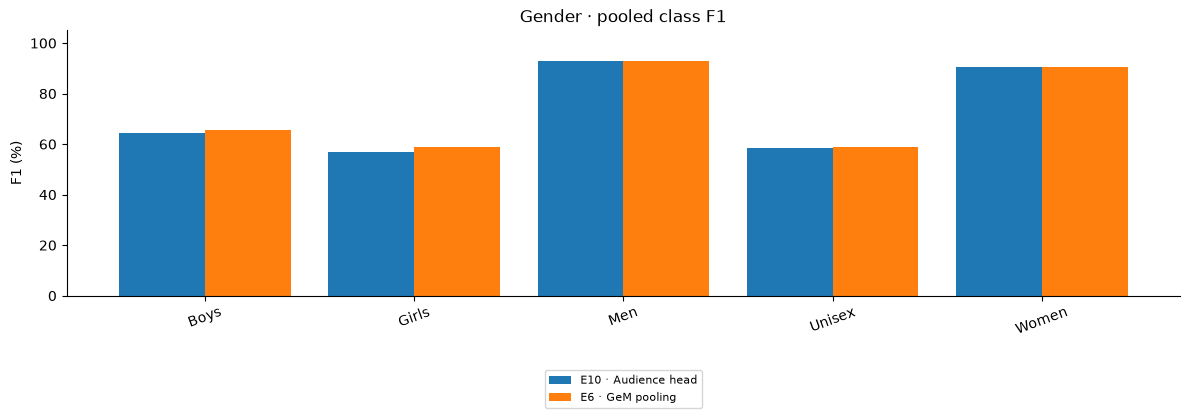

In [61]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "e93_classes.png", dpi=150, bbox_inches="tight")
plt.show()

### 19.3 Inspect learning curves from the saved epoch records

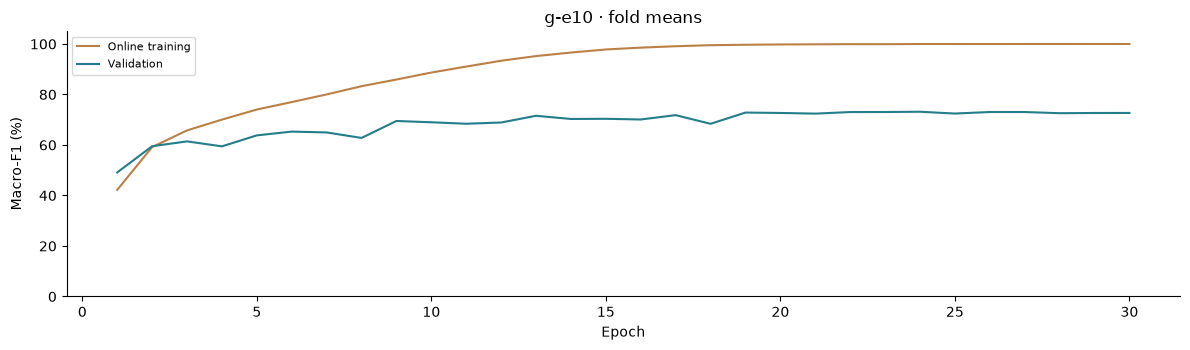

In [62]:
curve_ids = ['g-e10']
fig, axes = plt.subplots(1, len(curve_ids), figsize=(12, 3.6), squeeze=False)
for ax, model_id in zip(axes[0], curve_ids):
    rows = historical_curves.loc[historical_curves.model_id.eq(model_id)]
    assert len(rows), model_id
    ax.plot(rows.epoch, rows.train_macro_f1*100, label='Online training', color='#bb8045')
    ax.plot(rows.epoch, rows.validation_macro_f1*100, label='Validation', color='#237d8b')
    ax.set(title=model_id+' · fold means', xlabel='Epoch', ylabel='Macro-F1 (%)', ylim=(0,105))
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "e93_classes_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### 19.4 Read matched corruption results for every saved fold

In [63]:
robustness_keys=['gem', 'aux']
robustness_sources={key:evidence_lock['stages'][key]['robustness_paths'] for key in robustness_keys}
robustness_frames=[]
for key, paths in robustness_sources.items():
    stage=evidence_lock['stages'][key]
    paths = [str(p).replace('reports/task3_', 'reports/task3/', 1) for p in paths]
    rows=pd.concat([pd.read_csv(REPO_DIR/path) for path in paths],ignore_index=True)
    assert set(rows.run_id)==set(stage['run_ids'])
    rows['Stage'],rows['Target']=stage['label'],stage['target']
    robustness_frames.append(rows)
robustness_rows=pd.concat(robustness_frames,ignore_index=True)
induced=robustness_rows.groupby(['Target','Stage','corruption']).macro_f1_change.mean().mul(100)
display(induced.unstack('corruption').round(2))

corruption                  brightness_085  brightness_115  grayscale  \
Target Stage                                                            
gender E10 · Audience head          -21.79           -3.87      -2.86   
       E6 · GeM pooling             -20.42           -3.69      -3.66   

corruption                  jpeg_75  translation_003  
Target Stage                                          
gender E10 · Audience head    -2.23           -14.29  
       E6 · GeM pooling       -2.95           -14.65

### 19.5 Plot the change caused by each corruption

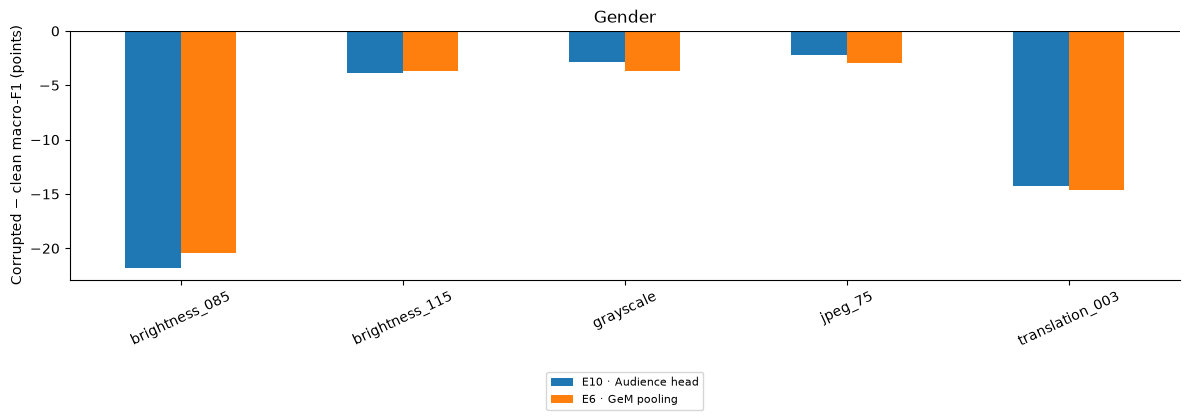

In [64]:
targets=robustness_rows.Target.unique()
fig,axes=plt.subplots(1,len(targets),figsize=(12,4.7),squeeze=False)
for ax,target in zip(axes[0],targets):
    values=induced.loc[target].unstack('Stage')
    values.plot.bar(ax=ax,rot=25)
    ax.axhline(0,color='black',linewidth=.8)
    ax.set(title=target.title(),ylabel='Corrupted − clean macro-F1 (points)',xlabel='')
    ax.legend(fontsize=8,loc='upper center',bbox_to_anchor=(.5,-.35))
fig.tight_layout()
fig.savefig(FIGURES / "e93_robustness.png", dpi=150, bbox_inches="tight")
plt.show()

**E10 result: reject the auxiliary audience head**


The helper head did not improve the broad boundary it was designed to teach. Derived three-way audience macro-F1 is effectively unchanged, and the targeted error count falls by only 13 rows, or 0.44%. Same-age wrong-audience errors fall by 26, but errors involving Unisex rise by 13. Total clean errors rise from 3,338 to 3,352. This is direct evidence against the E10 mechanism, not just a failure of the final five-way score.

Five-way performance also gets worse. The pooled score falls by 0.0066, the paired family interval crosses zero, and only fold 3 improves. Boys F1 falls by 0.0105, Girls by 0.0214, and Unisex by 0.0028. Their losses are not offset by the tiny Men and Women gains. A likely explanation is that the helper target is only a coarse remapping of the same five labels, so it adds little new information while encouraging Boys/Men and Girls/Women to share features. That explanation is an inference; the flat audience score and class changes are the observed evidence.

Overfitting remains. Every finished fold reaches approximately 1.0 clean-training macro-F1, while the mean train-validation gap is 0.2731. Each fold's best validation epoch occurs before epoch 30—epochs 26, 21, 20, 19, and 13—then the final score falls. The auxiliary objective therefore does not regularise the shared representation enough to satisfy the prewritten gap gate.

E10 does retain a few secondary strengths: NLL improves from 0.4325 to 0.4271, ECE-15 from 0.0642 to 0.0626, fold SD passes at 0.0187, the worst robustness difference is only -0.0137, peak allocation is 0.443 GiB, and median fold time is 464 seconds. Overall, E10 passes 7 of 17 gates and fails 10. These secondary wins do not rescue a model that fails its primary, paired, mechanism, minority, and overfitting gates. **Reject E10, run no confirmation seed, and retain E6 as the unchanged Gender parent for any later test.**

**Scope.** The proposal and decision wording above describe this historical stage. Later named candidates test new hypotheses; they do not rewrite this stage's acceptance rule.

## 20. Second EDA: Audit A, can the label be seen?

This audit came after E1–E10. It is a response to their failures, not a claim that we knew those results in advance.

**Audit A — visual observability and label ceiling**

The review population contains every ultra-rare usage row plus deterministic family-stratified samples from common usage and every gender class. Each blind form asks separate gender and usage knowability, judgement, and confidence questions. The answer key is created only after both completed forms pass validation and are locked, so labels cannot influence the first judgement.

### 20.1 Check the blind-review population and its completion status

In [65]:
review_status = pd.read_csv(
    REPO_DIR / ('results/evidence/task3/clean_slate_eda/observa'
        'bility_review/observability_review_summary.csv'), keep_default_na=False)
reviewer_one = pd.read_csv(REPO_DIR / ('results/evidence/task3/clean_slate_eda/obser'
    'vability_review/observability_reviewer_1.csv'), keep_default_na=False)
reviewer_two = pd.read_csv(REPO_DIR / ('results/evidence/task3/clean_slate_eda/obser'
    'vability_review/observability_reviewer_2.csv'), keep_default_na=False)
display(review_status.T.rename(columns={0:'Saved value'}))
print('Gender judgements filled:', reviewer_one.gender_judgement.ne('').sum(),
      reviewer_two.gender_judgement.ne('').sum())
print('Usage judgements filled:', reviewer_one.usage_judgement.ne('').sum(),
      reviewer_two.usage_judgement.ne('').sum())

,Saved value
review_status,deferred_non_blocking
unique_images,367
ultra_rare_usage_rows,143
common_usage_sample_rows,100
gender_sample_rows,125
reviewers_required,2
labels_exposed_in_reviewer_files,0


Gender judgements filled: 0 0
Usage judgements filled: 0 0


**Finding.** The pack contains 367 unique teacher images: all 143 ultra-rare usage rows, 100 common-usage sample rows, and 125 gender sample rows, with overlap removed. Both reviewer files expose zero labels. Completing this large blind review is deferred. We therefore make no agreement, kappa, or visually-knowable-rate claim, but the missing human judgement does not block model training.

## 21. Second EDA: Audit B, foreground and nuisance signal

Test whether the product, colour or background carries the useful signal.

**Audit B — foreground, background, and global image signal**

The foreground rule starts from near-white border pixels and keeps only white pixels connected to that border as background. Empty, tiny, or almost-full proposals fall back to the full frame. The threshold and fallback are label-blind and fixed before any target summary.

### 21.1 Plot the fixed-view diagnostic probes

,target,view,sample_rows,pooled_macro_f1,fold_macro_f1_sd
0,gender,foreground_masked_hog,4483,0.6814,0.0183
1,gender,grayscale_hog,4483,0.6752,0.0202
2,gender,full_rgb_hog,4483,0.6736,0.0267
3,gender,silhouette_hog,4483,0.6616,0.0212
4,gender,foreground_letterbox_hog,4483,0.6326,0.0218
5,gender,colour_summary,4483,0.5351,0.0138
6,gender,border_hog,4483,0.5082,0.0148
7,gender,global_geometry_colour,4483,0.4784,0.0106
8,usage,full_rgb_hog,4878,0.4541,0.0499
9,usage,foreground_masked_hog,4878,0.4440,0.0467


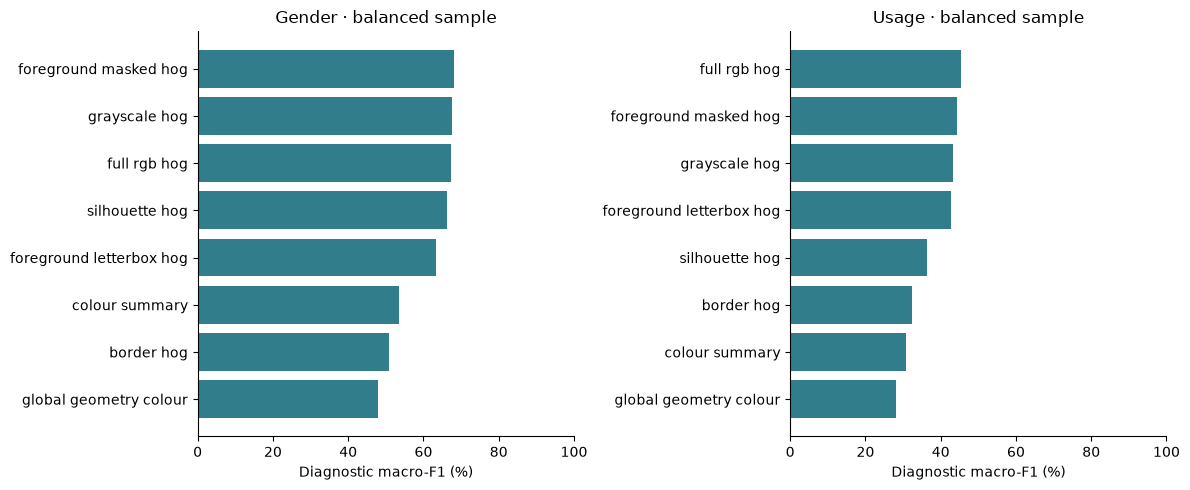

In [66]:
probes = pd.read_csv(
    REPO_DIR / 'results/evidence/task3/clean_slate_eda/view_probes/view_probe_summary.csv',
        keep_default_na=False)
display(probes[['target','view','sample_rows','pooled_macro_f1','fold_macro_f1_sd']].round(4))
fig, axes = plt.subplots(1,2,figsize=(12,5))
for ax,target in zip(axes,['gender','usage']):
    rows = probes.loc[probes.target.eq(target)].sort_values('pooled_macro_f1')
    ax.barh(rows.view.str.replace('_',' '),100*rows.pooled_macro_f1,color='#327d8b')
    ax.set(xlim=(0,100),xlabel='Diagnostic macro-F1 (%)',title=target.title()+' · balanced sample')
fig.tight_layout()
fig.savefig(FIGURES / "eda_view_probes.png", dpi=150, bbox_inches="tight")
plt.show()

### 21.2 Compare global associations with within-type associations

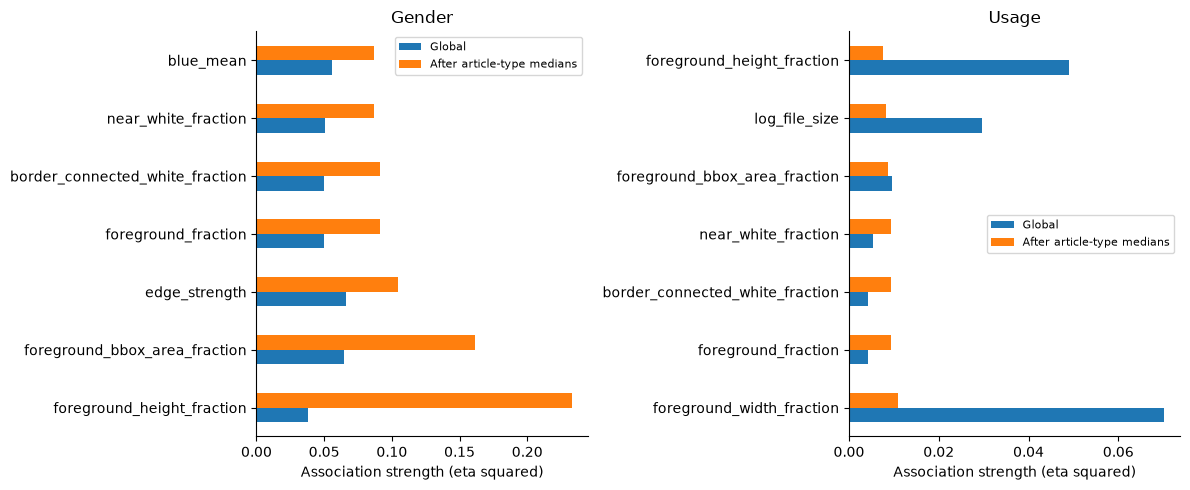

In [67]:
associations = pd.read_csv(
    REPO_DIR / 'results/evidence/task3/clean_slate_eda/nuisance_association.csv',
        keep_default_na=False)
fig, axes = plt.subplots(1,2,figsize=(12,5))
for ax,target in zip(axes,['gender','usage']):
    rows = associations.loc[associations.target.eq(target)].nlargest(7,
        'within_article_type_eta_squared')
    rows.set_index('feature')[['global_eta_squared',
        'within_article_type_eta_squared']].plot.barh(ax=ax)
    ax.set(title=target.title(),xlabel='Association strength (eta squared)',ylabel='')
    ax.legend(['Global','After article-type medians'],fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "eda_nuisance_associations.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding.** The fixed foreground rule uses its safe full-frame fallback on 525 of 32,773 images: 524 images have foreground covering almost the whole canvas and one is empty or tiny. Twelve teacher images have a non-standard shape, so probe inputs are resized to the fixed 60×80 canvas while their original geometry remains recorded. On the balanced diagnostic sample, mask-only HOG is strongest for gender (pooled macro-F1 0.6814), slightly above grayscale (0.6752) and full RGB (0.6736). The aspect-preserving letterbox crop falls to 0.6326, so enlarging and repositioning the object is harmful even without stretching it. Full RGB HOG is strongest for usage (0.4541), ahead of mask-only (0.4440), grayscale (0.4314), and letterbox crop (0.4276). Border-only and low-dimensional global/geometry/colour probes remain predictive—gender 0.5082/0.4784 and usage 0.3239/0.2802. This shows shortcut risk, but it does not prove that every global feature is unwanted noise. After article-type medians are removed, gender still has a large association with foreground height (eta-squared 0.2329), while usage's largest remaining association is only 0.0109. These diagnostic scores must not be compared directly with full-population E1–E10 scores.

## 22. Second EDA: Audit C, families and component weighting

Check whether repeated families explain easy examples or class imbalance.

**Audit C — duplicates, families, and sample unit**

The primary validation population remains product-weighted. Component weighting is measured only as a possible training policy. Historical anchor OOF predictions are used, when locally available, to test whether larger families have different error or confidence patterns.

### 22.1 Compare historical errors by family size

,target,size_band,rows,accuracy,macro_f1,mean_confidence,wrong_mean_confidence
0,gender,1,19043,0.8801,0.7245,0.9546,0.8242
1,gender,2,4276,0.8835,0.7140,0.9542,0.8092
2,gender,3-5,4568,0.9046,0.7715,0.9589,0.8006
3,gender,6+,4886,0.9406,0.8525,0.9709,0.8318
4,usage,1,19042,0.8738,0.4085,0.8806,0.7413
5,usage,2,4276,0.9013,0.4586,0.8889,0.7286
6,usage,3-5,4568,0.9131,0.3642,0.8958,0.7179
7,usage,6+,4886,0.9118,0.3590,0.8990,0.7402


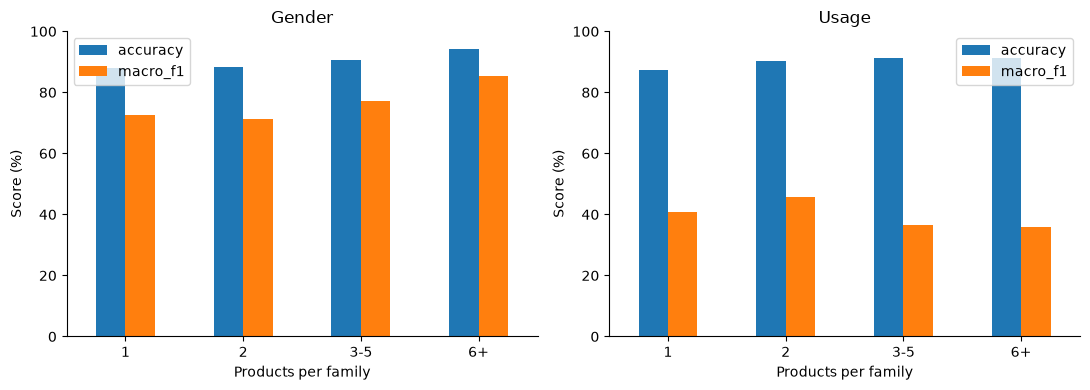

In [68]:
family_errors = pd.read_csv(
    REPO_DIR / 'results/evidence/task3/clean_slate_eda/anchor_error_slices.csv',
        keep_default_na=False)
display(family_errors.round(4))
fig, axes = plt.subplots(1,2,figsize=(11,4))
for ax,target in zip(axes,['gender','usage']):
    rows=family_errors.loc[family_errors.target.eq(target)].set_index('size_band')
    rows[['accuracy','macro_f1']].mul(100).plot.bar(ax=ax,rot=0)
    ax.set(title=target.title(),xlabel='Products per family',ylabel='Score (%)',ylim=(0,100))
fig.tight_layout()
fig.savefig(FIGURES / "eda_family_error_slices.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding.** Both product-family and exact/accepted duplicate groups have zero fold crossings. The 32,773 development rows contain 22,905 families and 32,121 duplicate components. Exact component weighting barely changes the large class shares, so it is unlikely to solve usage imbalance by itself. Historical OOF errors are lower in larger families for gender (accuracy 0.8801 for singletons versus 0.9406 for families of six or more), showing that repeated family evidence makes the task easier. The official validation metric must remain product-weighted.

## 23. Second EDA: Audit D, representation neighbourhoods

Ask which fixed representation places similarly labelled products near each other.

**Audit D — representation neighbourhoods**

Fold-0 queries search only reference images from folds 1–4, so same-family neighbours are impossible under the verified split. Raw pixels, HOG, fixed scattering, and fold-training-only Fisher vectors are compared using the same query/reference scope. The result tests whether any representation naturally clusters the labels before a full classifier experiment.

### 23.1 Plot non-family neighbour label purity

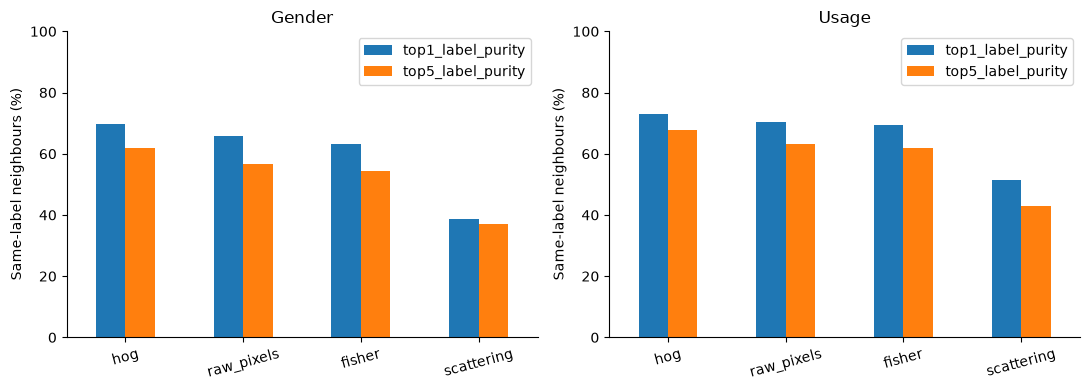

In [69]:
neighbours = pd.read_csv(
    REPO_DIR / ('results/evidence/task3/clean_slate_eda/represen'
        'tation_neighbourhoods/neighbourhood_summary.csv'), keep_default_na=False)
assert neighbours.same_family_neighbours.eq(0).all()
fig, axes=plt.subplots(1,2,figsize=(11,4))
for ax,target in zip(axes,['gender','usage']):
    rows=neighbours.loc[neighbours.target.eq(target)].set_index('representation')
    rows[['top1_label_purity','top5_label_purity']].mul(100).plot.bar(ax=ax,rot=15)
    ax.set(title=target.title(),ylabel='Same-label neighbours (%)',ylim=(0,100),xlabel='')
fig.tight_layout()
fig.savefig(FIGURES / "eda_neighbourhoods.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding.** After removing all same-family neighbours, HOG has the best top-1/top-5 label purity for both gender (0.6971/0.6200) and usage (0.7305/0.6771). Raw pixels and Fisher vectors trail it, while the tested scattering summary is weakest (gender 0.3875/0.3697; usage 0.5130/0.4293). This supports completing a HOG-based classical reference before promoting scattering or prototype methods. It is still a neighbourhood diagnostic, not a final classifier score.

## 24. Second EDA: Audit E, fold acquisition shifts

Explain fold variability without moving any image to a different fold.

**Audit E — fold artifacts**

For each label-free image feature, the notebook compares one fixed fold with the other four using Jensen–Shannon divergence and a standardised mean shift. The folds are never repaired after seeing these values; the audit only explains instability.

### 24.1 Inspect all measured fold shifts

Largest Jensen–Shannon divergence: 0.0008504179436041
Largest absolute mean shift: 0.0282131109594701


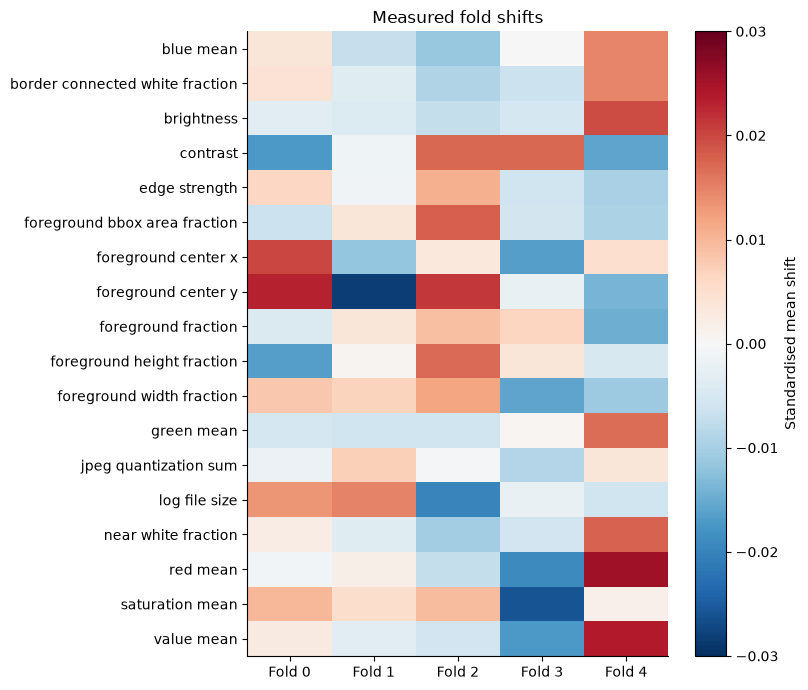

In [70]:
shifts = pd.read_csv(
    REPO_DIR / 'results/evidence/task3/clean_slate_eda/fold_artifact_shifts.csv',
        keep_default_na=False)
shift_table = shifts.pivot(index='feature',columns='fold',values='standardized_mean_shift')
fig,ax=plt.subplots(figsize=(8,7))
heat=ax.imshow(shift_table,cmap='RdBu_r',vmin=-.03,vmax=.03,aspect='auto')
ax.set(xticks=range(5),xticklabels=[f'Fold {i}' for i in range(5)],
       yticks=range(len(shift_table)),yticklabels=shift_table.index.str.replace('_',' '),
           title='Measured fold shifts')
fig.colorbar(heat,ax=ax,label='Standardised mean shift')
print('Largest Jensen–Shannon divergence:',shifts.jensen_shannon_divergence.max())
print('Largest absolute mean shift:',shifts.standardized_mean_shift.abs().max())
fig.tight_layout()
fig.savefig(FIGURES / "eda_fold_shifts.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding.** The fixed folds are well balanced on the 18 measured global image properties. The largest Jensen–Shannon divergence is only 0.00085 (fold 0 edge strength), and the largest absolute standardised mean shift is 0.0282 (fold 1 foreground vertical centre). These measured marginal properties do not explain the much larger model score spread. This does not rule out finer joint or semantic shifts, and the canonical folds stay unchanged.

**EDA decision gate**

The automated evidence is complete enough to start controlled model screens. The human label ceiling remains unknown until the two blind reviews are completed, so the observability gate stays visible as deferred rather than being replaced by model guesses. It is not a training blocker. Gender and usage now take separate model paths because their evidence points to different problems.

## 25. Classical and scratch transformer checks

Test a different representation without importing pretrained knowledge.

### 25.1 Recompute the comparison from registered confusion counts

In [71]:
selected_stages = ['gem04', 'swin_g', 'usage204', 'swin_u']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
E6 · GeM pooling,gender,"[0, 4]",Original,13110,72.30,89.19
Scratch Micro-Swin,gender,"[0, 4]",Original,13110,68.47,86.96
Usage E2 · Class weights,usage,"[0, 4]",Original,13110,40.73,89.06
Usage · Scratch Micro-Swin,usage,"[0, 4]",Original,13110,39.73,87.56


### 25.2 Plot class gains and losses on the same folds

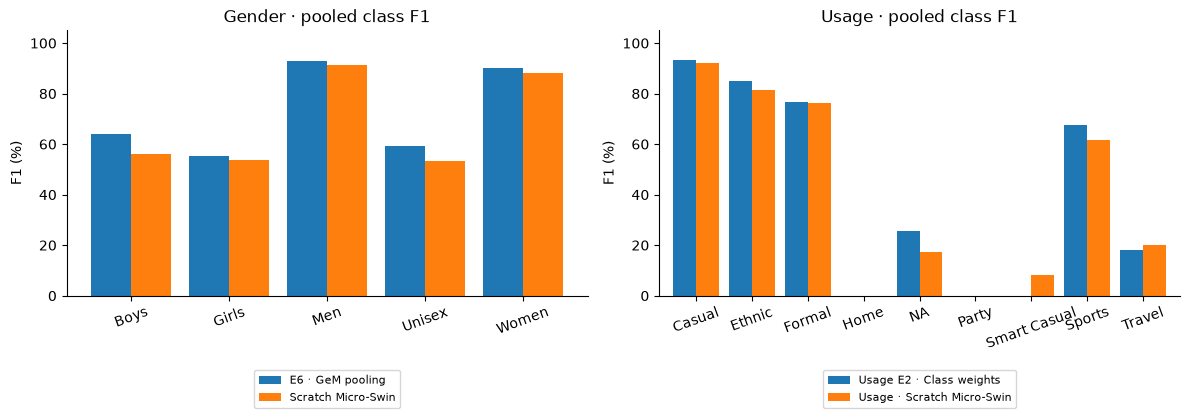

In [72]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "micro_swin_classes.png", dpi=150, bbox_inches="tight")
plt.show()

### 25.3 Recompute the comparison from registered confusion counts

In [73]:
selected_stages = ['gem04', 'hog_g', 'usage204', 'type_u']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
E6 · GeM pooling,gender,"[0, 4]",Original,13110,72.30,89.19
Gender S1 · HOG SVM,gender,"[0, 4]",Original,13110,66.08,85.28
Usage E2 · Class weights,usage,"[0, 4]",Original,13110,40.73,89.06
Usage S1 · Type cascade,usage,"[0, 4]",Original,13110,31.93,85.86


### 25.4 Plot class gains and losses on the same folds

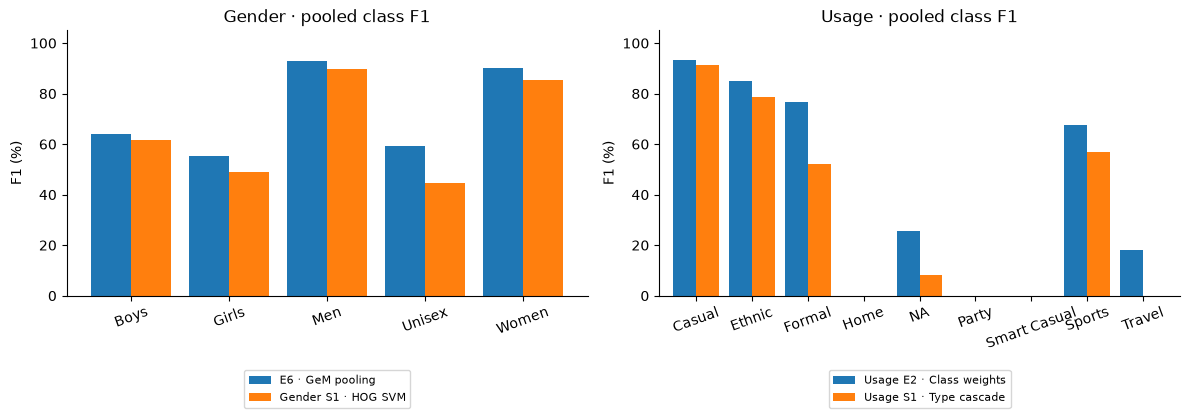

In [74]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "classical_screens.png", dpi=150, bbox_inches="tight")
plt.show()

**Observed result.** The matched two-fold Gender HOG-SVM reaches 66.08% F1, below GeM. Its handcrafted features did not match the learned representation on this full screen. Scratch Micro-Swin also falls short at 68.47%, so attention alone is not a cure for the data and fit limits.

The Usage type-posterior cascade reaches only 31.93%, versus the matched E2 reference at 40.73%. Its small clean train/validation gap largely comes from weak fitting (about 38.15% versus 31.94%), not strong generalisation. Routing every decision through type loses occasion exceptions and passes type-prediction errors downstream. Usage Micro-Swin reaches 39.73%, with a large clean training gap and worse probability quality. A smaller gap or a newer architecture alone is therefore an inadequate selection rule.

### 25.5 Compare the saved fit gaps across model families

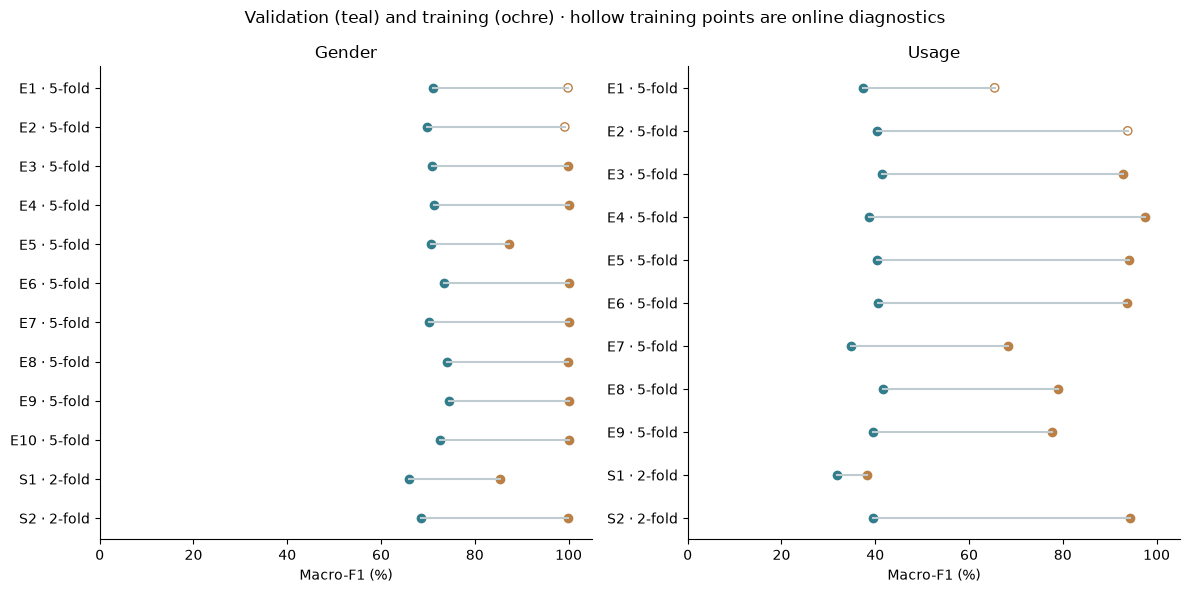

In [75]:
historical_fit = pd.read_csv(
    REPO_DIR / 'reports/task3/failure_review/evidence/all_model_overfit_summary.csv',
        keep_default_na=False)
fig,axes=plt.subplots(1,2,figsize=(12,6))
for ax,target in zip(axes,['gender','usage']):
    rows=historical_fit.loc[historical_fit.target.eq(target)].reset_index(drop=True)
    for i,row in rows.iterrows():
        ax.plot([100*row.mean_validation_macro_f1,100*row.mean_train_macro_f1],[i,i],
            color='#becbd0')
        ax.scatter(100*row.mean_validation_macro_f1,i,color='#327d8b')
        ax.scatter(100*row.mean_train_macro_f1,i,
            facecolors='none' if row.train_score_source=='epoch-log' else '#bb8045',
                edgecolors='#bb8045')
    ax.set(yticks=range(len(rows)),yticklabels=rows.code+' · '+rows.scope,xlim=(0,105),
        xlabel='Macro-F1 (%)',title=target.title())
    ax.invert_yaxis()
fig.suptitle(
    'Validation (teal) and training (ochre) · hollow training points are online diagnostics')
fig.tight_layout()
fig.savefig(FIGURES / "model_family_fit_overview.png", dpi=150, bbox_inches="tight")
plt.show()

**Hypotheses.** HOG uses fixed edge patterns, so it tests whether the dataset needs a learned CNN representation at all. HSV adds colour summaries. A calibrated linear SVM tests a different decision boundary. A type-to-Usage cascade tests whether most Usage signal comes through article type. Scratch Micro-Swin tests local attention and shifted windows at low resolution.

**What these checks can tell us.** A good balanced-sample HOG probe does not guarantee a good full-population calibrated classifier. Class priors, fold support and calibration all change that problem. The Micro-Swin screens use only folds 0 and 4; they are matched screens, not five-fold results. High training scores alongside low validation scores argue against simply adding capacity. The fit chart distinguishes online training scores from clean finished-model scores; only the latter support a direct memorisation-gap claim.

**Usage U2 and the cascade.** The planned full-RGB HOG SVM keeps calibration inside saved training folds. Home is excluded from fitting but remains in the nine-class score with zero probability. Rare classes must appear in every inner training and calibration subset; weakening this requirement to get a run through would change the experiment. A cascade can be wrong in its article-type stage and cannot recover Usage exceptions when its type mapping assigns them little probability. Neither mechanism is a reason to relabel rare products as Casual. The Usage investigation continues separately; incomplete screens are not promoted into this table.

## 26. Reduce sensitivity to small shifts: G1, G2, G3 and U1

Use the second EDA to test mask, translation and sample-unit hypotheses one at a time.

**Dataset V2 two-fold screen evidence**

The clean-slate data review proposed four single-factor screens before spending another full five-fold run. Each screen uses only canonical folds 0 and 4 at seed 2753. The comparison below therefore filters the frozen parent OOF predictions to those exact same 13,110 rows. A screen is never compared with a five-fold parent total and cannot become a finalist by itself. All values are rebuilt from the saved aggregate predictions, fold histories, metrics, and robustness files in the ignored local evidence cache.

### 26.1 Recompute the comparison from registered confusion counts

In [76]:
selected_stages = ['gem04', 'g1', 'translation04', 'g3', 'usage204', 'u1']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
E6 · GeM pooling,gender,"[0, 4]",Original,13110,72.30,89.19
G1 · Foreground mask,gender,"[0, 4]",Original,13110,72.95,89.26
G2 · Translation,gender,"[0, 4]",Original,13110,74.57,90.31
G3 · Component weights,gender,"[0, 4]",Original,13110,72.45,89.20
Usage E2 · Class weights,usage,"[0, 4]",Original,13110,40.73,89.06
U1 · Component weights,usage,"[0, 4]",Original,13110,41.38,88.99


### 26.2 Plot class gains and losses on the same folds

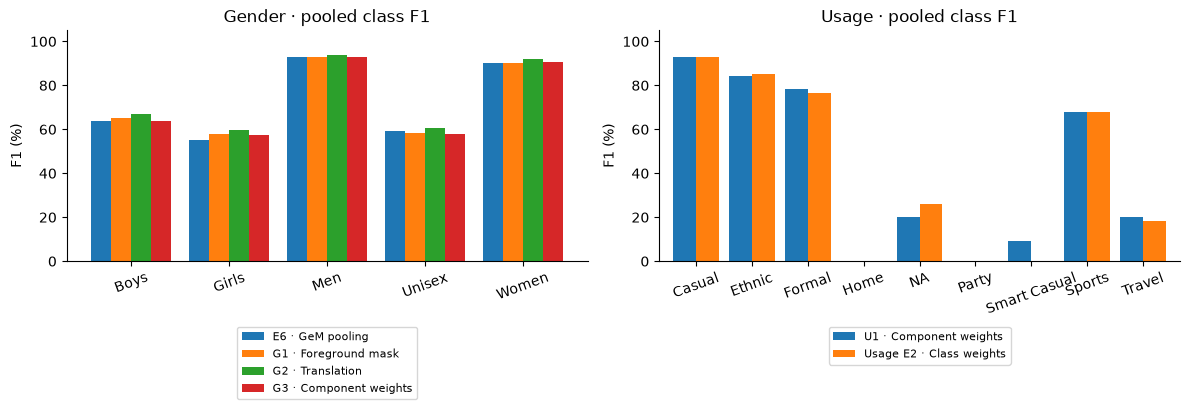

In [77]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "v2_screens.png", dpi=150, bbox_inches="tight")
plt.show()

**Dataset V2 screen result: advance Gender translation to confirmation**


G2 is the only screen with a clear matched improvement. Both folds improve: +0.0409 on fold 0 and +0.0042 on fold 4. Pooled across the two folds, all five Gender classes improve, including Boys (+0.0317), Girls (+0.0461), and Unisex (+0.0130). NLL falls from 0.4476 to 0.2945, ECE-15 falls from 0.0660 to 0.0312, and the translation-corruption loss shrinks from -0.1399 to -0.0169. These results support the mechanism that fixed placement was a shortcut.

G2 reduces but does not solve overfitting. The clean, unshifted finished-model gap falls from 0.2770 to 0.2484, only -0.0286, and clean training macro-F1 remains about 0.994. The smaller online history gap of 0.2164 was measured on shifted training images and is not directly comparable with E6, so it is not used as the claim. G2 also worsens the dark-image robustness change by 0.0353; within fold 4, Boys and Girls F1 fall by 0.0034 and 0.0151 despite their positive two-fold pooled changes.

At this screen stage, G2 was not accepted. It covered only two folds and one seed. The planned next step was one frozen five-fold completion: reuse folds 0 and 4, train only folds 1-3, report the fresh folds separately, and retain the dark-image and clean-gap no-harm checks. No other Dataset V2 change should be stacked into that confirmation.

G1 gives small gains for Boys and Girls but loses 0.0070 Unisex F1, changes the gap by only -0.0067, and its paired interval crosses zero. This suggests that the border/background contains some useful catalogue signal as well as nuisance signal; masking it is not a reliable general fix. G3 is nearly neutral, with opposite fold directions and a lower Unisex F1. The component audit explains the weak lever: only 1,393 of 32,773 development rows belong to multi-row accepted visual components, and the largest component has six rows.

U1 also has opposite fold directions. Its small pooled gain is uncertain, while NLL rises by 0.0050, ECE-15 rises by 0.0029, NA F1 falls by 0.0581, and the final history gap remains about 0.495. Party and Home remain at zero F1. Component weighting therefore does not solve Usage imbalance or overfitting. Keep the five-fold E2 parent unchanged while the research review considers a different Usage direction.

### 26.3 Read the five-fold G2 confirmation checks

In [78]:
g2_gates = pd.read_csv(REPO_DIR / 'reports/task3/g2_gate_audit_20260905/g2_gates.csv',
    keep_default_na=False)
display(g2_gates)

,gate,value,rule,status
0,fresh_folds_1_2_3.macro_f1,0.012947,> 0 matched change,pass
1,fresh_folds_1_2_3.family_bootstrap_lower,-0.003554,> 0,fail
2,fresh_folds_1_2_3.improved_folds,3.000000,>= 2,pass
3,fresh_folds_1_2_3.worst_fold_change,0.002757,>= -0.005,pass
4,five_fold.macro_f1,0.750217,>= 0.7462,pass
5,five_fold.family_bootstrap_lower,0.004105,> 0,pass
6,five_fold.improved_folds,5.000000,>= 4,pass
7,five_fold.worst_fold_change,0.002757,>= -0.005,pass
8,fold_sd,0.012757,<= 0.0209,pass
9,clean_gap,0.244191,<= 0.2466,pass


**Confirmation rejected under its original rules.** G2 reaches 75.02% pooled F1 across all five folds, versus E6's 73.35%. But the fresh folds 1–3 improve by only 1.2947 points with a family-bootstrap 95% interval of −0.3554 to +2.8650. The lower bound is not above zero. The dark-image induced loss is 3.1993 points worse than E6, exceeding the 2-point guard. Those are real failed checks, even though the pooled clean score improved.

**Why translation still informed later work.** The two-fold screen sharply reduced translation corruption loss, consistent with a placement sensitivity. It did not close the clean fit gap, and it exposed a separate lighting weakness. Later named candidates reuse that useful mechanism while retaining G2's historical rejection. They do not retroactively call it an accepted finalist.

## 27. Diagnose the fit gap: darkening, weight decay and numeric precision

Check clean images in evaluation mode before deciding how to regularise the network.

### 27.1 Recompute the comparison from registered confusion counts

In [79]:
selected_stages = ['translation04', 'gd1', 'wd1']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
G2 · Translation,gender,"[0, 4]",Original,13110,74.57,90.31
GD1 · Mild darkening,gender,"[0, 4]",Original,13110,74.12,90.29
Weight decay 0.001,gender,"[0, 4]",Original,13110,74.87,90.45


### 27.2 Plot class gains and losses on the same folds

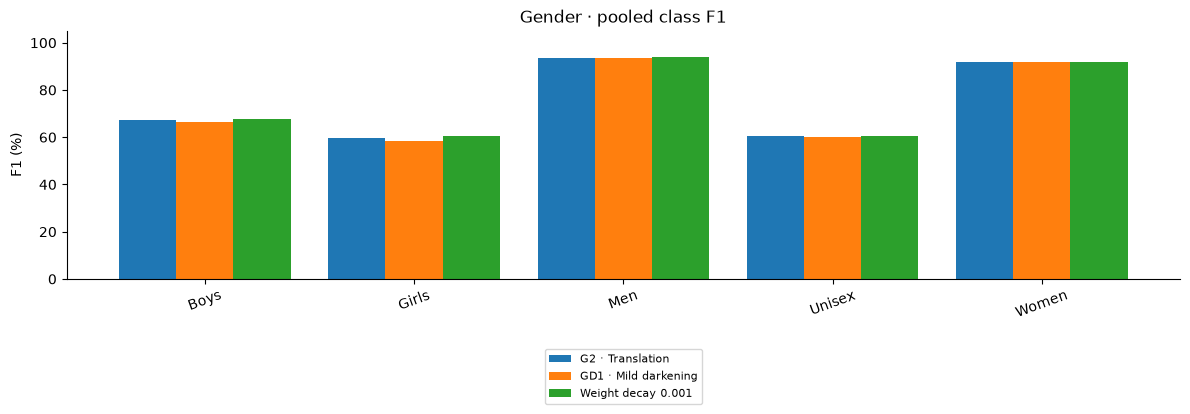

In [80]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "gd1_weight_decay.png", dpi=150, bbox_inches="tight")
plt.show()

### 27.3 Compare clean and corrupted performance in the GD1 audit

,clean_f1,train_f1,gap,dark_f1,shift_f1
model,,,,,
E6,72.30,100.00,27.70,54.35,58.31
G-D1,74.07,99.33,25.25,68.49,70.42
G2,74.55,99.39,24.84,53.07,72.86


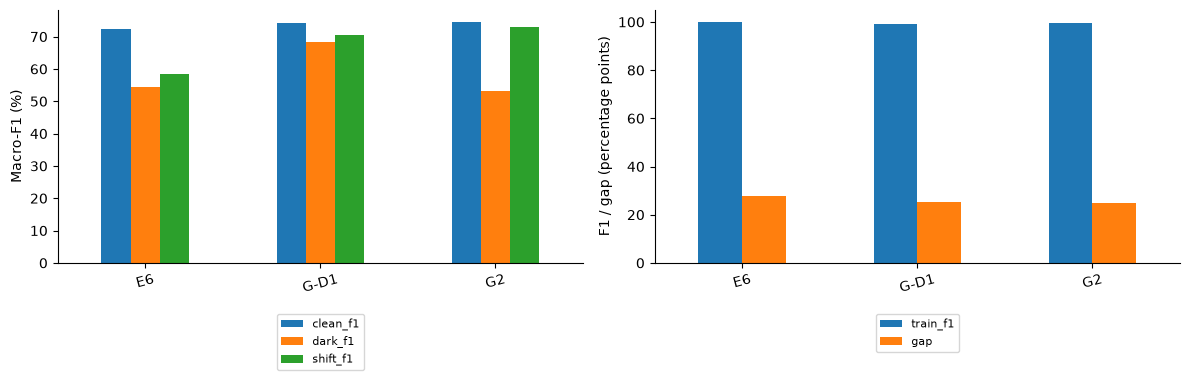

In [81]:
gd1 = pd.read_csv(REPO_DIR / 'reports/task3/gender_gd1_result_20260905/fold_comparison.csv',
    keep_default_na=False)
audit_values=gd1.groupby('model')[['clean_f1','train_f1','gap','dark_f1','shift_f1']].mean(
    ).mul(100)
display(audit_values.round(2))
fig,axes=plt.subplots(1,2,figsize=(12,4))
audit_values[['clean_f1','dark_f1','shift_f1']].plot.bar(ax=axes[0],rot=15)
audit_values[['train_f1','gap']].plot.bar(ax=axes[1],rot=15)
axes[0].set(ylabel='Macro-F1 (%)',xlabel='')
axes[1].set(ylabel='F1 / gap (percentage points)',xlabel='')
for ax in axes:
    ax.legend(fontsize=8,loc='upper center',bbox_to_anchor=(.5,-.18))
fig.tight_layout()
fig.savefig(FIGURES / "gd1_mechanism.png", dpi=150, bbox_inches="tight")
plt.show()

GD1 tests whether mild darkening repairs G2's known lighting failure. Its dark-image gain is large (about 15.89 points), but the clean paired confidence interval and a translation guard fail. Learning tolerance to a corruption is a separate outcome from better clean classification.

Weight decay 0.001 tests whether a stronger penalty on large weights reduces memorisation. The clean gap barely moves, from about 24.84 to 24.54 points, while clean training F1 remains near 99.4%. The tested penalty is too weak to resolve this failure pattern. That does not prove that all weight decay values or optimisers are ineffective.

### 27.4 Verify that numeric settings do not masquerade as a model gain

In [82]:
precision = pd.read_csv(
    REPO_DIR / 'reports/task3/gender_precision_result_20260905/verified_summary.csv',
        keep_default_na=False)
display(precision)

,mode,comparisons,passed,maximum_probability_difference,label_flips
0,ieee,72,72,7.748604e-07,0
1,runtime_default,72,8,2.153635e-03,0


The precision audit checks repeated saved-checkpoint inference under matched IEEE settings. It passes all 72 comparisons with no label flips; default runtime probability differences can be larger even when argmax labels stay unchanged. Later comparisons therefore name the numeric basis. A small runtime difference is not a new learning mechanism. Clean training F1 is measured with dropout disabled, on original unmixed images; online augmentation and MixUp histories are not directly comparable with that score.

## 28. Add dropout and test a narrower head

Reduce the ability to memorise a small collection of feature combinations.

### 28.1 Recompute the comparison from registered confusion counts

In [83]:
selected_stages = ['translation04', 'narrow', 'dropout']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
G2 · Translation,gender,"[0, 4]",Original,13110,74.57,90.31
Narrow 64 channels,gender,"[0, 4]",Original,13110,73.60,90.01
Dropout 0.30,gender,"[0, 4]",Original,13110,75.42,90.16


### 28.2 Plot class gains and losses on the same folds

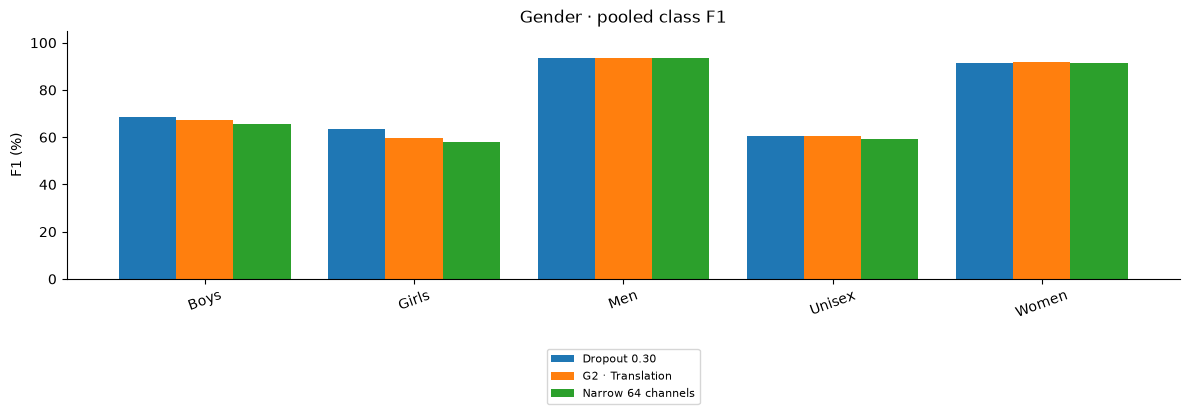

In [84]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "narrow_dropout.png", dpi=150, bbox_inches="tight")
plt.show()

**Narrow-width hypothesis.** Fewer channels limit capacity while preserving the rest of the G2 recipe. Lower training performance alone would not establish success: the intended outcome is a smaller clean gap while preserving minority validation F1. The class chart shows the cost of the actual saved setting; no claim is made that a width search was completed.

**Dropout hypothesis.** Dropping 30% of classifier inputs during training makes reliance on a single feature combination less reliable. The saved Drop30 audit puts the clean gap at about 21.24 points, below G2 but still large. It became a useful diagnostic base. Its dark-image weakness motivates the next controlled change rather than immediate selection.

## 29. Repair the dark-image weakness

Combine Drop30 with a mild training-only lighting change, then test whether more dropout helps.

### 29.1 Recompute the comparison from registered confusion counts

In [85]:
selected_stages = ['dropout', 'dark', 'drop45']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
Dropout 0.30,gender,"[0, 4]",Original,13110,75.42,90.16
Add mild darkening,gender,"[0, 4]",Original,13110,74.22,90.22
Dropout 0.45 + dark,gender,"[0, 4]",Original,13110,72.97,89.75


### 29.2 Plot class gains and losses on the same folds

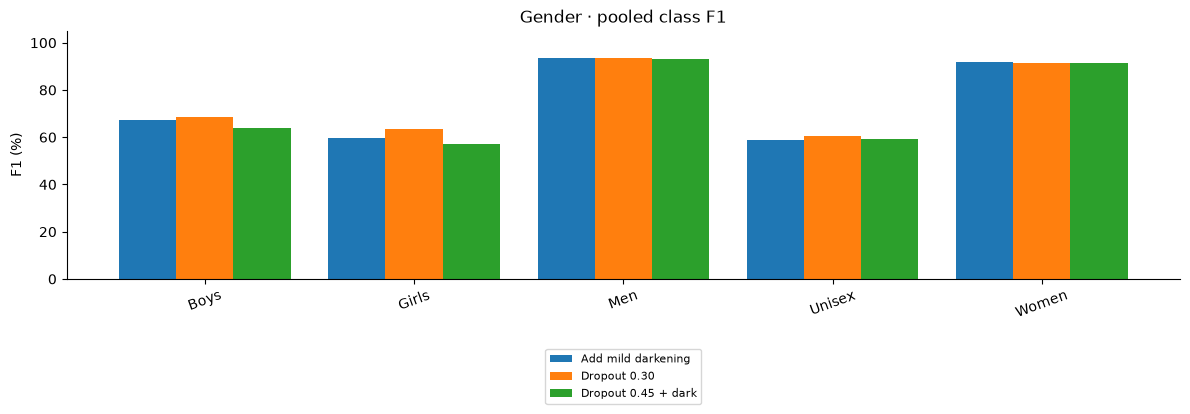

In [86]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "dark_drop45.png", dpi=150, bbox_inches="tight")
plt.show()

### 29.3 Inspect the clean fit and darkening trade-off

,Pooled validation F1 (%),Clean train F1 (%),Mean gap (points)
model,,,
Drop30,75.43,96.65,21.24
Drop30 + darkening,74.22,96.50,22.34
E6,72.30,100.00,27.70
G2,74.57,99.39,24.84


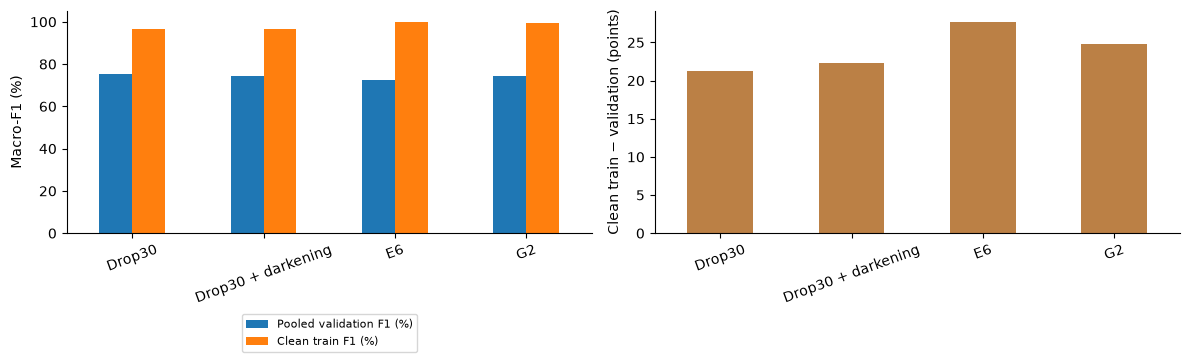

In [87]:
audit = pd.read_csv(
    REPO_DIR / 'reports/task3/gender_dropout_darkening_result_20260905/verified_summary.csv',
        keep_default_na=False)
audit = audit.copy()
audit_values = audit.set_index('model')[['pooled_validation_f1', 'train_f1', 'gap']].mul(100)
audit_values.columns = ['Pooled validation F1 (%)','Clean train F1 (%)','Mean gap (points)']
display(audit_values.round(2))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
audit_values.iloc[:, :2].plot.bar(ax=axes[0], rot=20)
audit_values.iloc[:, 2].plot.bar(ax=axes[1], rot=20, color='#bb8045')
axes[0].set(ylabel='Macro-F1 (%)', ylim=(0,105), xlabel='')
axes[0].legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.34))
axes[1].set(ylabel='Clean train − validation (points)', xlabel='')
fig.tight_layout()
fig.savefig(FIGURES / "dropout_darkening_result_20260905.png", dpi=150, bbox_inches="tight")
plt.show()

**Result and explanation.** Mild darkening improves the failure it directly targets, but the clean pooled F1 falls from 75.43% to 74.22%. The clean gap grows from 21.24 to 22.34 points. The model learned lighting tolerance without solving the remaining discrimination problem. The combined screen failed the gap and grayscale guards.

### 29.4 Test the stronger Drop45 setting

,Pooled validation F1 (%),Clean train F1 (%),Mean gap (points)
model,,,
Drop30 + darkening,74.22,96.50,22.34
Drop45 + darkening,72.96,94.32,21.38
E6,72.30,100.00,27.70
G2,74.57,99.39,24.84


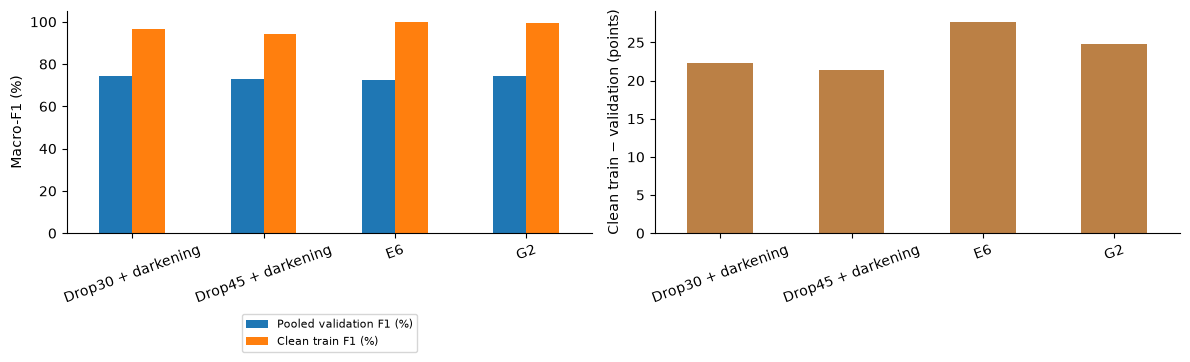

In [88]:
audit = pd.read_csv(
    REPO_DIR / 'reports/task3/gender_stronger_dropout_result_20260905/verified_summary.csv',
        keep_default_na=False)
audit = audit.copy()
audit_values = audit.set_index('model')[['pooled_validation_f1', 'train_f1', 'gap']].mul(100)
audit_values.columns = ['Pooled validation F1 (%)','Clean train F1 (%)','Mean gap (points)']
display(audit_values.round(2))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
audit_values.iloc[:, :2].plot.bar(ax=axes[0], rot=20)
audit_values.iloc[:, 2].plot.bar(ax=axes[1], rot=20, color='#bb8045')
axes[0].set(ylabel='Macro-F1 (%)', ylim=(0,105), xlabel='')
axes[0].legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.34))
axes[1].set(ylabel='Clean train − validation (points)', xlabel='')
fig.tight_layout()
fig.savefig(FIGURES / "stronger_dropout_result_20260905.png", dpi=150, bbox_inches="tight")
plt.show()

**Why more was not better.** Drop45 lowers training F1 but also lowers validation F1 to 72.96%. The gap falls by less than one point, remaining 21.38 points. Boys and Girls lose useful separation, and four checks fail. This pattern is consistent with discarding useful minority features faster than reducing harmful memorisation. It does not reveal which features were dropped on a particular image.

## 30. Reduce colour dependence

Test occasional grayscale while retaining the normal RGB input most of the time.

### 30.1 Recompute the comparison from registered confusion counts

In [89]:
selected_stages = ['dark', 'gray']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
Add mild darkening,gender,"[0, 4]",Original,13110,74.22,90.22
Add grayscale 10%,gender,"[0, 4]",Original,13110,74.79,90.09


### 30.2 Plot class gains and losses on the same folds

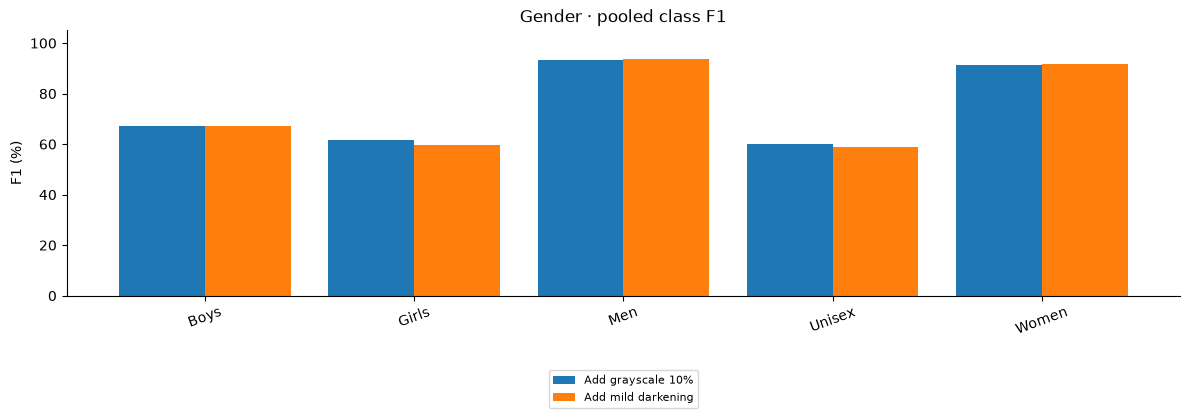

In [90]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "grayscale_classes.png", dpi=150, bbox_inches="tight")
plt.show()

### 30.3 Measure grayscale training on clean images

,Pooled validation F1 (%),Clean train F1 (%),Mean gap (points)
model,,,
Drop30 + darkening,74.22,96.50,22.34
Drop30 + darkening + gray,74.79,96.12,21.33
E6,72.30,100.00,27.70
G2,74.57,99.39,24.84


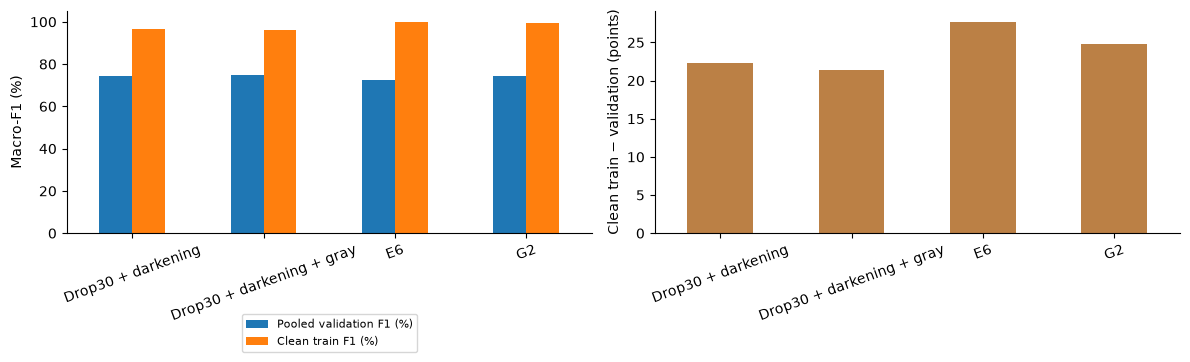

In [91]:
audit = pd.read_csv(
    REPO_DIR / 'reports/task3/gender_grayscale_result_20260905/verified_summary.csv',
        keep_default_na=False)
audit = audit.copy()
audit_values = audit.set_index('model')[['pooled_validation_f1', 'train_f1', 'gap']].mul(100)
audit_values.columns = ['Pooled validation F1 (%)','Clean train F1 (%)','Mean gap (points)']
display(audit_values.round(2))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
audit_values.iloc[:, :2].plot.bar(ax=axes[0], rot=20)
audit_values.iloc[:, 2].plot.bar(ax=axes[1], rot=20, color='#bb8045')
axes[0].set(ylabel='Macro-F1 (%)', ylim=(0,105), xlabel='')
axes[0].legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.34))
axes[1].set(ylabel='Clean train − validation (points)', xlabel='')
fig.tight_layout()
fig.savefig(FIGURES / "grayscale_result_20260905.png", dpi=150, bbox_inches="tight")
plt.show()

**Hypothesis and result.** Converting 10% of training inputs to grayscale asks the classifier to retain shape cues when colour disappears. Eighteen of nineteen checks pass, including the grayscale robustness improvement; the clean-gap check still fails. A 21.33-point gap remains. Colour dependence was one weakness, but removing it alone did not explain the generalisation error. The remaining class failures motivate a label and error audit.

## 31. Review the labels

Separate errors caused by the supplied category from errors against a clear product-name rule.

### 31.1 A new label basis must be named

Some product names clearly state a gender that conflicts with the supplied category.
The frozen `single_explicit_gender_cue_v1` rule creates a task-only label variant from those names.
Ambiguous names are left alone. Canonical labels are not overwritten.

This changes both training targets and development scoring labels. A jump from the previous table
therefore cannot be called a model-only gain. The raw-label results remain part of final judgement.
See [the label review](../reports/task3/gender_name_truth_deep_review_20260906/README.md).

### 31.2 Recompute the comparison from registered confusion counts

In [92]:
selected_stages = ['name']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
Name-corrected labels,gender,"[0, 4]",Name-corrected,13110,79.44,90.88


### 31.3 Plot class gains and losses on the same folds

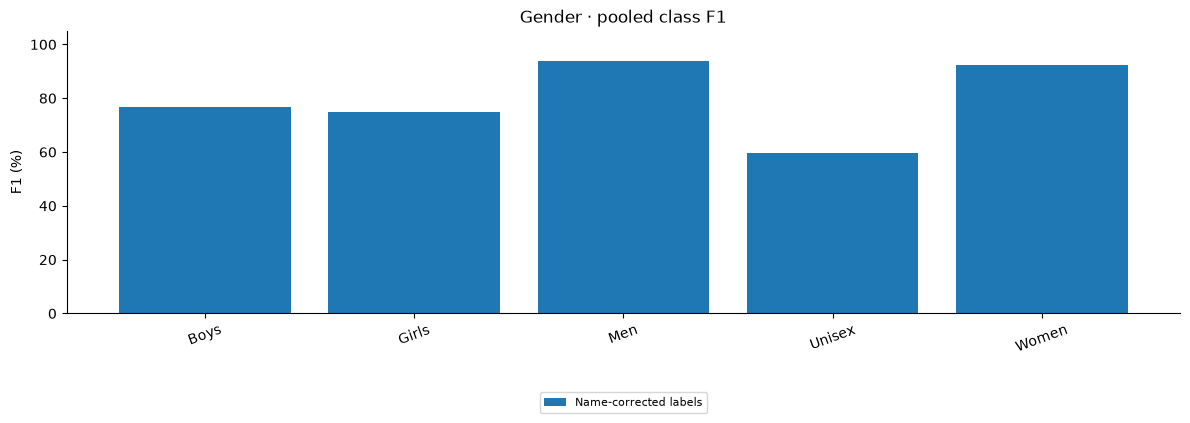

In [93]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "name_corrected_classes.png", dpi=150, bbox_inches="tight")
plt.show()

### 31.4 Compare models on the same corrected-label basis

,Pooled validation F1 (%),Clean train F1 (%),Mean gap (points)
model,,,
G2,75.12,94.41,19.32
E6,72.87,94.89,22.01
Gray10,75.49,91.84,16.35
NameTruth,79.44,96.80,17.38


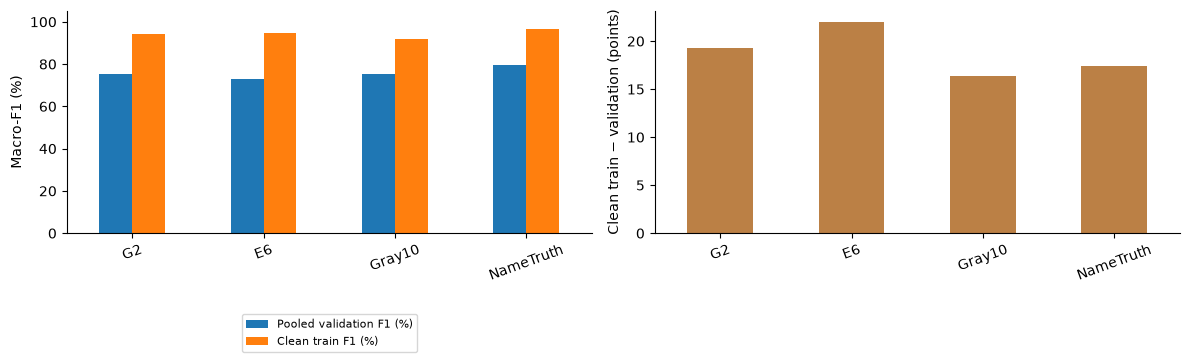

In [94]:
audit = pd.read_csv(
    REPO_DIR / 'reports/task3/gender_name_truth_result_20260906/verified_summary.csv',
        keep_default_na=False)
audit = audit.loc[audit.basis.eq('name_truth')].copy()
audit_values = audit.set_index('model')[['pooled_validation_f1', 'mean_train_f1',
    'mean_gap']].mul(100)
audit_values.columns = ['Pooled validation F1 (%)','Clean train F1 (%)','Mean gap (points)']
display(audit_values.round(2))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
audit_values.iloc[:, :2].plot.bar(ax=axes[0], rot=20)
audit_values.iloc[:, 2].plot.bar(ax=axes[1], rot=20, color='#bb8045')
axes[0].set(ylabel='Macro-F1 (%)', ylim=(0,105), xlabel='')
axes[0].legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.34))
axes[1].set(ylabel='Clean train − validation (points)', xlabel='')
fig.tight_layout()
fig.savefig(FIGURES / "name_truth_result_20260906.png", dpi=150, bbox_inches="tight")
plt.show()

**Why the label basis matters.** Re-scoring an old model against corrected labels changes the measured training gap even without retraining it. That accounting change cannot be claimed as a learned improvement. The fixed rule uses only one explicit gender cue; ambiguous names stay unchanged. The name-corrected training candidate is then compared against parents on that same basis. The label correction does not certify that every remaining label is visually knowable.

### 31.5 Locate the classes that contribute to the clean fit gap

model,G2,Gray10,NameTruth
class_name,,,
Boys,3.98,3.65,4.29
Girls,5.21,4.46,4.76
Men,1.10,0.93,0.95
Unisex,7.54,5.98,6.08
Women,1.49,1.33,1.30


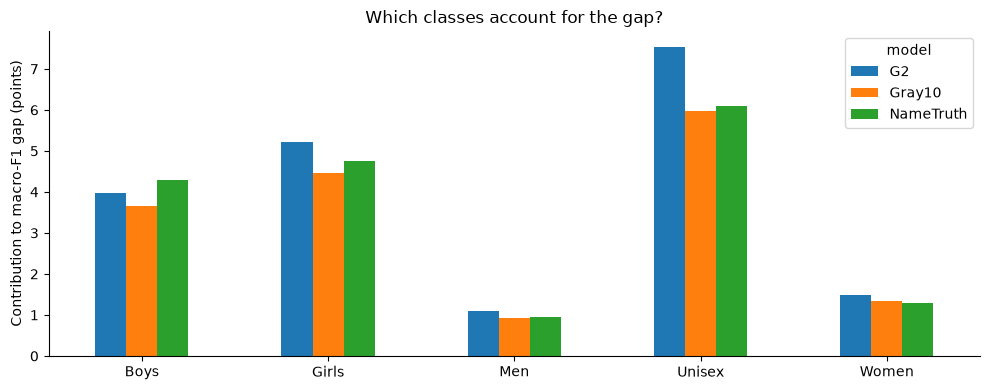

In [95]:
class_gaps=pd.read_csv(
    REPO_DIR / ('reports/task3/gender_name_truth_deep_rev'
        'iew_20260906/class_gap_contributions.csv'), keep_default_na=False)
gap_plot=class_gaps.groupby(['model','class_name']).contribution_to_macro_gap.mean().unstack(0).mul(100)
display(gap_plot.round(2))
fig,ax=plt.subplots(figsize=(10,4))
gap_plot.plot.bar(ax=ax,rot=0)
ax.set(ylabel='Contribution to macro-F1 gap (points)',xlabel='',
       title='Which classes account for the gap?')
fig.tight_layout()
fig.savefig(FIGURES / "name_truth_class_gap.png", dpi=150, bbox_inches="tight")
plt.show()

### 31.6 Inspect the remaining product-type errors

,true_label,articleType,validation_rows,validation_errors,error_rate,validation_families
0,Women,Sports Shoes,137,62,0.452555,132
1,Women,Watches,267,62,0.232210,198
2,Unisex,Casual Shoes,75,50,0.666667,68
3,Unisex,Sunglasses,48,40,0.833333,24
4,Men,Watches,449,36,0.080178,278
5,Boys,Tshirts,203,35,0.172414,122
6,Unisex,Watches,44,31,0.704545,40
7,Women,Casual Shoes,102,28,0.274510,92
8,Unisex,Backpacks,213,27,0.126761,151
9,Unisex,Flip Flops,47,27,0.574468,43


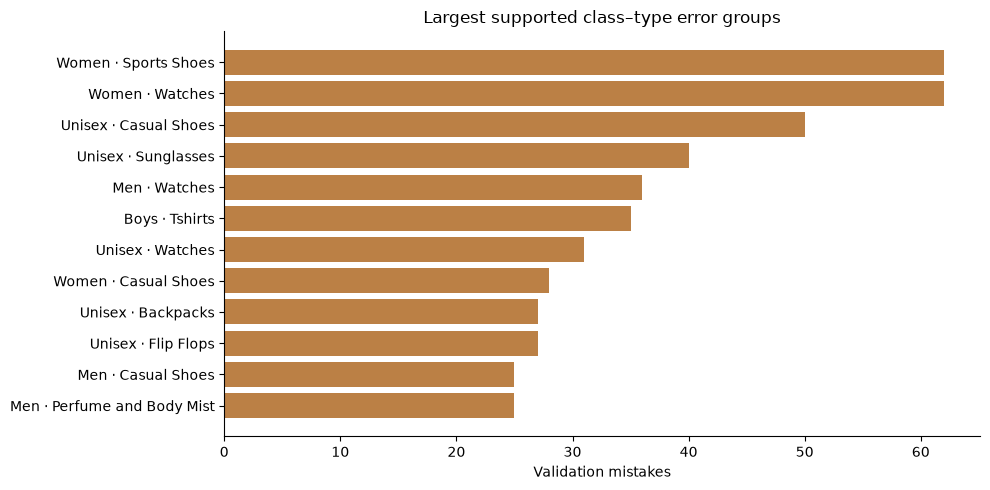

In [96]:
article_errors=pd.read_csv(
    REPO_DIR / ('reports/task3/gender_name_truth_deep_r'
        'eview_20260906/class_article_errors.csv'), keep_default_na=False)
error_slices=article_errors.loc[article_errors.validation_rows.ge(10)].nlargest(12,'validation_errors')
display(error_slices[['true_label','articleType','validation_rows','validation_errors','error_rate','validation_families']])
fig,ax=plt.subplots(figsize=(10,5))
ax.barh(error_slices.true_label+' · '+error_slices.articleType,
        error_slices.validation_errors,color='#bb8045')
ax.invert_yaxis()
ax.set(xlabel='Validation mistakes',title='Largest supported class–type error groups')
fig.tight_layout()
fig.savefig(FIGURES / "name_truth_article_errors.png", dpi=150, bbox_inches="tight")
plt.show()

Boys, Girls and Unisex contribute about 87.1% of the remaining macro gap. The model misses 337 of 707 Unisex products in the deep review. Watches, fragrances and shoes can have weak audience cues while their training types carry strong label priors. Good training fit on these groups and poor held-family performance is consistent with learning catalogue-specific associations.

The unchanged-label subset also improves (about 76.98% to 78.45% F1), with a barely positive uncertainty bound. That supports some real learning beyond score changes on relabelled rows. It is still one seed and two selected folds; class priors, family variation and label ambiguity remain competing explanations.

### 31.7 View the audited remaining errors

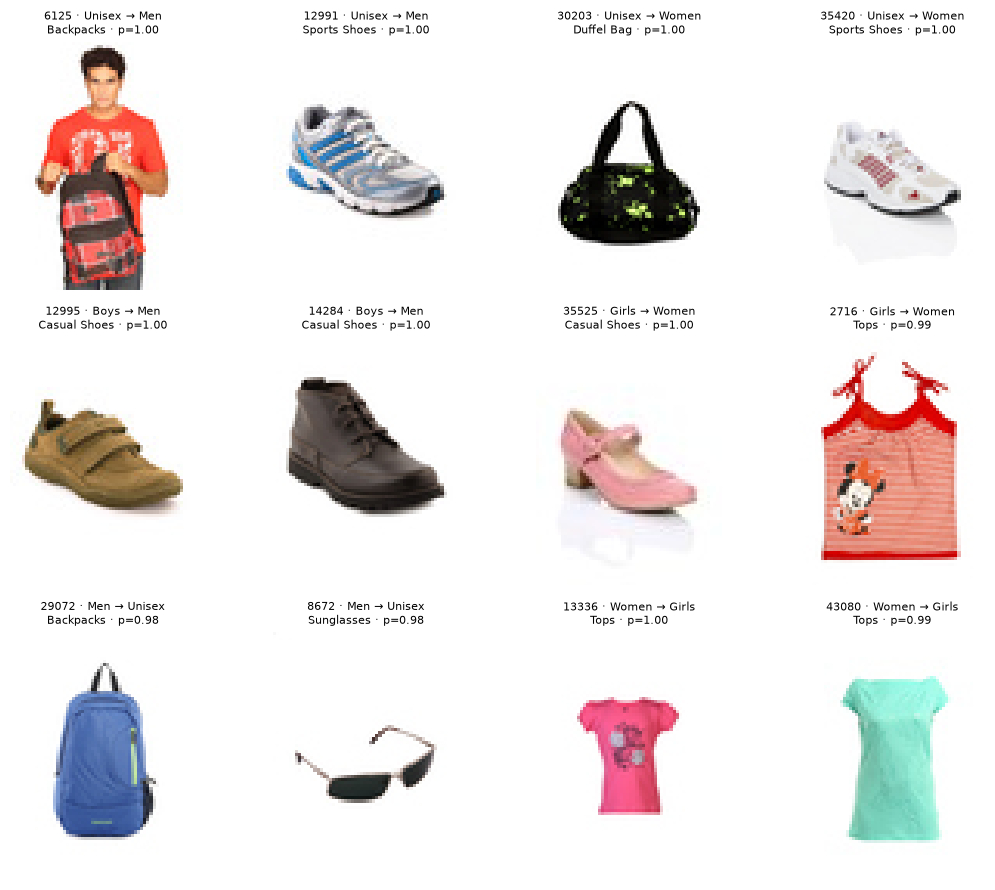

In [97]:
visual_cases=pd.read_csv(
    REPO_DIR / 'reports/task3/gender_name_truth_deep_review_20260906/visual_cases.csv',
        keep_default_na=False)
fig,axes=plt.subplots(3,4,figsize=(11,9))
for ax,row in zip(axes.flat,visual_cases.itertuples()):
    assert row.id in set(development.id)
    with Image.open(REPO_DIR/row.path) as image:
        ax.imshow(image.convert('RGB'))
    ax.set_title(f'{row.id} · {row.true_label} → {row.predicted_label}\n{
        row.articleType} · p={row.confidence:.2f}',fontsize=8)
    ax.axis('off')
fig.tight_layout()
fig.savefig(FIGURES / "name_truth_error_gallery.png", dpi=150, bbox_inches="tight")
plt.show()

## 32. Test article-group weights

Ask whether weak class–article groups need a stronger training signal.

### 32.1 Recompute the comparison from registered confusion counts

In [98]:
selected_stages = ['name', 'group']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
Name-corrected labels,gender,"[0, 4]",Name-corrected,13110,79.44,90.88
Article-group weights,gender,"[0, 4]",Name-corrected,13110,80.10,90.37


### 32.2 Plot class gains and losses on the same folds

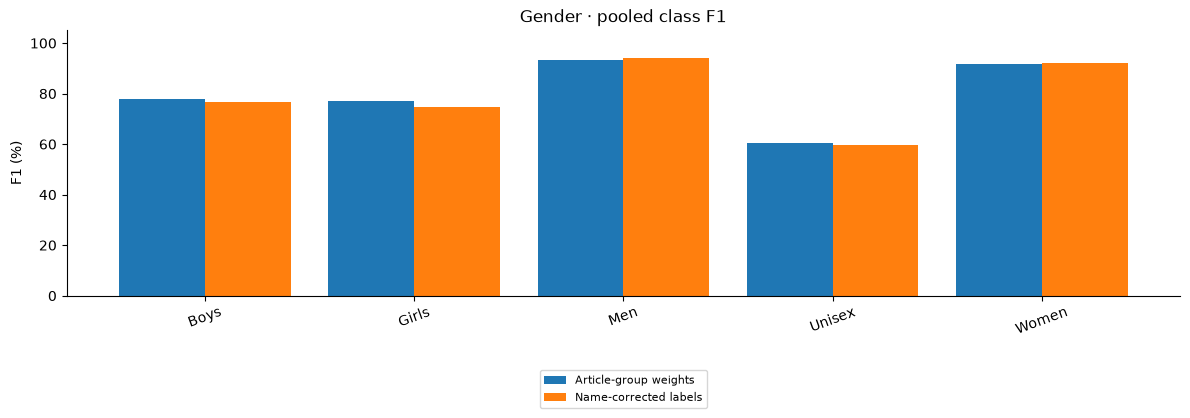

In [99]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "article_group_weights.png", dpi=150, bbox_inches="tight")
plt.show()

### 32.3 Compare group weighting on corrected labels

,Pooled validation F1 (%),Clean train F1 (%),Mean gap (points)
model,,,
G2,75.12,94.41,19.32
E6,72.87,94.89,22.01
Gray10,75.49,91.84,16.35
NameTruth,79.44,96.80,17.38
GroupWeight,80.10,97.00,16.93


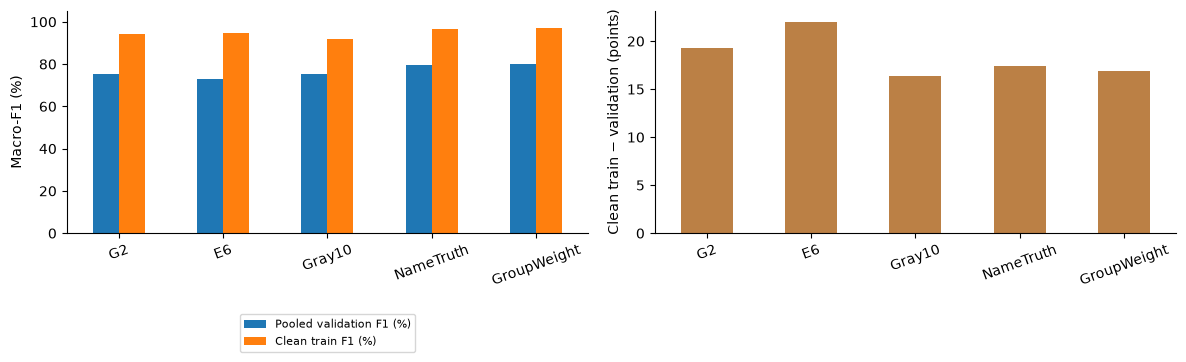

In [100]:
audit = pd.read_csv(
    REPO_DIR / 'reports/task3/gender_group_weight_result_20260906/verified_summary.csv',
        keep_default_na=False)
audit = audit.loc[audit.basis.eq('name_truth')].copy()
audit_values = audit.set_index('model')[['pooled_validation_f1', 'mean_train_f1',
    'mean_gap']].mul(100)
audit_values.columns = ['Pooled validation F1 (%)','Clean train F1 (%)','Mean gap (points)']
display(audit_values.round(2))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
audit_values.iloc[:, :2].plot.bar(ax=axes[0], rot=20)
audit_values.iloc[:, 2].plot.bar(ax=axes[1], rot=20, color='#bb8045')
axes[0].set(ylabel='Macro-F1 (%)', ylim=(0,105), xlabel='')
axes[0].legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.34))
axes[1].set(ylabel='Clean train − validation (points)', xlabel='')
fig.tight_layout()
fig.savefig(FIGURES / "group_weight_result_20260906.png", dpi=150, bbox_inches="tight")
plt.show()

**Result.** Eighteen of nineteen checks pass, but the gap requirement still fails. The matched F1 rises from 79.44% to 80.10% with an uncertain paired improvement. It fixes 218 errors and creates 284, so total mistakes increase by 66. Unisex recall rises from about 52.3% to 56.9%, while precision falls from 69.3% to 64.6%.

**Why we think it fell short.** Heavier weights make the model predict weak groups more often, which can rescue recall while producing false positives. That is the observed precision–recall trade. The intervention changes penalties, not the amount of independent visual evidence, so it does not directly resolve label ambiguity or family-specific memorisation. It is not stacked into the next candidate.

## 33. Add MixUp

Blend training examples and their targets to make memorisation of exact examples harder.

### 33.1 Recompute the comparison from registered confusion counts

In [101]:
selected_stages = ['name', 'mixup', 'mixup40']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
Name-corrected labels,gender,"[0, 4]",Name-corrected,13110,79.44,90.88
MixUp alpha 0.20,gender,"[0, 4]",Name-corrected,13110,80.89,90.91
MixUp alpha 0.40,gender,"[0, 4]",Name-corrected,13110,79.94,90.60


### 33.2 Plot class gains and losses on the same folds

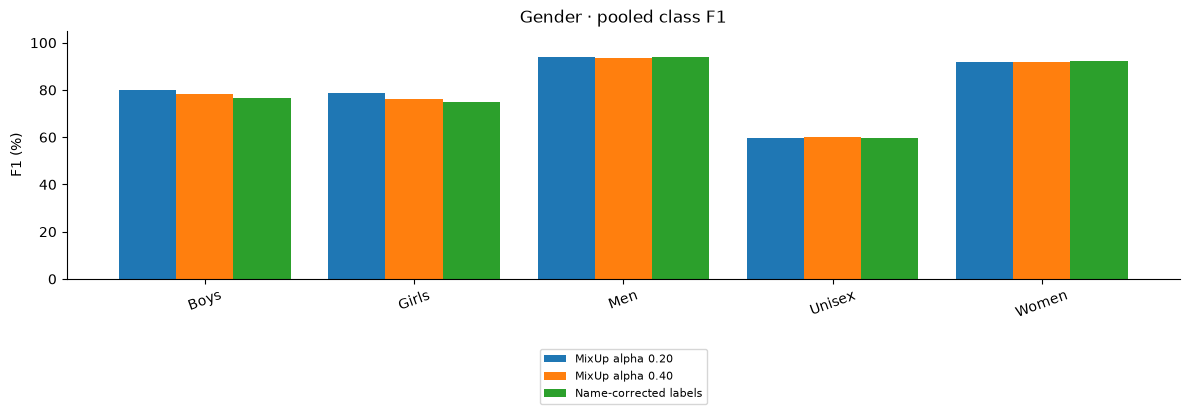

In [102]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "mixup_strengths.png", dpi=150, bbox_inches="tight")
plt.show()

### 33.3 Inspect the audited MixUp 0.20 improvement

,Pooled validation F1 (%),Clean train F1 (%),Mean gap (points)
model,,,
G2,75.12,94.41,19.32
E6,72.87,94.89,22.01
Gray10,75.49,91.84,16.35
NameTruth,79.44,96.80,17.38
MixUp,80.89,93.81,12.91


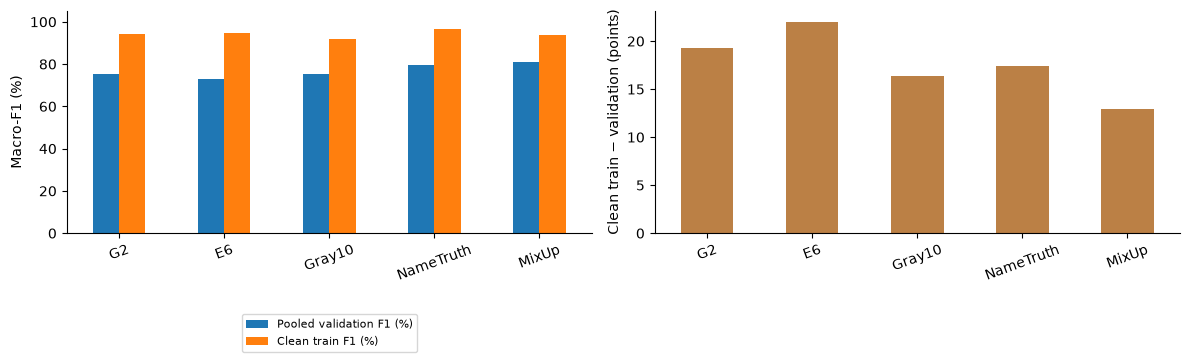

In [103]:
audit = pd.read_csv(
    REPO_DIR / 'reports/task3/gender_mixup_result_20260906/verified_summary.csv',
        keep_default_na=False)
audit = audit.loc[audit.basis.eq('name_truth')].copy()
audit_values = audit.set_index('model')[['pooled_validation_f1', 'mean_train_f1',
    'mean_gap']].mul(100)
audit_values.columns = ['Pooled validation F1 (%)','Clean train F1 (%)','Mean gap (points)']
display(audit_values.round(2))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
audit_values.iloc[:, :2].plot.bar(ax=axes[0], rot=20)
audit_values.iloc[:, 2].plot.bar(ax=axes[1], rot=20, color='#bb8045')
axes[0].set(ylabel='Macro-F1 (%)', ylim=(0,105), xlabel='')
axes[0].legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.34))
axes[1].set(ylabel='Clean train − validation (points)', xlabel='')
fig.tight_layout()
fig.savefig(FIGURES / "mixup_result_20260906.png", dpi=150, bbox_inches="tight")
plt.show()

**Hypothesis.** Soft targets on blended training examples discourage an overconfident boundary tightly fitted to each image. Blending occurs only inside the current training batch; validation remains clean.

**Result.** Alpha 0.20 passes all 19 checks: matched pooled F1 rises from 79.44% to 80.89%, and the clean gap falls from 17.38 to 12.91 points. Much of the F1 gain comes from Boys and Girls; the total error count changes little. Macro-F1 can rise because errors shift away from small classes even when accuracy barely moves.

**Why alpha 0.40 fails its intended test.** The stronger setting reaches about 79.87% in the matched IEEE audit and a 12.20-point mean gap. The gap improves by only 0.72 points rather than the required 2, fold 0's gap worsens, and Unisex does not improve. More blending can remove class-specific evidence as well as discourage memorisation. The saved registry score is about 79.94%; this small numeric-basis difference is kept explicit. Alpha 0.20 stays the parent.

## 34. Choose the SAM25 trade-off

Test a weight-perturbation update, then a separately fixed shorter training recipe.

### 34.1 Why SAM, then why 25 epochs?

SAM checks the loss after a small weight perturbation, then makes one update from that second gradient.
It keeps the same architecture and MixUp. The 30-epoch run and its learning curves led to a new fixed
25-epoch recipe, retaining the original 30-epoch cosine schedule. This choice used development evidence.
The final checkpoint is epoch 25, not a best epoch chosen afterwards.

### 34.2 Recompute the comparison from registered confusion counts

In [104]:
selected_stages = ['mixup', 'sam30', 'sam25']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
MixUp alpha 0.20,gender,"[0, 4]",Name-corrected,13110,80.89,90.91
SAM · 30 epochs,gender,"[0, 4]",Name-corrected,13110,79.43,90.56
SAM · 25 epochs,gender,"[0, 4]",Name-corrected,13110,79.86,90.50


### 34.3 Plot class gains and losses on the same folds

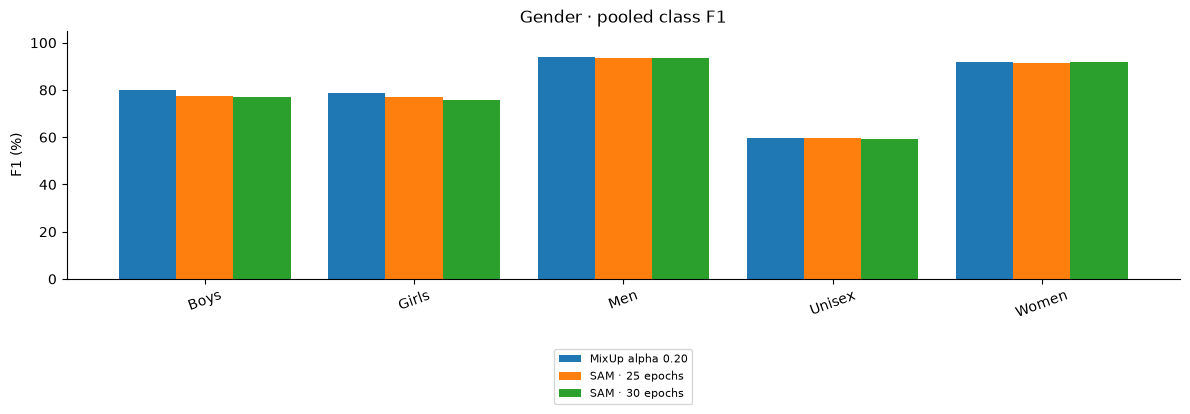

In [105]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "sam_screen_classes.png", dpi=150, bbox_inches="tight")
plt.show()

### 34.4 Inspect the SAM30 epoch diagnostic

,epoch,mean_train_f1,mean_validation_f1,mean_gap,pooled_validation_f1,unisex_correct,unisex_support,unisex_recall
0,10,0.7840,0.7322,0.0518,0.7327,252,707,0.3564
1,15,0.8352,0.7727,0.0625,0.7740,319,707,0.4512
2,20,0.8727,0.7796,0.0931,0.7804,330,707,0.4668
3,25,0.8980,0.7986,0.0994,0.7986,361,707,0.5106
4,30,0.9030,0.7943,0.1087,0.7943,356,707,0.5035


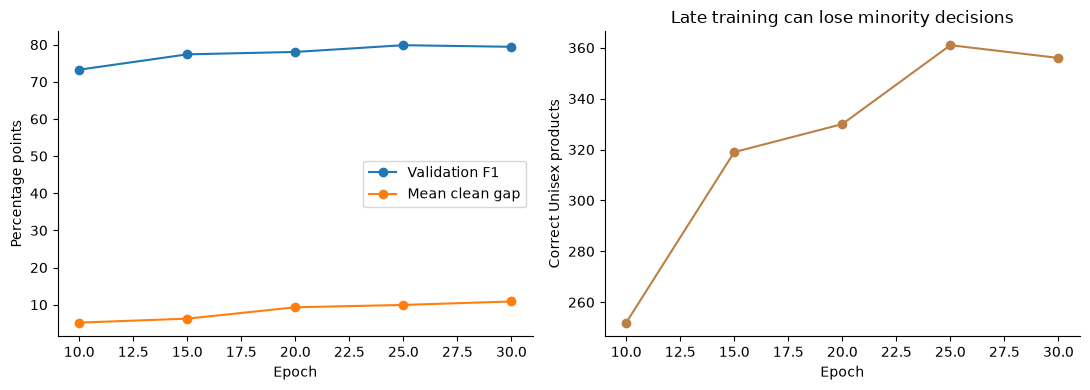

In [106]:
sam_epochs=pd.read_csv(
    REPO_DIR / 'reports/task3/gender_sam_result_20260906/epoch_summary.csv', keep_default_na=False)
display(sam_epochs.round(4))
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(sam_epochs.epoch,100*sam_epochs.pooled_validation_f1,marker='o',label='Validation F1')
axes[0].plot(sam_epochs.epoch,100*sam_epochs.mean_gap,marker='o',label='Mean clean gap')
axes[0].set(xlabel='Epoch',ylabel='Percentage points')
axes[0].legend()
axes[1].plot(sam_epochs.epoch,sam_epochs.unisex_correct,marker='o',color='#bb8045')
axes[1].set(xlabel='Epoch',ylabel='Correct Unisex products',
    title='Late training can lose minority decisions')
fig.tight_layout()
fig.savefig(FIGURES / "sam_epoch_diagnostic.png", dpi=150, bbox_inches="tight")
plt.show()

### 34.5 Read the matched screen trade-off

,model,validation_f1,mean_gap,mean_clean_train_f1,unisex_correct,unisex_support,errors,nll,ece_15
0,MixUp 0.2,0.8089,0.1291,0.9381,361,707,1192,0.2703,0.0132
1,SAM 30,0.7943,0.1086,0.9029,356,707,1237,0.2788,0.0203
2,SAM 25,0.7986,0.0993,0.8979,361,707,1245,0.2828,0.0279


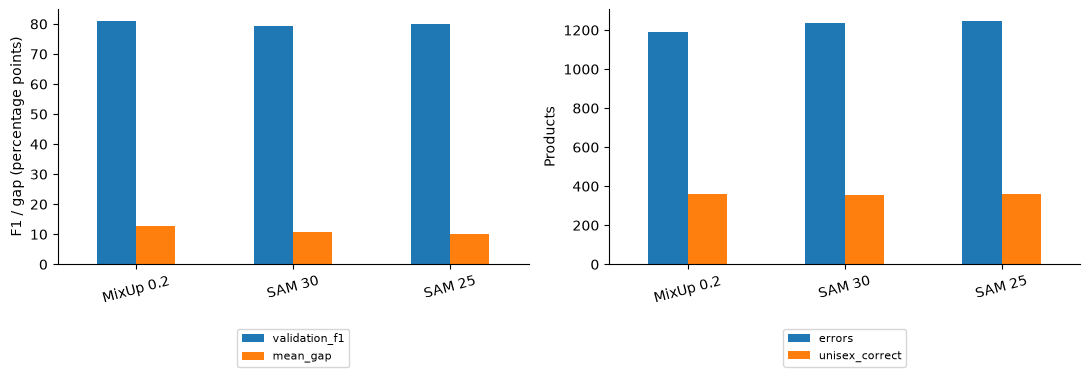

In [107]:
sam_screen=pd.read_csv(REPO_DIR / 'reports/task3/gender_sam25_result_20260906/comparison.csv',
    keep_default_na=False)
display(sam_screen.round(4))
fig,axes=plt.subplots(1,2,figsize=(11,4))
sam_screen.set_index('model')[['validation_f1','mean_gap']].mul(100).plot.bar(ax=axes[0],rot=15)
sam_screen.set_index('model')[['errors','unisex_correct']].plot.bar(ax=axes[1],rot=15)
axes[0].set(ylabel='F1 / gap (percentage points)',xlabel='')
axes[1].set(ylabel='Products',xlabel='')
for ax in axes:
    ax.legend(fontsize=8,loc='upper center',bbox_to_anchor=(.5,-.23))
fig.tight_layout()
fig.savefig(FIGURES / "sam25_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

SAM30 lowers the clean gap to 10.86 points but scores 79.43% F1. It loses five Unisex detections compared with MixUp (356 versus 361 of 707), causing one failed guard. The epoch diagnostic suggests a late minority-class cost. It is evidence for a new fixed-budget hypothesis, not permission to select the luckiest validation epoch.

SAM25 fixes 25 epochs before its separate run; it is **not a best epoch** extracted from SAM30. It reaches 79.86% F1 and a 9.93-point clean gap, with 361 Unisex detections and all 19 checks passing. It still makes 53 more total mistakes than MixUp and has lower class F1 across the five classes. We chose the smaller gap and passed safeguards, accepting lower screen F1. There is no universal rule that a gap below 10 points makes a model good; this is the recorded project trade-off.

## 35. Confirm the fixed recipe on five folds

Keep the selected recipe fixed and expose fresh-fold evidence separately.

### 35.1 Recompute the comparison from registered confusion counts

In [108]:
selected_stages = ['final']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
SAM25 · Five folds,gender,"[0, 1, 2, 3, 4]",Name-corrected,32773,79.74,90.46


### 35.2 Plot class gains and losses on the same folds

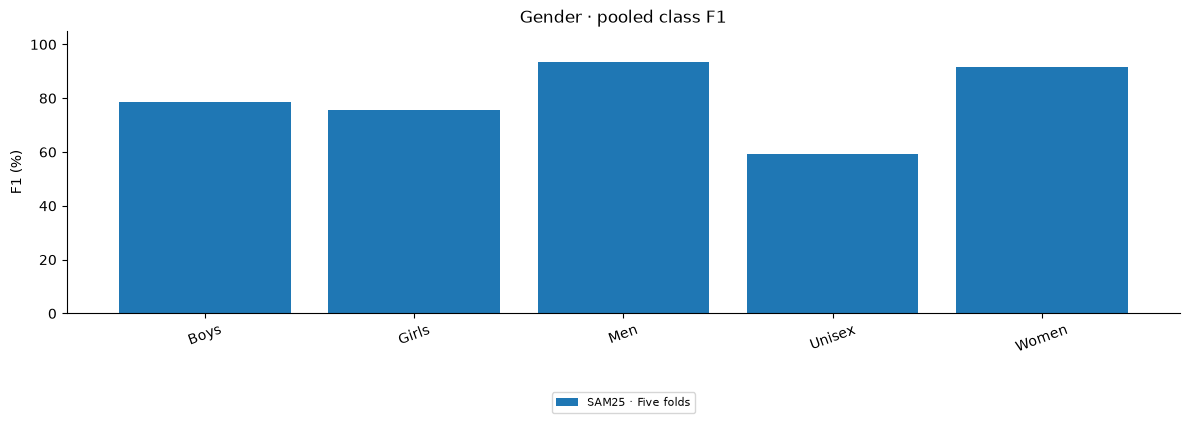

In [109]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "sam25_cv_classes.png", dpi=150, bbox_inches="tight")
plt.show()

### 35.3 Recompute the fold summary from the saved final evaluation

,train_f1,validation_f1,gap
fold,,,
0,89.32,79.81,9.52
1,89.32,79.36,9.96
2,90.16,78.60,11.56
3,90.21,80.83,9.38
4,90.27,79.92,10.35


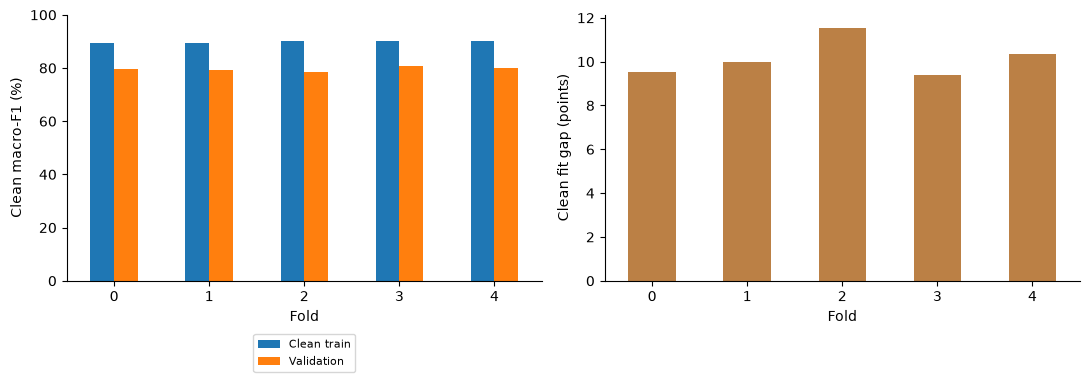

In [110]:
cv_summary=json.loads((
    REPO_DIR/'reports/task3/gender_sam25_cv_result_20260906/cv_summary.json').read_text())
fold_review=pd.read_csv(
    REPO_DIR / 'reports/task3/gender_sam25_cv_result_20260906/fold_review.csv',
        keep_default_na=False)
display(fold_review.set_index('fold')[['train_f1','validation_f1','gap']].mul(100).round(2))
fig,axes=plt.subplots(1,2,figsize=(11,4))
fold_review.set_index('fold')[['train_f1','validation_f1']].mul(100).plot.bar(ax=axes[0],rot=0)
fold_review.set_index('fold').gap.mul(100).plot.bar(ax=axes[1],rot=0,color='#bb8045')
axes[0].set(ylabel='Clean macro-F1 (%)',ylim=(0,100),xlabel='Fold')
axes[0].legend(['Clean train','Validation'],fontsize=8,loc='upper center',bbox_to_anchor=(.5,-.18))
axes[1].set(ylabel='Clean fit gap (points)',xlabel='Fold')
fig.tight_layout()
fig.savefig(FIGURES / "sam25_cv_folds.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding.** The audited IEEE result is 79.73% pooled macro-F1, with a 10.15-point mean clean gap. Fold scores range from 78.60% to 80.83%. These are five development folds, not five independent test sets.

**Finding.** The extra folds 1, 2, and 3 score 79.63% pooled F1. Unisex remains the weakest class. Confirmation supports a stable result, but does not erase repeated use of the development data.

### 35.4 Read each fold learning history

In [111]:
history_paths = ['reports/task3/gender_sam25_cv_result_20260906/fold0/history.csv',
    'reports/task3/gender_sam25_cv_result_20260906/fold1/history.csv',
        'reports/task3/gender_sam25_cv_result_20260906/fold2/history.csv',
            'reports/task3/gender_sam25_cv_result_20260906/fold3/history.csv',
                'reports/task3/gender_sam25_cv_result_20260906/fold4/history.csv']
final_histories=[]
for fold,path in enumerate(history_paths):
    rows=pd.read_csv(REPO_DIR / str(path).replace('reports/task3_', 'reports/task3/', 1))
    rows['fold']=fold
    final_histories.append(rows)
final_history=pd.concat(final_histories,ignore_index=True)
assert final_history.fold.nunique()==5

### 35.5 Plot all five final training histories

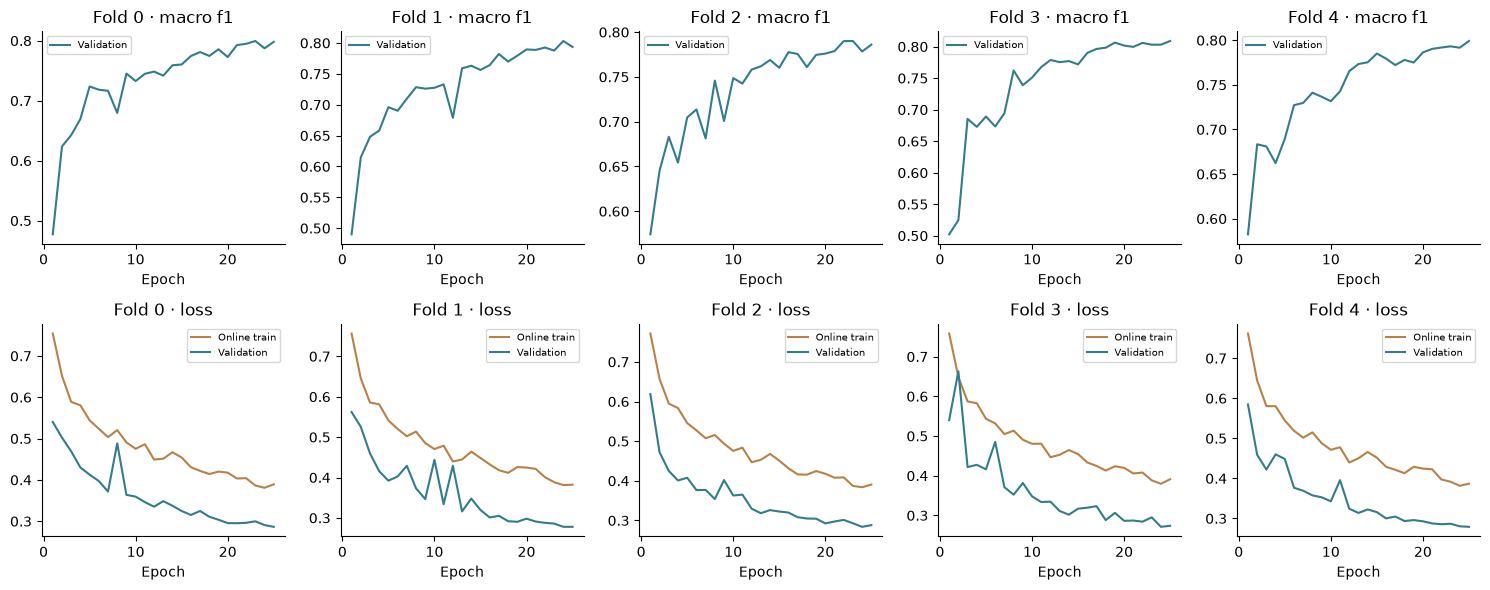

In [112]:
fig,axes=plt.subplots(2,5,figsize=(15,6))
for fold in range(5):
    rows=final_history.loc[final_history.fold.eq(fold)]
    for row,metric in enumerate(['macro_f1','loss']):
        if rows['train_'+metric].notna().any():
            axes[row,fold].plot(rows.epoch,rows['train_'+metric],label='Online train',
                color='#bb8045')
        axes[row,fold].plot(rows.epoch,rows['validation_'+metric],label='Validation',
            color='#327d8b')
        axes[row,fold].set(title=f'Fold {fold} · {metric.replace("_"," ")}',xlabel='Epoch')
        axes[row,fold].legend(fontsize=7)
fig.tight_layout()
fig.savefig(FIGURES / "sam25_full_curves.png", dpi=150, bbox_inches="tight")
plt.show()

The registry training-runtime result is 79.74% pooled F1; the matched IEEE audit is 79.73%. Fold F1 ranges from 78.60% to 80.83%, with a 10.15-point mean clean gap. Fresh folds 1–3 score 79.63% pooled. The history uses runtime values and online augmented training; the clean gap above uses saved evaluation-mode predictions. Loss generally improves toward the end, but a gap remains. Stable folds do not remove the selection bias from many development trials.

The MixUp histories deliberately leave online training macro-F1 undefined for mixed targets. The top row therefore shows validation F1 only. The bottom row shows both training and validation losses. Clean training F1 comes from the separate evaluation-mode audit above; no missing training curve is filled in.

## 36. Freeze the full prediction recipe

Identify the precise saved models, transforms and ensemble rule.

### 36.1 Read and verify the selected model settings

In [113]:
model_manifest=json.loads((
    REPO_DIR/'reports/task3/gender_sam25_cv_result_20260906/model_manifest.json').read_text())
final_config=json.loads((
    REPO_DIR/'reports/task3/gender_sam25_cv_result_20260906/fold0/config.json').read_text())
for fold in model_manifest['folds']:
    assert registry.loc[fold['run_id'],'checkpoint_sha256']==fold['files']['final_epoch.pt'][
        'sha256']
child=final_config['child_experiment']
recipe={name:final_config[name] for name in ['channels','seed','parameter_count',
    'optimizer_name','learning_rate','weight_decay','batch_size']}
recipe.update({name:child[name] for name in ['model_family','training_epochs','cosine_t_max',
    'classifier_dropout','training_augmentation']})
recipe['MixUp alpha']=child['mixup_policy']['alpha']
recipe['SAM rho']=child['sam_policy']['rho']
recipe['Label rule']=child['gender_label_variant']['variant_id']
recipe[
    'New-image prediction']=('Equal mean of five softmax vectors, each'
        ' with its own training-fold normalization')
with pd.option_context('display.max_colwidth',None):
    display(pd.Series(recipe,name='Frozen value').to_frame())

,Frozen value
channels,"[32, 64, 128, 256]"
seed,2753
parameter_count,390181
optimizer_name,AdamW
learning_rate,0.001
weight_decay,0.0001
batch_size,128
model_family,task3_small_cnn_gem_p3
training_epochs,25
cosine_t_max,30


**Finding.** Decision 0020 freezes the five saved checkpoints and each fold’s normalization. New images use their equal probability average. This is a five-model ensemble, not a single all-development refit.

### 36.2 What the freeze covers

Use all five checkpoint hashes from the [model manifest](../reports/task3/gender_sam25_cv_result_20260906/model_manifest.json).
Never use the five-model average for OOF scores: four of those models have trained on each development row.
The fold ensemble is the explicit gender-only amendment to decision 0014. Usage is not selected here.

## 37. Read the reserved holdout results

Evaluate the fixed Gender ensemble on the reserved labelled part of the teacher training data. The teacher did not supply test labels. This Gender section retains its holdout scope; the later Usage section labels the separate recovered-reference test comparison explicitly.

### 37.1 Read primary and separately labelled holdout metrics

In [114]:
holdout=pd.read_csv(REPO_DIR / 'reports/task3/main_report_20260906/holdout_summary.csv',
    keep_default_na=False)
holdout_classes=pd.read_csv(
    REPO_DIR / 'reports/task3/main_report_20260906/holdout_per_class.csv', keep_default_na=False)
assert holdout.scope.eq('holdout').all() and holdout_classes.scope.eq('holdout').all()
table=holdout.set_index('label_basis')[['images','accuracy','macro_f1','ece_15']].copy()
table[['accuracy','macro_f1','ece_15']]*=100
display(table.rename(columns={'accuracy':'Accuracy (%)','macro_f1':'Macro-F1 (%)',
    'ece_15':'Calibration error (%)'}).round(2))

,images,Accuracy (%),Macro-F1 (%),Calibration error (%)
label_basis,,,,
primary,5778,89.82,77.14,2.35
fixed_name_rule_diagnostic,5778,90.41,80.45,2.83


**Finding.** The reserved holdout contains 5,778 images. The five-model ensemble reaches
89.82% accuracy and 77.14% macro-F1 against their original labels. Macro-F1 gives each class
equal weight, so it exposes mistakes hidden by the larger adult classes.

**Finding.** Corrected-label holdout macro-F1 is 80.45%, while original-label holdout F1
is 77.14%. Original-label CV is 75.33%, versus 79.73% on corrected labels. Different label bases
must not be blended into one improvement claim.

## 38. Explain the remaining failures

Read precision, recall and confusion counts before judging practical usefulness.

### 38.1 Plot the reserved holdout class results

,support,precision,recall,f1
class_name,,,,
Boys,120,0.6838,0.7750,0.7266
Girls,95,0.6887,0.7684,0.7264
Men,3130,0.9167,0.9463,0.9313
Unisex,311,0.7087,0.4695,0.5648
Women,2122,0.9128,0.9029,0.9078


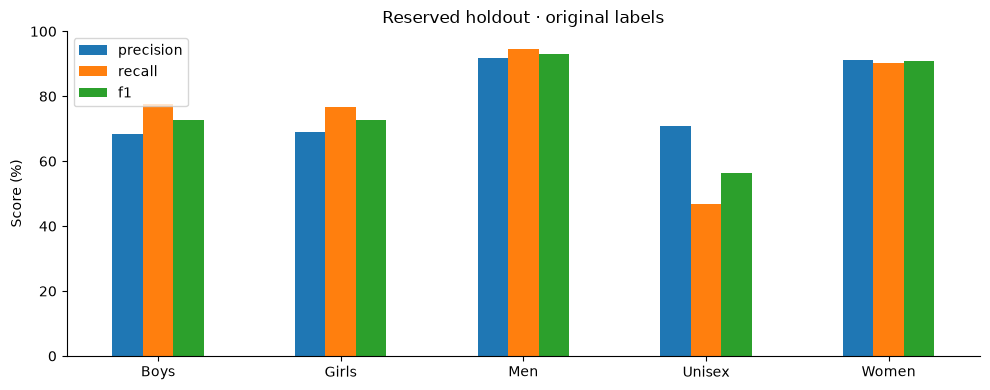

In [115]:
primary_classes=holdout_classes.loc[holdout_classes.label_basis.eq('primary')].set_index(
    'class_name')
display(primary_classes[['support','precision','recall','f1']].round(4))
fig,ax=plt.subplots(figsize=(10,4))
primary_classes[['precision','recall','f1']].mul(100).plot.bar(ax=ax,rot=0)
ax.set(ylabel='Score (%)',ylim=(0,100),xlabel='',title='Reserved holdout · original labels')
fig.tight_layout()
fig.savefig(FIGURES / "holdout_class_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

### 38.2 Plot the held-out confusion counts

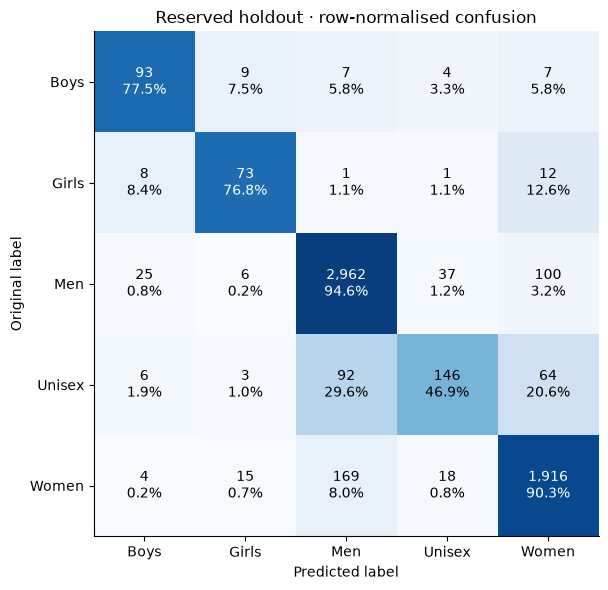

In [116]:
confusion=pd.read_csv(
    REPO_DIR / 'reports/task3/main_report_20260906/holdout_confusion_matrix.csv',
        keep_default_na=False)
counts=confusion.set_index('actual')
proportions=counts.div(counts.sum(axis=1),axis=0)
fig,ax=plt.subplots(figsize=(7,6))
ax.imshow(proportions,cmap='Blues',vmin=0,vmax=1)
ax.set(xticks=range(5),xticklabels=counts.columns,yticks=range(5),yticklabels=counts.index,
       xlabel='Predicted label',ylabel='Original label',
           title='Reserved holdout · row-normalised confusion')
for i,j in np.ndindex(counts.shape):
    ax.text(j,i,f'{counts.iloc[i,j]:,}\n{proportions.iloc[i,j]:.1%}',ha='center',va='center',
            color='white' if proportions.iloc[i,j]>.55 else 'black')
fig.tight_layout()
fig.savefig(FIGURES / "holdout_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding.** The ensemble detects 146 of 311 Unisex products, a recall of 46.95%.
It mistakes 92 for Men and 64 for Women. Boys and Girls have only 120 and 95 holdout images,
so their class scores have less support than the adult classes.

### 38.3 Practical limits

Gender here is the catalogue’s intended audience label, not a claim about a person’s identity.
Style alone often does not identify a single audience. A product image can also lack age or size clues.
Small shifts remain the largest tested corruption loss on development folds (about 4.20 F1 points on average).
Using five models costs more inference work. The reserved holdout has now been evaluated; later
changes cannot treat it as a fresh selection set.

## 39. Usage: what the original experiments established

Keep the nine Usage labels and teacher folds fixed. Read the completed five-fold experiments first, then the separate two-fold screens.

### 39.1 Recompute the comparison from registered confusion counts

In [117]:
selected_stages = ['usage1', 'usage2', 'usage3', 'usage4', 'usage5', 'usage6', 'usage7',
    'usage8', 'usage9']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
Usage E1 · Baseline,usage,"[0, 1, 2, 3, 4]",Original,32772,37.38,89.30
Usage E2 · Class weights,usage,"[0, 1, 2, 3, 4]",Original,32772,40.82,89.15
Usage E3 · Dropout 0.20,usage,"[0, 1, 2, 3, 4]",Original,32772,41.61,89.17
Usage E4 · TinyResNet,usage,"[0, 1, 2, 3, 4]",Original,32772,38.78,87.99
Usage E5 · Label smoothing,usage,"[0, 1, 2, 3, 4]",Original,32772,40.49,89.27
Usage E6 · Focal loss,usage,"[0, 1, 2, 3, 4]",Original,32772,40.94,88.82
Usage E7 · TinyConvNeXt,usage,"[0, 1, 2, 3, 4]",Original,32772,34.51,85.22
Usage E8 · Translation,usage,"[0, 1, 2, 3, 4]",Original,32772,41.94,88.85
Usage E9 · Exception balance,usage,"[0, 1, 2, 3, 4]",Original,32772,39.55,83.70


### 39.2 Compare every class across the experiment sequence

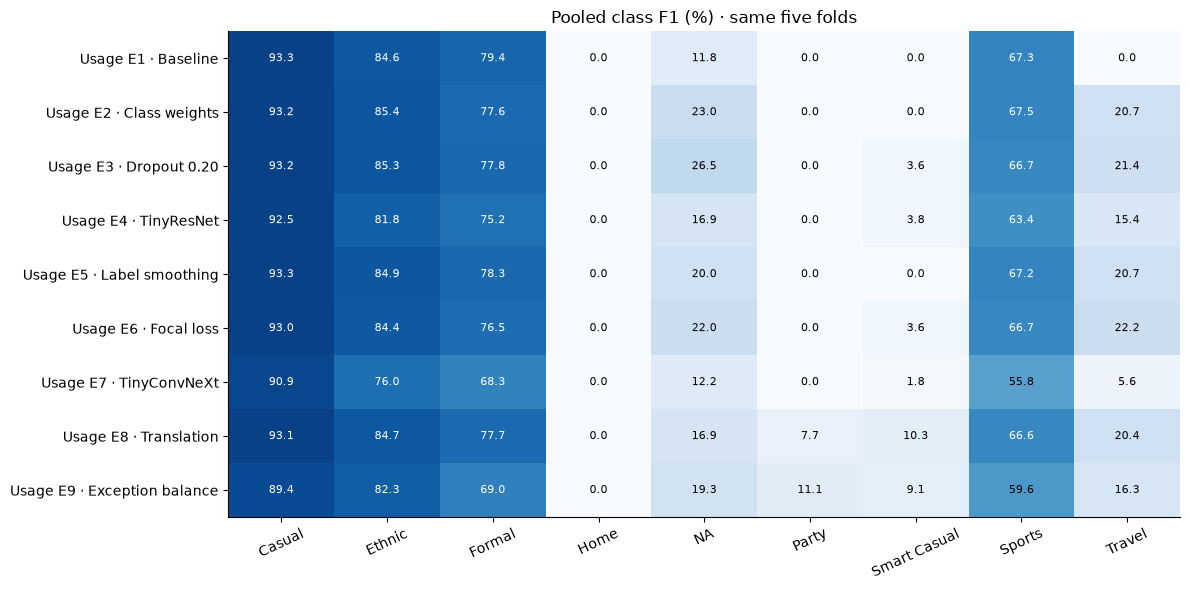

In [118]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
score_grid = class_scores.pivot(index='Stage', columns='Class', values='F1 (%)')
score_grid = score_grid.reindex([evidence_lock['stages'][key]['label'] for key in selected_stages])
fig, ax = plt.subplots(figsize=(12,6))
ax.imshow(score_grid, cmap='Blues', vmin=0, vmax=100, aspect='auto')
ax.set(xticks=range(len(score_grid.columns)), xticklabels=score_grid.columns,
       yticks=range(len(score_grid)), yticklabels=score_grid.index,
           title='Pooled class F1 (%) · same five folds')
ax.tick_params(axis='x', rotation=25)
for i,j in np.ndindex(score_grid.shape):
    value=score_grid.iloc[i,j]
    ax.text(j,i,f'{value:.1f}',ha='center',va='center',fontsize=8,
        color='white' if value>60 else 'black')
fig.tight_layout()
fig.savefig(FIGURES / "usage_all_experiments.png", dpi=150, bbox_inches="tight")
plt.show()

### 39.3 Recompute the comparison from registered confusion counts

In [119]:
selected_stages = ['usage204', 'hog_u']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
Usage E2 · Class weights,usage,"[0, 4]",Original,13110,40.73,89.06
Usage U2 · HOG SVM,usage,"[0, 4]",Original,13110,36.29,86.57


### 39.4 Plot class gains and losses on the same folds

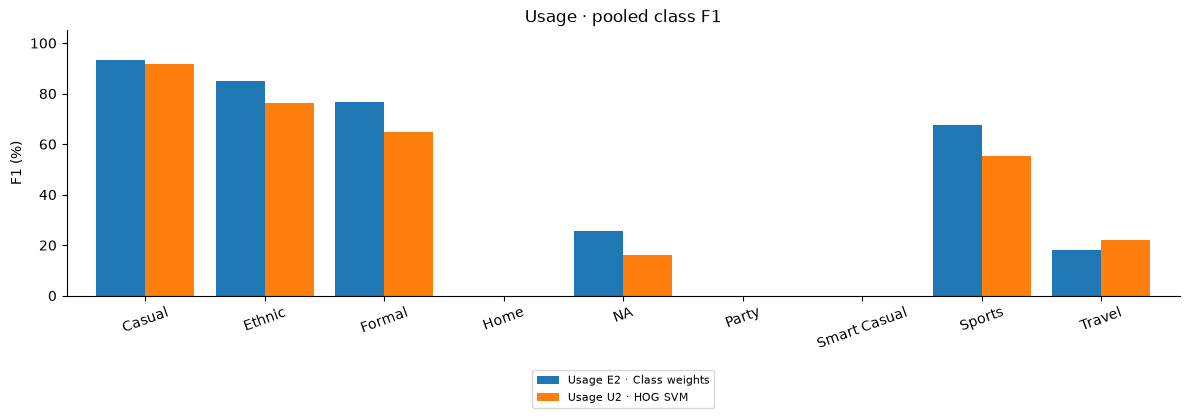

In [120]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "usage_u2_calibrated.png", dpi=150, bbox_inches="tight")
plt.show()

**U2 hypothesis and failure.** Full-RGB HOG plus a linear SVM tests the promising fixed-feature probe on a full, naturally imbalanced population. The saved calibrated model scores 36.29% F1 against E2's matched 40.73%. The paired change is −4.44 points, with a family-bootstrap interval from −6.89 to −2.44 points; both admission routes fail. All solvers converged, so an unfinished optimiser is not the explanation.

Raw SVM margins would score 40.59%, but the saved calibrated probabilities score 36.29%. Two of eight Party calibration sigmoids have reversed slopes, each based on only two or three positives from one or two families. This directly shows that the fitted calibration step damaged the saved decisions. The raw-margin readout still predicts no Party or Smart Casual and is a diagnostic, not a replacement accepted model. Base SVM train/inner-validation gaps remain about 46–47 points; the smaller ensemble training gap masks different exposures to fitting and calibration.

The earlier balanced probe also used a different estimator and population. Its stronger score is not a contradiction and cannot isolate one cause. Scarce calibration examples, representation differences and fewer base-fitting folds all matter.

**U3 hypothesis and failure.** Two-stage learning first fits ordinary image features, then freezes them and rebalances only the classifier. The saved two-fold artifact audit gives 40.34% F1, below E2's 40.73%; NLL worsens 37.8% and Brier 7.1%. Stage B learns small training classes better but makes 23 Party guesses with none correct. Travel and brightening guards fail. At that audit, fold 4's registry row still said running despite completed artifacts, so U3 is excluded from registry-based candidate tables. These artifact-only results do not justify another fold or a final choice.

**Other diagnostics.** An equal E2/E3/E8 probability average reaches 42.31% on five-fold clean predictions, but Party F1 stays zero and complete corruption evidence is missing. It was not accepted. A blanket rare-class prior boost helps E2 and harms E3/E8 while worsening NLL in all three. These are evidence that neither averaging nor pushing rare probabilities up automatically fixes the weak ranking of rare examples.

The original teacher sequence tested class weights, dropout, residual and ConvNeXt networks, label smoothing, focal loss, translation and exception balancing. Sections 9–19 give their curves, class results and decisions. E8 led the nine completed individual experiments on macro-F1; E1 led on accuracy. E10 changed Gender only.

The later tests asked whether new rare-class examples could help where changes to the model had failed. ADR 0018 admitted 120 outside images. ADR 0019 kept those and added 567 more. Teacher folds and the original search gallery stayed fixed. The completed results follow below.

### 39.5 Audit the admitted rare-Usage additions

Version,teacher_plus_rare_usage_20260906,teacher_plus_rare_usage_v2_20260906
Usage,,
Home,16,136
Party,97,224
Smart Casual,6,162
Travel,1,165


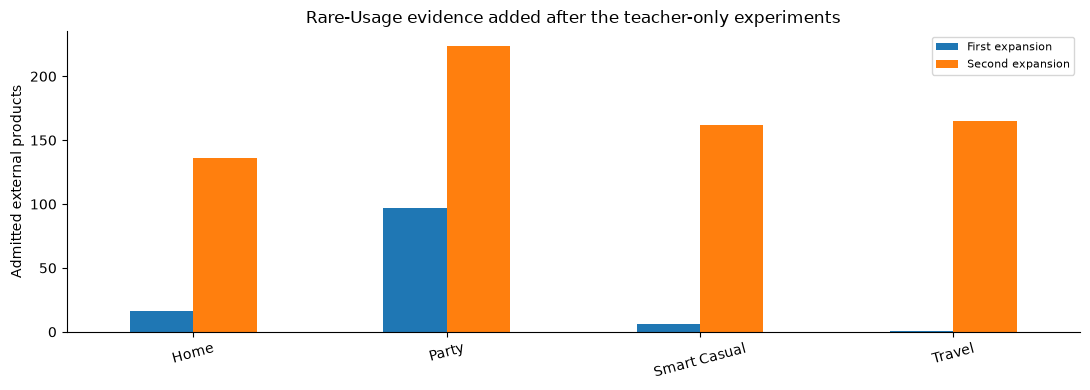

In [121]:
expanded_paths = ['data/processed/teacher_plus_rare_usage_20260906/splits.csv',
                  'data/processed/teacher_plus_rare_usage_v2_20260906/splits.csv']
intake_rows=[]
teacher_ids=set(splits.id.astype(str))
for path in expanded_paths:
    expanded=pd.read_csv(REPO_DIR/path,keep_default_na=False,low_memory=False)
    external=expanded.loc[~expanded.id.astype(str).isin(teacher_ids)]
    for label,count in external.usage.value_counts().items():
        intake_rows.append([Path(path).parent.name,label,count])
intake=pd.DataFrame(intake_rows,columns=['Version','Usage','Added products'])
display(intake.pivot(index='Usage',columns='Version',values='Added products').fillna(0).astype(int))
fig,ax=plt.subplots(figsize=(11,4))
intake.pivot(index='Usage',columns='Version',values='Added products').fillna(0).plot.bar(
    ax=ax,rot=15)
ax.set(ylabel='Admitted external products',xlabel='',
    title='Rare-Usage evidence added after the teacher-only experiments')
ax.legend(['First expansion','Second expansion'],fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "usage_expansion_intake.png", dpi=150, bbox_inches="tight")
plt.show()

**Why add data?** More independent families can give a small class more examples to learn from. Yet outside retail photos may have different products, backgrounds or label meanings. The fair test is performance on the same teacher rows. A better score on a mixture of teacher and outside images does not establish that benefit. Literal `NA` remains a class; the one blank target remains excluded.

## 40. Usage: did more rare-class images help?

The hypothesis was simple: teach the rare labels using more examples, while retaining the teacher folds and E8 recipe. The tables below read pinned, completed evidence. Original model scores come from the registered fold confusion counts. Expanded runs use their saved teacher-only prediction audits because their registry totals also include outside images.

### 40.1 Verify the final evidence and compare the same five teacher folds

In [122]:
usage_lock = json.loads((USAGE_FINAL/'evidence_lock.json').read_text())
usage_files = usage_lock['sources']
for relative, expected in usage_lock['files'].items():
    saved = REPO_DIR / relative.replace('reports/task3_', 'reports/task3/', 1)
    assert hashlib.sha256(saved.read_bytes()).hexdigest() == expected, relative
usage120 = json.loads((REPO_DIR/usage_files['expanded120_confusions']).read_text())
usage687 = json.loads((REPO_DIR/usage_files['expanded687_summary']).read_text())
usage_dev_rows = []
for label, key in [('E1', 'usage1'), ('E8', 'usage8')]:
    rows = registry.loc[evidence_lock['stages'][key]['run_ids']]
    assert rows.status.eq('complete').all() and sorted(rows.validation_fold) == list(range(5))
    matrices = [json.loads(value)['confusion_matrix'] for value in rows.metrics_json]
    matrix = np.sum(matrices, axis=0)
    denominator = matrix.sum(axis=0) + matrix.sum(axis=1)
    f1 = np.divide(2*matrix.diagonal(), denominator,
                   out=np.zeros(9), where=denominator>0).mean()
    usage_dev_rows.append([label, int(matrix.sum()), np.trace(matrix)/matrix.sum(), f1])
for label, result in [('E8 +120', usage120['teacher']),
                      ('E8 +687', usage687['sources']['teacher']['metrics'])]:
    matrix = np.asarray(result['confusion_matrix'])
    usage_dev_rows.append([label, int(matrix.sum()), result['accuracy'], result['macro_f1']])
usage_development_scores = pd.DataFrame(usage_dev_rows,
    columns=['Model','Images','Accuracy','Macro-F1']).set_index('Model')
assert usage_development_scores.Images.eq(32772).all()
display(usage_development_scores.round(6))

,Images,Accuracy,Macro-F1
Model,,,
E1,32772,0.892988,0.373756
E8,32772,0.888533,0.419393
E8 +120,32772,0.887495,0.408634
E8 +687,32772,0.895093,0.409277


**Result.** E1 scores 89.30% accuracy and 0.373756 macro-F1. E8 scores 88.85% and 0.419393. Adding 120 images lowers teacher macro-F1 to 0.408634; adding 687 gives 0.409277. The larger set raises teacher accuracy to 89.51%, so E1 is not the accuracy winner of this expanded development comparison.

The 687-image change against original E8 has a family-resampling 95% interval of −0.0348 to +0.0144 F1. It includes zero. There is no demonstrated gain; the observed decrease is not proof that adding data always hurts. One seed and repeated use of these folds limit the claim.

### 40.2 Check whether learning transfers between sources

cohort,Newest 567 images,Teacher
class_name,,
Home,116 / 120,0 / 1
Party,125 / 127,0 / 12
Smart Casual,147 / 156,0 / 47
Travel,137 / 164,5 / 22


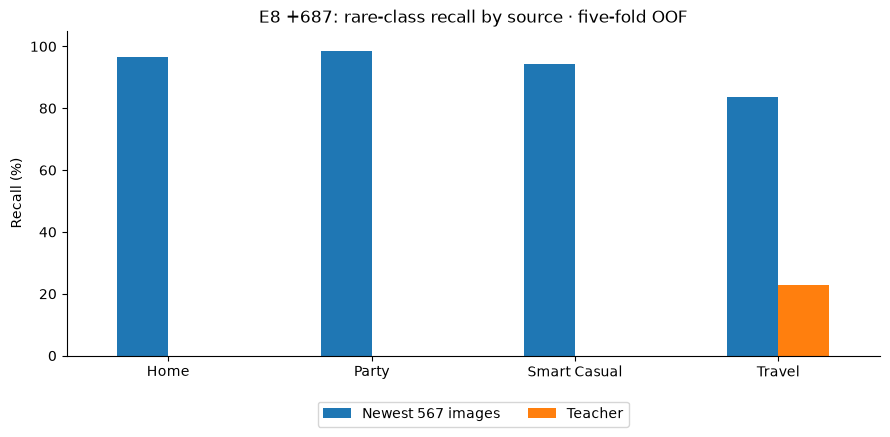

In [123]:
source_scores = pd.read_csv(REPO_DIR/usage_files['source_classes'], keep_default_na=False)
rare_names = ['Home','Party','Smart Casual','Travel']
source_view = source_scores.loc[source_scores.class_name.isin(rare_names) &
    source_scores.cohort.isin(['teacher','new_added'])].copy()
source_view['Correct / images'] = (source_view.correct.astype(str) +
                                  ' / ' + source_view.support.astype(str))
source_labels = {'teacher':'Teacher','new_added':'Newest 567 images'}
display(source_view.pivot(index='class_name', columns='cohort',
    values='Correct / images').reindex(rare_names).rename(columns=source_labels))
fig, ax = plt.subplots(figsize=(9,4.5))
source_view.pivot(index='class_name', columns='cohort', values='recall').reindex(
    rare_names).rename(columns=source_labels).mul(100).plot.bar(ax=ax, rot=0)
ax.set(xlabel='', ylabel='Recall (%)', ylim=(0,105),
       title='E8 +687: rare-class recall by source · five-fold OOF')
ax.legend(title='', loc='upper center', bbox_to_anchor=(.5,-.12), ncol=2)
fig.tight_layout()
fig.savefig(FIGURES/'usage_source_transfer.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding.** The 687-image model detects 125/127 new-source Party and 147/156 new-source Smart Casual images. On the teacher rows, it detects 0/12 Party and 0/47 Smart Casual. It learns the outside examples, but that success does not carry to these teacher classes. The earlier 120-image model also missed all teacher Party cases.

The mixed-source F1 of 0.7567 measures a changed class and source mix. It cannot replace the teacher-only score of 0.4093. Coverage was uneven: the teacher Smart Casual class contains 18 watches, while the 162 added Smart Casual images contain none. Product types also overlap: a dress can be Casual or Party. These are useful clues, not proof of wrong labels or a faulty architecture.

## 41. Usage: test regularisation and photo replacements

MixUp blends training images and their labels. SAM tries to make fitting less sensitive to small weight changes. The v2 trial added both to E8 with 687 outside images. The v3 trial then replaced 130 outside photos to fill reviewed coverage gaps, keeping class totals and teacher folds fixed. Both used fresh scratch weights and a fixed 30-epoch budget.

### 41.1 Compare only folds 0 and 4

,Teacher macro-F1
Model,
E8 +687,0.400984
v2 MixUp + SAM,0.389790
v3 MixUp + SAM,0.377773


,Gap,Clean train F1,Validation F1
Model,,,
E8 +687,0.4173,0.8182,0.4010
v2 MixUp + SAM,0.2157,0.6049,0.3892
v3 MixUp + SAM,0.2158,0.5938,0.3780


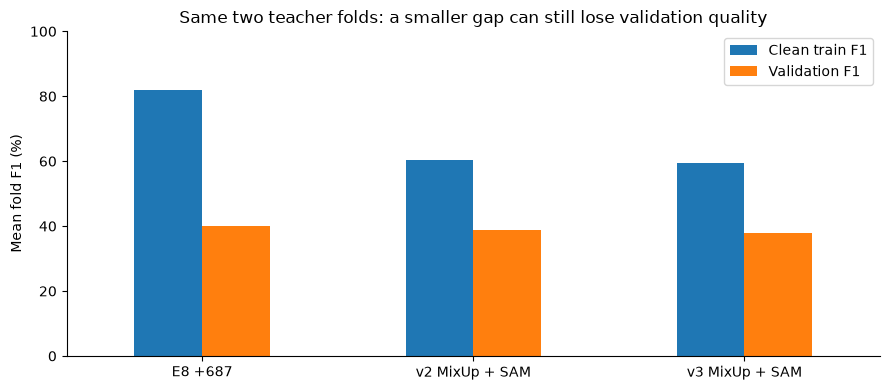

In [124]:
usage_mix = json.loads((REPO_DIR/usage_files['mixup_summary']).read_text())
usage_v3 = json.loads((REPO_DIR/usage_files['v3_summary']).read_text())
assert usage_mix['folds'] == usage_v3['folds'] == [0,4]
assert usage_mix['teacher_rows'] == usage_v3['teacher_rows'] == 13110
screen = pd.DataFrame([
    ['E8 +687', usage_mix['baseline_teacher_f1']],
    ['v2 MixUp + SAM', usage_mix['candidate_teacher_f1']],
    ['v3 MixUp + SAM', usage_v3['candidate_teacher_f1']]],
    columns=['Model','Teacher macro-F1'])
display(screen.set_index('Model').round(6))
fit_rows = pd.DataFrame(usage_mix['mean_teacher_fit']).T.rename(
    index={'mixup_sam':'v2 MixUp + SAM','v2_e8':'E8 +687'})
fit_rows.loc['v3 MixUp + SAM'] = pd.Series(usage_v3['mean_teacher_fit']['v3'])
fit_rows = fit_rows.reindex(screen.Model)
fit_labels = {'teacher_train_f1':'Clean train F1',
              'teacher_validation_f1':'Validation F1','teacher_gap':'Gap'}
display(fit_rows.rename(columns=fit_labels).round(4))
fig, ax = plt.subplots(figsize=(9,4))
fit_rows[['teacher_train_f1','teacher_validation_f1']].rename(
    columns=fit_labels).mul(100).plot.bar(ax=ax, rot=0)
ax.set(xlabel='', ylabel='Mean fold F1 (%)', ylim=(0,100),
       title='Same two teacher folds: a smaller gap can still lose validation quality')
fig.tight_layout()
fig.savefig(FIGURES/'usage_screen_fit.png', dpi=150, bbox_inches='tight')
plt.show()

**Result.** On the same 13,110 teacher images, E8 +687 scores 0.400984, v2 MixUp + SAM scores 0.389790, and v3 scores 0.377773. These are two-fold scores; they must not be ranked against the five-fold table in Section 40.

The v2 gap falls from 0.4173 to 0.2157 mainly because training F1 falls. Validation F1 falls too. V3 leaves the gap almost unchanged at 0.2158. It fixes 208 teacher errors but adds 242. Its paired family interval against v2 is −0.0263 to −0.0012 F1, supporting a decrease for these saved predictions. It does not measure variation across training seeds.

**Failure and decision.** Both trials miss all six teacher Party and all 18 Smart Casual cases on these folds. V3 also loses the one Travel case v2 detected. It gets only 27/76 replacement validation photos right despite fitting many replacement training photos. More suitable product types alone were insufficient under this recipe. Keep both completed trials as evidence; neither is the final model. MixUp and SAM changed together, so their separate effects are unknown.

## 42. Usage: overfitting and robustness remain limits

Overfitting means learning the training examples better than unseen examples. Section 10 shows E1's low final training loss (about 0.0177) and much higher validation loss (0.4641). Its final online training F1 averages 0.6546, versus mean fold validation F1 0.3741. Online training uses weights that change during the epoch; this is not a clean finished-model gap.

The saved clean audits show mean training/validation F1 of 0.7905/0.4155 for E8, 0.7766/0.4059 for E8 +120, and 0.8375/0.4083 for E8 +687. More data did not remove that gap. The two-fold MixUp trials reduced fitting without improving teacher validation. A smaller gap alone is not a reason to choose a model.

E1 loses a mean 6.68 F1 points under 15% darkening and 6.42 under small translation in the saved development checks. E8 improves translation tolerance, but worsens darkening relative to E2. These trade-offs rule out a claim that the accuracy choice is robust to ordinary photo changes.

The later corruption checks include outside images. E8 +687 falls from mean combined F1 0.7555 to 0.2432 under darkening. Two-fold v2 MixUp + SAM improves that response but still falls from 0.7508 to 0.3441. V3 falls from 0.6766 to 0.3138. These different populations cannot establish a matched teacher-only robustness gain. The saved late curves do not show that epoch 30 caused the failures, and no earlier checkpoint is selected from them.

Sources: [original fit audit](../reports/task3/usage_deep_investigation_20260905/fit_summary.csv), [120-image review](../reports/task3/usage_expanded_e8_result_20260906/README.md), [687-image review](../reports/task3/usage_expanded_v2_e8_result_20260906/README.md), [v2 trial](../reports/task3/usage_mixup_sam_result_20260906/README.md), [v3 trial](../reports/task3/usage_replaced_v3_mixup_sam_result_20260907/README.md).

## 43. Usage: freeze E1 as the accuracy choice

The final Usage model is **the original teacher-only E1, using the equal probability average of its five saved fold models**. The owner accepted this choice for overall accuracy after reviewing the completed evaluation. E8 remains the macro-F1 winner among the four tested five-fold artifacts. E1's rare-class failures are an accepted cost, not a solved problem.

This changes the final preference from the development macro-F1 objective. It does not rewrite the earlier gates or claim E1 wins every metric. Decision [0022](../docs/decisions/0022-task3-usage-e1-final-model.md) amends the all-development-refit rule for this evaluated Usage artifact, just as decision 0020 does for Gender.

### 43.1 Verify the exact saved recipe

In [125]:
usage_manifest = json.loads((USAGE_FINAL/'model_manifest.json').read_text())
assert [fold['fold'] for fold in usage_manifest['folds']] == list(range(5))
for fold in usage_manifest['folds']:
    assert hashlib.sha256((REPO_DIR/fold['path']).read_bytes()).hexdigest() == fold['sha256']
    assert registry.loc[fold['run_id'],'checkpoint_sha256'] == fold['sha256']
frozen_usage = {
    'Artifact': 'Five original E1 final-epoch checkpoints; no all-development refit',
    'Network': 'Scratch SmallCNN; 391,209 parameters each; global average pooling',
    'Training': 'Teacher only; 30 epochs; unweighted cross-entropy; no augmentation/dropout',
    'Optimizer': 'AdamW; learning rate 0.001; weight decay 0.0001; batch 128; seed 2753',
    'Schedule': 'Cosine decay to 0.00001; final epoch, no early stopping',
    'Input': 'RGB 3×80×60; aspect-preserving letterbox; each fold’s own normalization',
    'Prediction': 'Equal mean of five softmax vectors, then largest probability',
    'Classes': ', '.join(usage_manifest['class_names'])}
with pd.option_context('display.max_colwidth', None):
    display(pd.Series(frozen_usage, name='Frozen value').to_frame())

,Frozen value
Artifact,Five original E1 final-epoch checkpoints; no all-development refit
Network,"Scratch SmallCNN; 391,209 parameters each; global average pooling"
Training,Teacher only; 30 epochs; unweighted cross-entropy; no augmentation/dropout
Optimizer,AdamW; learning rate 0.001; weight decay 0.0001; batch 128; seed 2753
Schedule,"Cosine decay to 0.00001; final epoch, no early stopping"
Input,RGB 3×80×60; aspect-preserving letterbox; each fold’s own normalization
Prediction,"Equal mean of five softmax vectors, then largest probability"
Classes,"Casual, Ethnic, Formal, Home, NA, Party, Smart Casual, Sports, Travel"


The [manifest](../reports/task3/usage_final_e1_20260907/model_manifest.json) pins each checkpoint, configuration, normalization and file hash. Keep the five models fixed. For development OOF scores, use only the model that held out the image; averaging all five would include models that trained on it.

Five models require five forward passes. The model architecture is small, but no measured application latency is claimed. The saved [Usage test predictions](../reports/task3/usage_teacher_vs_expanded_test_20260906/E1/usage_test_predictions.csv) are the evaluated output; they contain only `id,usage` and do not replace the full submission.

## 44. Usage: read the completed holdout and test results

The holdout has 5,778 reserved teacher-training images. The official test has 5,829 different images. The teacher supplied no test labels; the existing test audit recovered Usage labels by ID from matching high-resolution metadata. Those labels were for scoring only. Inputs stayed the teacher RGB images.

The recipes and predictions were frozen before each scoring pass, but test labels had already been inspected in earlier comparisons. The final E1 acceptance followed holdout/test review. These are completed evaluations, not fresh blind selection evidence or proof of independence for every product family. No new inference or label lookup runs here.

### 44.1 Compare the saved five-fold probability averages

,scored_images,correct,accuracy,macro_f1_nine_classes
model,,,,
E1,5778,5192,0.898581,0.363860
E8,5778,5149,0.891139,0.375935
E8 +120,5778,5154,0.892004,0.394831


,test_rows,correct,accuracy,macro_f1_nine_classes
model,,,,
E1,5829,5123,0.878881,0.271542
E8,5829,4989,0.855893,0.308491
E8 +120,5829,5000,0.857780,0.304231
E8 +687,5829,4991,0.856236,0.304566


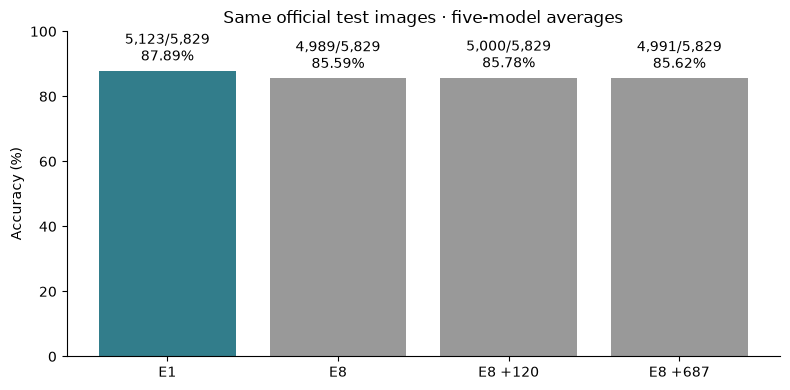

In [126]:
usage_holdout = pd.read_csv(REPO_DIR/usage_files['holdout_summary'], keep_default_na=False)
usage_test = pd.read_csv(REPO_DIR/usage_files['test_summary'], keep_default_na=False)
assert usage_holdout.scored_images.eq(5778).all() and usage_test.test_rows.eq(5829).all()
columns = ['correct','accuracy','macro_f1_nine_classes']
display(usage_holdout.set_index('model')[['scored_images',*columns]].rename(
    index={'Expanded':'E8 +120'}).round(6))
display(usage_test.set_index('model')[['test_rows',*columns]].rename(
    index={'E8_120':'E8 +120','E8_687':'E8 +687'}).round(6))
fig, ax = plt.subplots(figsize=(8,4))
labels = ['E1','E8','E8 +120','E8 +687']
bars = ax.bar(labels, usage_test.accuracy*100,
              color=['#327d8b','#999999','#999999','#999999'])
bar_labels = [f'{correct:,}/5,829\n{accuracy:.2%}'
              for correct,accuracy in zip(usage_test.correct,usage_test.accuracy)]
ax.bar_label(bars, labels=bar_labels, padding=4)
ax.set(ylim=(0,100), ylabel='Accuracy (%)',
       title='Same official test images · five-model averages')
fig.tight_layout()
fig.savefig(FIGURES/'usage_final_test_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

**Holdout.** E1 gets 5,192/5,778 right: 89.86% accuracy and 0.363860 nine-class macro-F1. E8 +120 has the higher holdout macro-F1, 0.394831. No 687-image holdout result is reported.

**Official test.** E1 gets 5,123/5,829 right: 87.89% accuracy and 0.271542 macro-F1. Original E8 gets 4,989 right, E8 +120 gets 5,000, and E8 +687 gets 4,991. E1 leads the 687-image model by 132 correct images, or 2.26 percentage points. Original E8 has the highest test macro-F1, 0.308491. The larger dataset's development accuracy gain did not carry through to a useful test gain.

E1's test advantage over original E8 comes mainly from Casual: 184 more correct Casual predictions, but 50 fewer correct predictions across the other classes. It is a good reason for this accuracy preference, and a poor reason to call the model good at every occasion.

### 44.2 Show E1's class failures and the changed test mix

,support,correct,predicted_count,precision,recall,f1
class_name,,,,,,
Casual,4773,4542,5015,0.9057,0.9516,0.9281
Ethnic,638,524,623,0.8411,0.8213,0.8311
Formal,59,32,122,0.2623,0.5424,0.3536
Home,0,0,0,0.0000,0.0000,0.0000
NA,245,0,3,0.0000,0.0000,0.0000
Party,16,0,0,0.0000,0.0000,0.0000
Smart Casual,12,0,0,0.0000,0.0000,0.0000
Sports,85,25,66,0.3788,0.2941,0.3311
Travel,1,0,0,0.0000,0.0000,0.0000


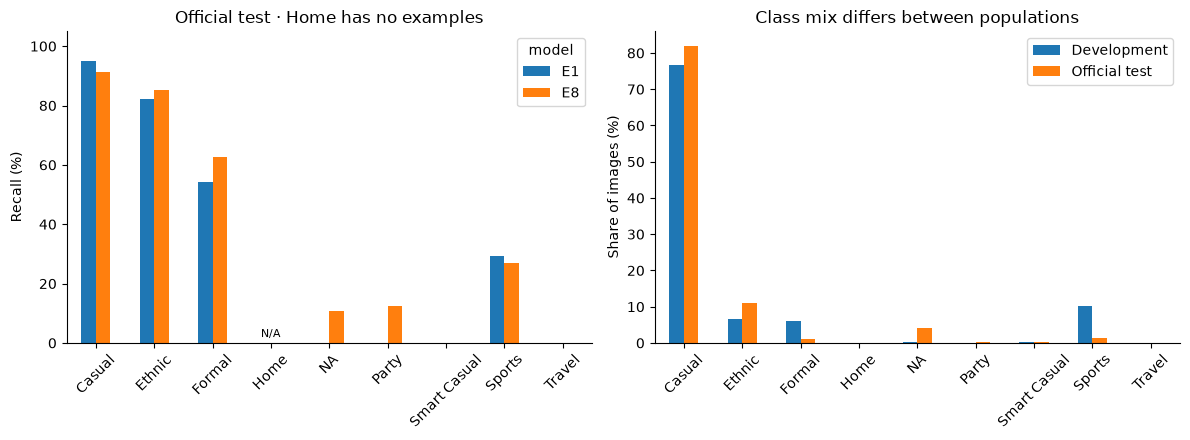

In [127]:
usage_test_classes = pd.read_csv(REPO_DIR/usage_files['test_classes'], keep_default_na=False)
e1_test_classes = usage_test_classes.loc[usage_test_classes.model.eq('E1')].set_index('class_name')
assert e1_test_classes.support.sum() == 5829 and e1_test_classes.correct.sum() == 5123
display(e1_test_classes[['support','correct','predicted_count','precision','recall','f1']].round(4))
class_names = usage_manifest['class_names']
fig, axes = plt.subplots(1,2,figsize=(12,4.5))
recalls = usage_test_classes.loc[usage_test_classes.model.isin(['E1','E8'])].pivot(
    index='class_name', columns='model', values='recall').reindex(class_names)
recalls.loc['Home'] = np.nan
recalls.mul(100).plot.bar(ax=axes[0], rot=45)
axes[0].set(xlabel='', ylabel='Recall (%)', ylim=(0,105),
            title='Official test · Home has no examples')
axes[0].annotate('N/A', (3,2), ha='center', fontsize=8)
mix = pd.DataFrame({'Development': usage_development.usage.value_counts(normalize=True),
                    'Official test': e1_test_classes.support/5829}).reindex(class_names)
mix.mul(100).plot.bar(ax=axes[1], rot=45)
axes[1].set(xlabel='', ylabel='Share of images (%)',
            title='Class mix differs between populations')
fig.tight_layout()
fig.savefig(FIGURES/'usage_final_class_limits.png', dpi=150, bbox_inches='tight')
plt.show()

**Limits.** E1 misses every test NA (245), Party (16), Smart Casual (12) and Travel (1) case. Home has no test examples, so it cannot be assessed here. The fixed nine-class F1 assigns absent Home zero; the separate average over eight present classes is 0.305485. It must not replace the nine-class comparison.

Casual makes up 81.88% of the test, compared with 76.75% of valid development rows. Formal and Sports are much less common in the test, while NA is more common. E1 detects only 25/85 Sports cases. These shifts help explain why a high accuracy can coexist with low macro-F1; they do not prove the cause of each error.

For an application, treat Usage as a suggested catalogue tag that may need review, especially for rare occasions and changed photo styles. These results do not support reliable automatic tagging of every class. Future improvements need new independent evaluation data; repeatedly reading these results cannot make them fresh again.

## 45. Final judgement and handoff

**Gender:** keep the fixed SAM25 five-fold ensemble. It trades some screen F1 for a smaller clean fit gap and passed safeguards. Decision [0020](../docs/decisions/0020-task3-gender-sam25-final-model.md) records the saved artifact and acceptance timing.

**Usage:** keep the original E1 five-fold probability average. It gives the highest accuracy among the four tested artifacts, while E8 gives better equal-class performance. Decision [0022](../docs/decisions/0022-task3-usage-e1-final-model.md) records that explicit trade-off. Neither result proves that every audience or occasion can be read from one image.

Run this notebook with the project `.venv` to rebuild the report from saved evidence. The [Gender training notebook](task3_training/gender_sam25_five_fold.ipynb) and [E1 training notebook](task3_training/smallcnn_baseline_training.ipynb) retain their workflows; they are not needed to read this report. Use the frozen manifests for application integration. The required final columns remain `id,gender,articleType,season,usage`; separate target files are not the complete submission.

The main evidence uses one seed and repeatedly consulted development folds. Family resampling measures uncertainty within those saved groups, not all uncertainty from trying many models. No human performance ceiling has been measured. Architecture, source style and label ambiguity remain plausible explanations, not proven causes.

The [earlier investigation](../reports/task3/main_report_20260906/earlier_investigation.ipynb) keeps the historical record and original gates. This notebook is the full analysis record; the submission report still needs to fit the assignment's five-page text limit.